# Imports

In [396]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Varying alpha

## load data

In [389]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

baselines = pd.read_csv(f'{save_root}/baselines_params.csv')
finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')

base = baselines.copy()
base = base[
    ((base.data_id == 'ETTh1') & (base.model == 'Fredformer')) |
    ((base.data_id == 'ETTh2') & (base.model == 'Fredformer')) |
    ((base.data_id == 'ETTm1') & (base.model == 'Fredformer')) |
    ((base.data_id == 'ETTm2') & (base.model == 'Fredformer')) |
    ((base.data_id == 'ECL') & (base.model == 'iTransformer')) |
    ((base.data_id == 'Weather') & (base.model == 'FreTS'))
]
base['alpha'] = 0.0

hpa = finetunes_all.copy()
hpa = hpa[
    (hpa.pca_dim == 'T') &
    (hpa.use_weights == 0) &
    (hpa.auxi_loss == 'MAE') &
    (hpa.reinit == 1) &
    (hpa.seq_len == 96)
]
hpa = hpa[
    ((hpa.data_id == 'ETTh1_PCA') & (hpa.model == 'Fredformer')) |
    ((hpa.data_id == 'ETTh2_PCA') & (hpa.model == 'Fredformer')) |
    ((hpa.data_id == 'ETTm1_PCA') & (hpa.model == 'Fredformer')) |
    ((hpa.data_id == 'ETTm2_PCA') & (hpa.model == 'Fredformer')) |
    ((hpa.data_id == 'ECL_PCA') & (hpa.model == 'iTransformer')) |
    ((hpa.data_id == 'Weather_PCA') & (hpa.model == 'FreTS'))
]
hpa.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)
hpa.drop(columns=['rec_lambda'], inplace=True)


## preprocess main

In [19]:
df2 = hpa.copy()

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'alpha'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

df3 = base.copy()

columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae']
df3 = df3[columns]
df2 = df2[columns]

df_alpha = pd.concat([df3, df2], axis=0)

dst_order = ['ECL', 'Weather']
df_alpha['data_id'] = pd.Categorical(df_alpha['data_id'], categories=dst_order, ordered=True)

df_alpha['alpha'] = df_alpha['alpha'].astype(float)

df_alpha.sort_values(by=['model', 'data_id', 'alpha', 'pred_len'], inplace=True)
df_alpha.head(10)

,model,data_id,pred_len,alpha,mse,mae
212,FreTS,Weather,96,0.0,0.173683,0.227737
213,FreTS,Weather,192,0.0,0.212846,0.266092
214,FreTS,Weather,336,0.0,0.270492,0.315915
215,FreTS,Weather,720,0.0,0.337221,0.362299
16877,FreTS,Weather,96,0.1,0.171112,0.223877
18499,FreTS,Weather,192,0.1,0.211888,0.262123
19159,FreTS,Weather,336,0.1,0.262977,0.303780
20823,FreTS,Weather,720,0.1,0.334001,0.355863
17686,FreTS,Weather,96,0.2,0.170741,0.222095
18447,FreTS,Weather,192,0.2,0.211334,0.260119


## plot main

In [ ]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'center right'  # 这里可以根据图的实际情况调节。
    labelsize = 12

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mse', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize)
    if ytick1:
        plt.yticks(ytick1)
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MSE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mae', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MAE')
    plt.tick_params(labelsize=labelsize)
    if ytick2:
        plt.yticks(ytick2)
    if ylim2:
        plt.ylim(ylim2)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MAE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


dfp = df_alpha.copy()
dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study'
os.makedirs(save_dir, exist_ok=True)


dfp_ = dfp[(dfp.model == 'iTransformer')]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'iTrans_ECL_alpha', ypad1=0.01, ypad2=0.01)

dfp_ = dfp[(dfp.model == 'FreTS')]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'FreTS_Weather_alpha', ypad1=0.02, ypad2=0.02, ylim1=[0.207, 0.285], ylim2=[0.257, 0.325])

## preprocess all

In [393]:
df2 = hpa.copy()

df2 = df2[
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.7) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.9) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.6) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 0.5) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
]
# 按data去给一个alpha


min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'alpha'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

df3 = base.copy()
df3['rank_ratio'] = 1.0

columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'rank_ratio', 'learning_rate']
df3 = df3[columns]
df2 = df2[columns]

df_alpha = pd.concat([df3, df2], axis=0)

dst_order = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']
df_alpha['data_id'] = pd.Categorical(df_alpha['data_id'], categories=dst_order, ordered=True)

df_alpha['alpha'] = df_alpha['alpha'].astype(float)
df_alpha.dropna(inplace=True, thresh=6)

df_alpha.sort_values(by=['data_id', 'alpha', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae']
df_alpha[columns].to_csv(f'{save_root}/hyper_study_alpha.csv', index=False)

df_alpha.head(10)

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate
228,Fredformer,ETTm1,96,0.0,0.326369,0.360869,1.0,0.0001
229,Fredformer,ETTm1,192,0.0,0.365194,0.382132,1.0,0.0001
230,Fredformer,ETTm1,336,0.0,0.395987,0.404369,1.0,0.0001
231,Fredformer,ETTm1,720,0.0,0.459217,0.444342,1.0,0.0001
23197,Fredformer,ETTm1,96,0.1,0.322022,0.358826,1.0,0.0005
23356,Fredformer,ETTm1,192,0.1,0.371666,0.386820,1.0,0.0005
23555,Fredformer,ETTm1,336,0.1,0.396719,0.405975,0.7,0.0005
23689,Fredformer,ETTm1,720,0.1,0.460914,0.444473,0.8,0.0005
23173,Fredformer,ETTm1,96,0.2,0.321644,0.358380,1.0,0.0005
23388,Fredformer,ETTm1,192,0.2,0.371401,0.386566,1.0,0.0005


In [221]:
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 96) & (hpa.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 192) & (hpa.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 336) & (hpa.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 720) & (hpa.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)

,model,seq_len,pred_len,data_id,learning_rate,alpha,pca_dim,reinit,use_weights,rank_ratio,auxi_loss,batch_size,auxi_type,auxi_mode,lradj,patience,train_epochs,mse,mae,exp_dir
20686,FreTS,96,720,Weather_PCA,0.005,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.370297,0.393778,/data/home/Licheng/workspace/TSF-PCA/results_P...
21329,FreTS,96,720,Weather_PCA,0.004,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.371447,0.397803,/data/home/Licheng/workspace/TSF-PCA/results_P...
21149,FreTS,96,720,Weather_PCA,0.003,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,10,10,0.377764,0.405635,/data/home/Licheng/workspace/TSF-PCA/results_P...
20941,FreTS,96,720,Weather_PCA,0.003,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.377764,0.405635,/data/home/Licheng/workspace/TSF-PCA/results_P...
21164,FreTS,96,720,Weather_PCA,0.002,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.398846,0.427975,/data/home/Licheng/workspace/TSF-PCA/results_P...


## plot all

5 0.002
5 0.005
5 0.003
5 0.005
5 0.007
5 0.002
5 0.002
5 0.003
5 0.003
5 0.006
5 0.005
5 0.005
5 0.005
5 0.012
5 0.011
5 0.004
5 0.009
5 0.011
5 0.008
5 0.009
5 0.002


/tmp/ipykernel_3448545/2206538394.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5


5 0.004
5 0.003
5 0.008
5 0.005
5 0.022
5 0.018
5 0.004
5 0.006
5 0.018


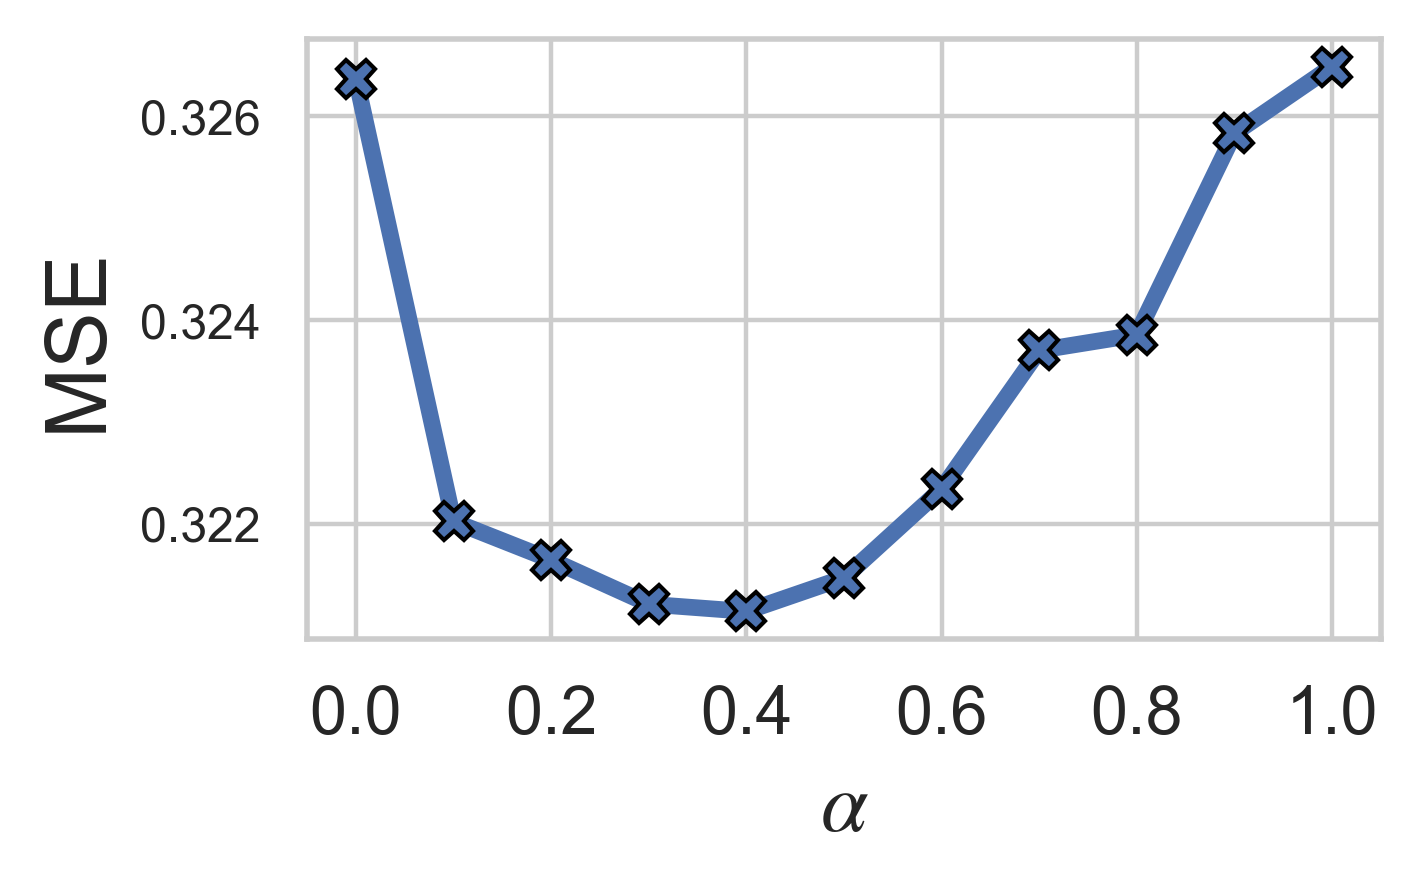

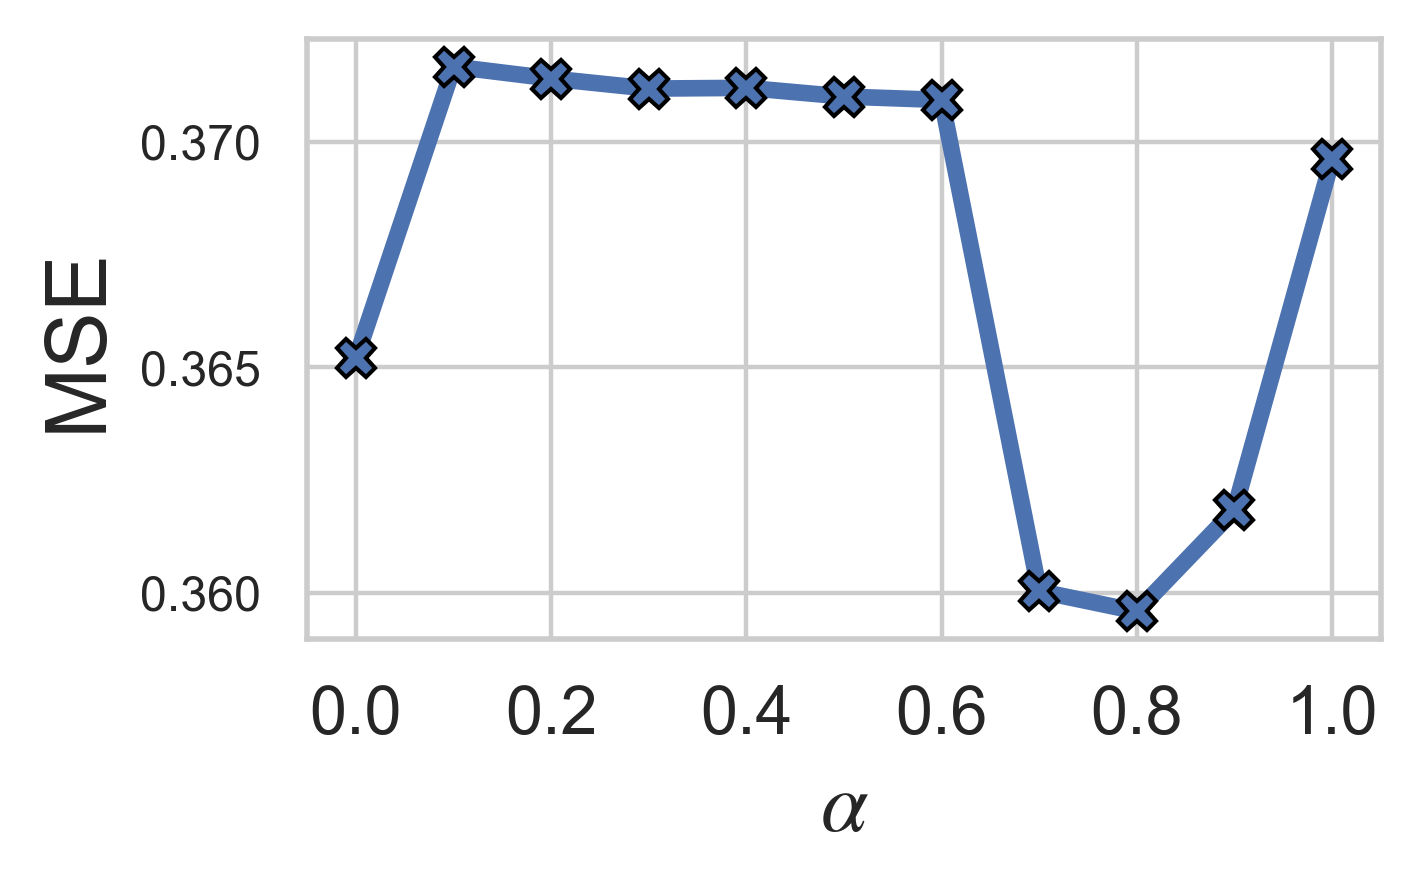

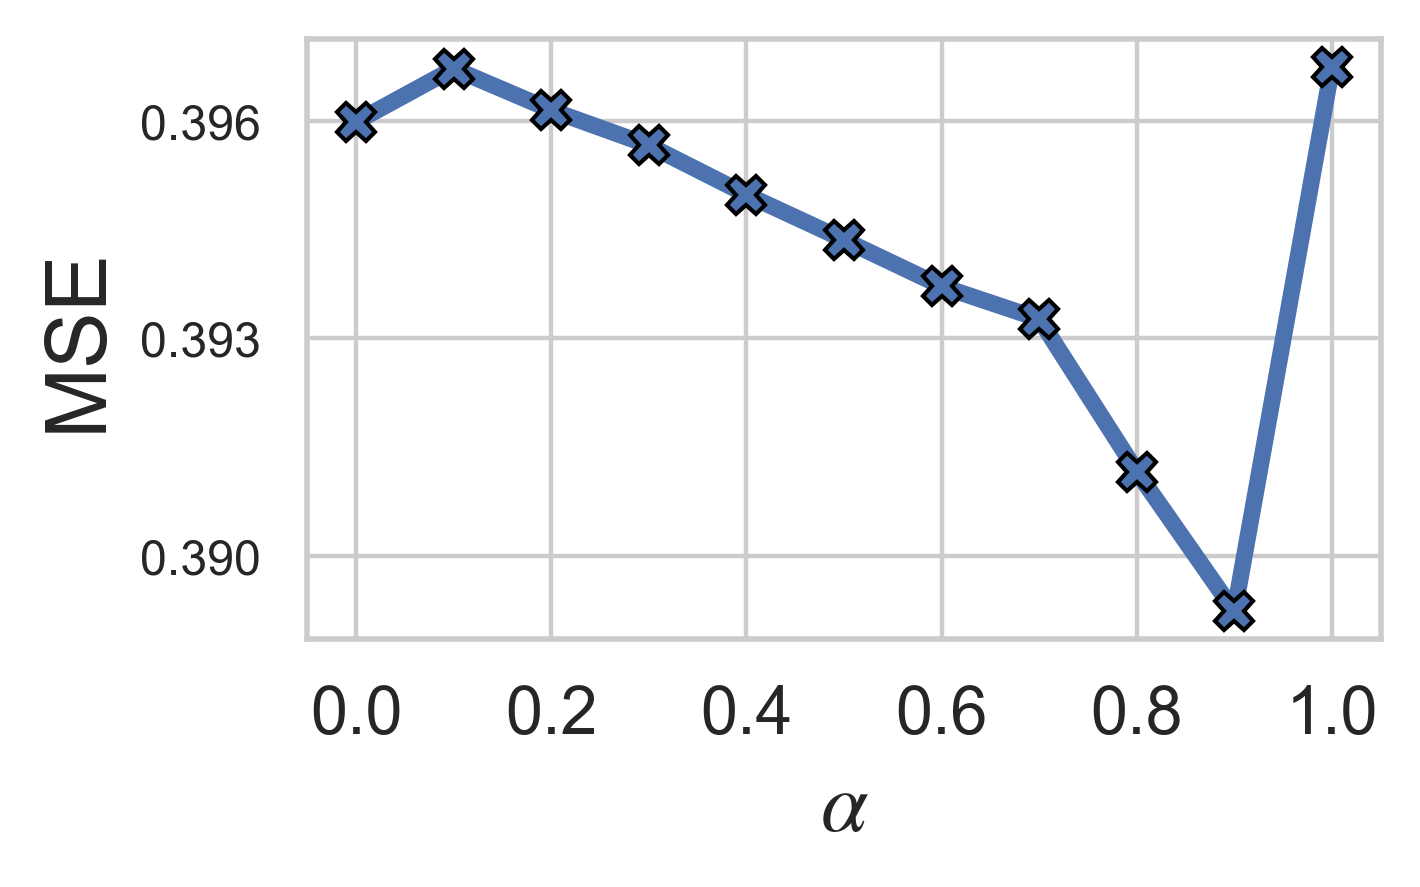

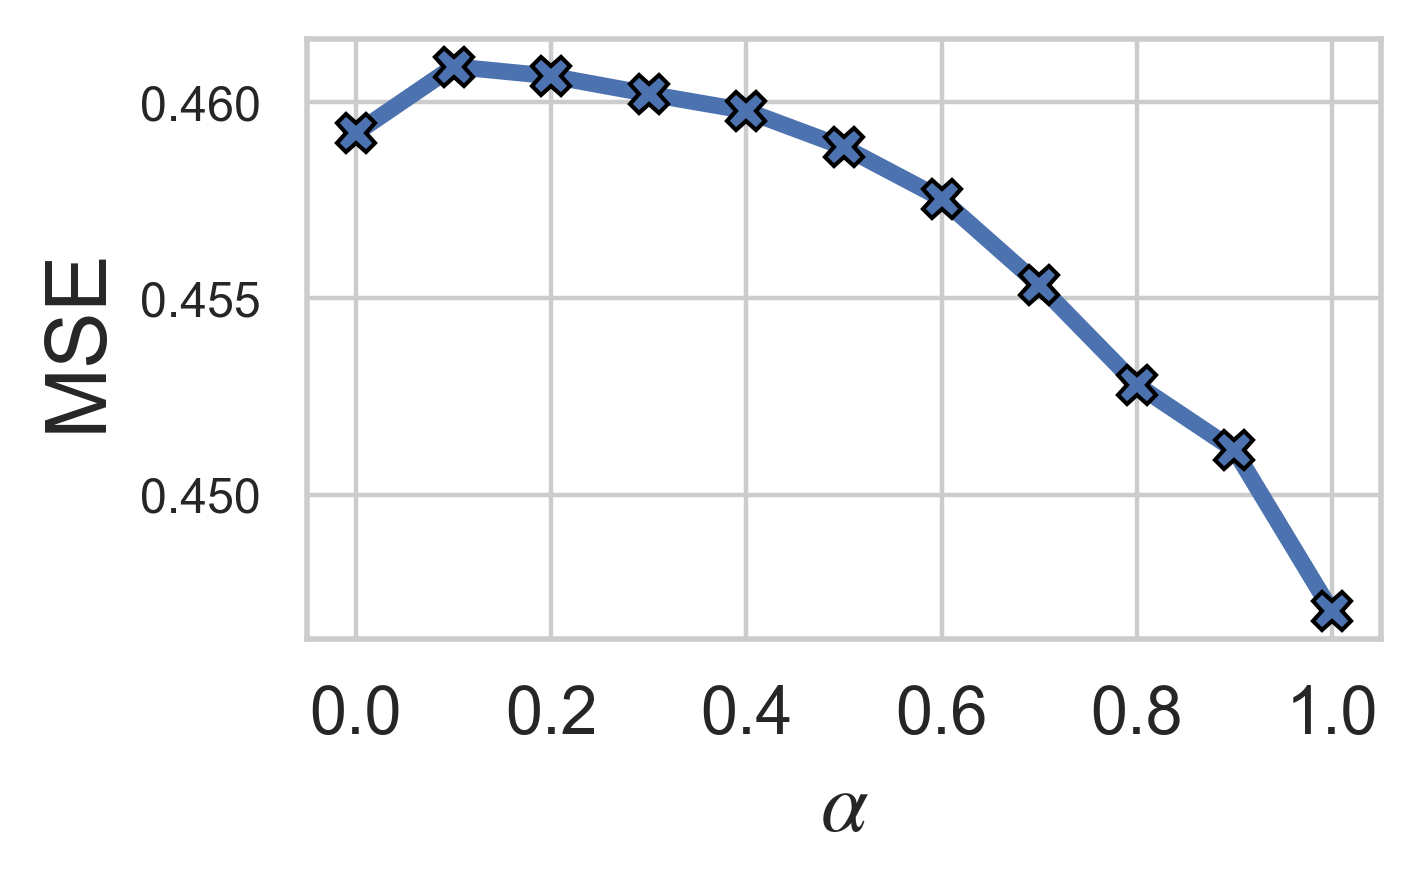

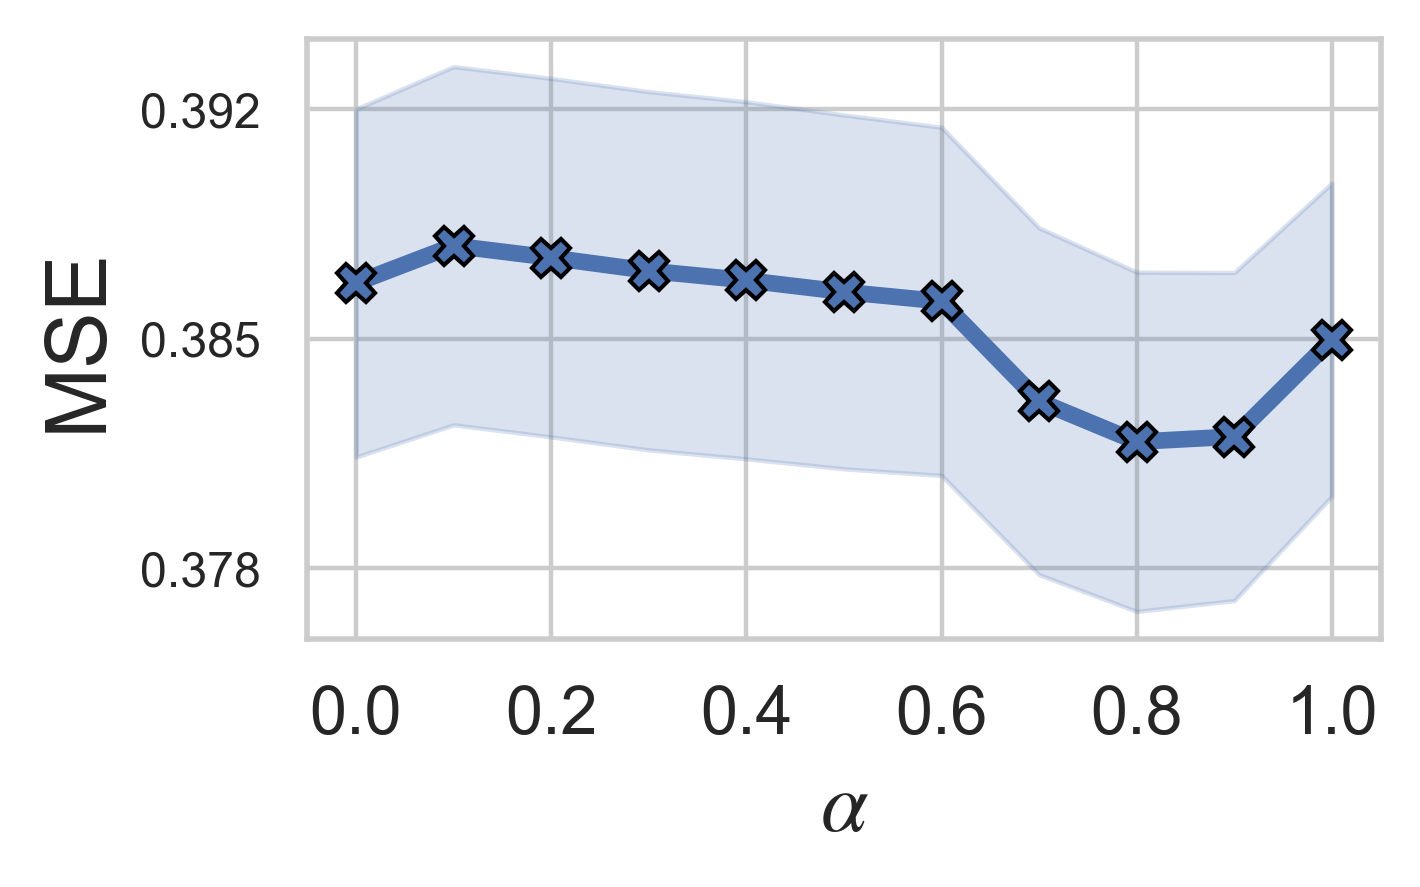

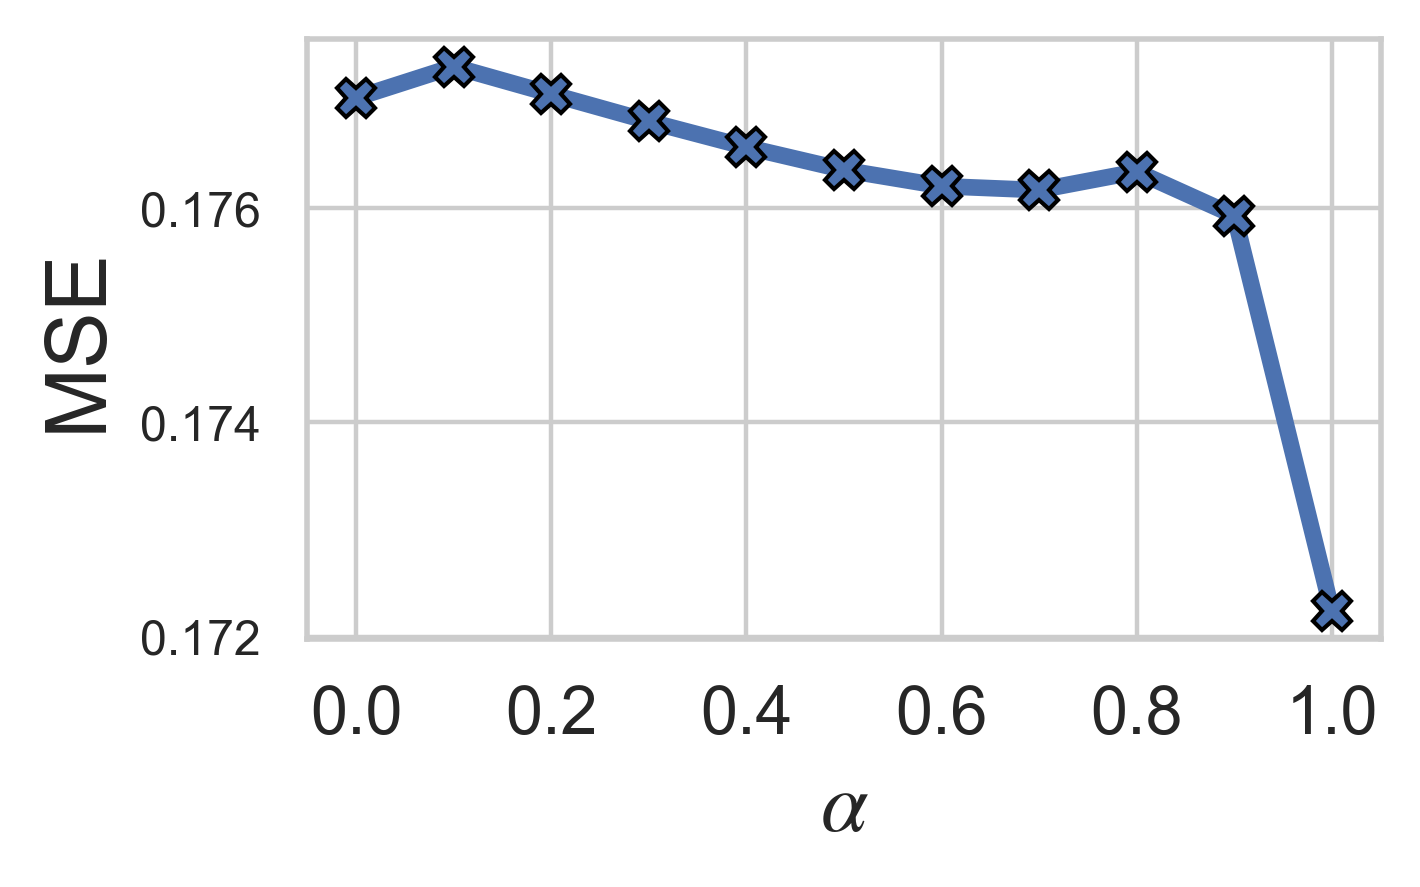

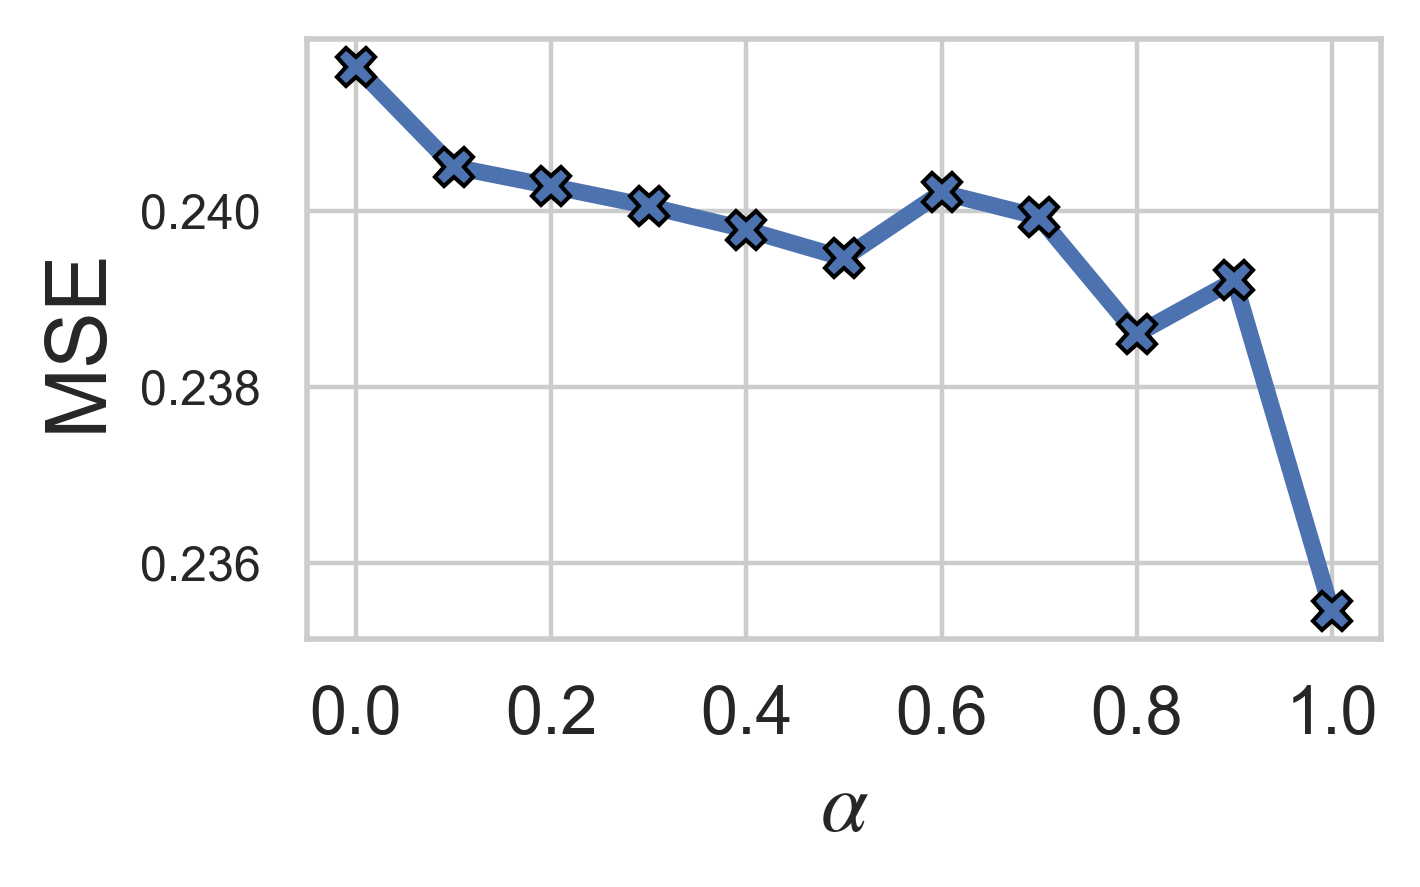

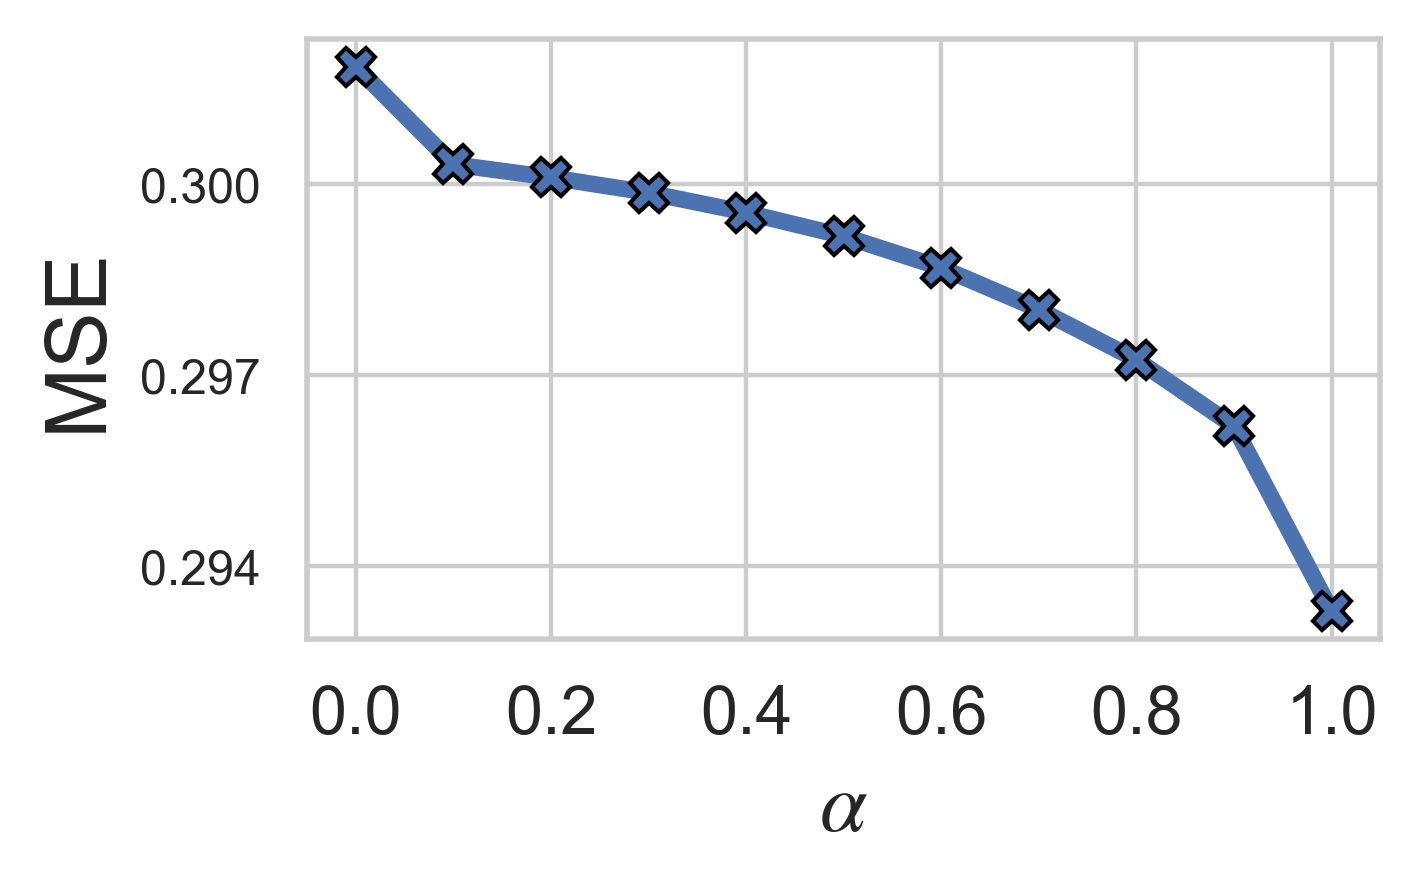

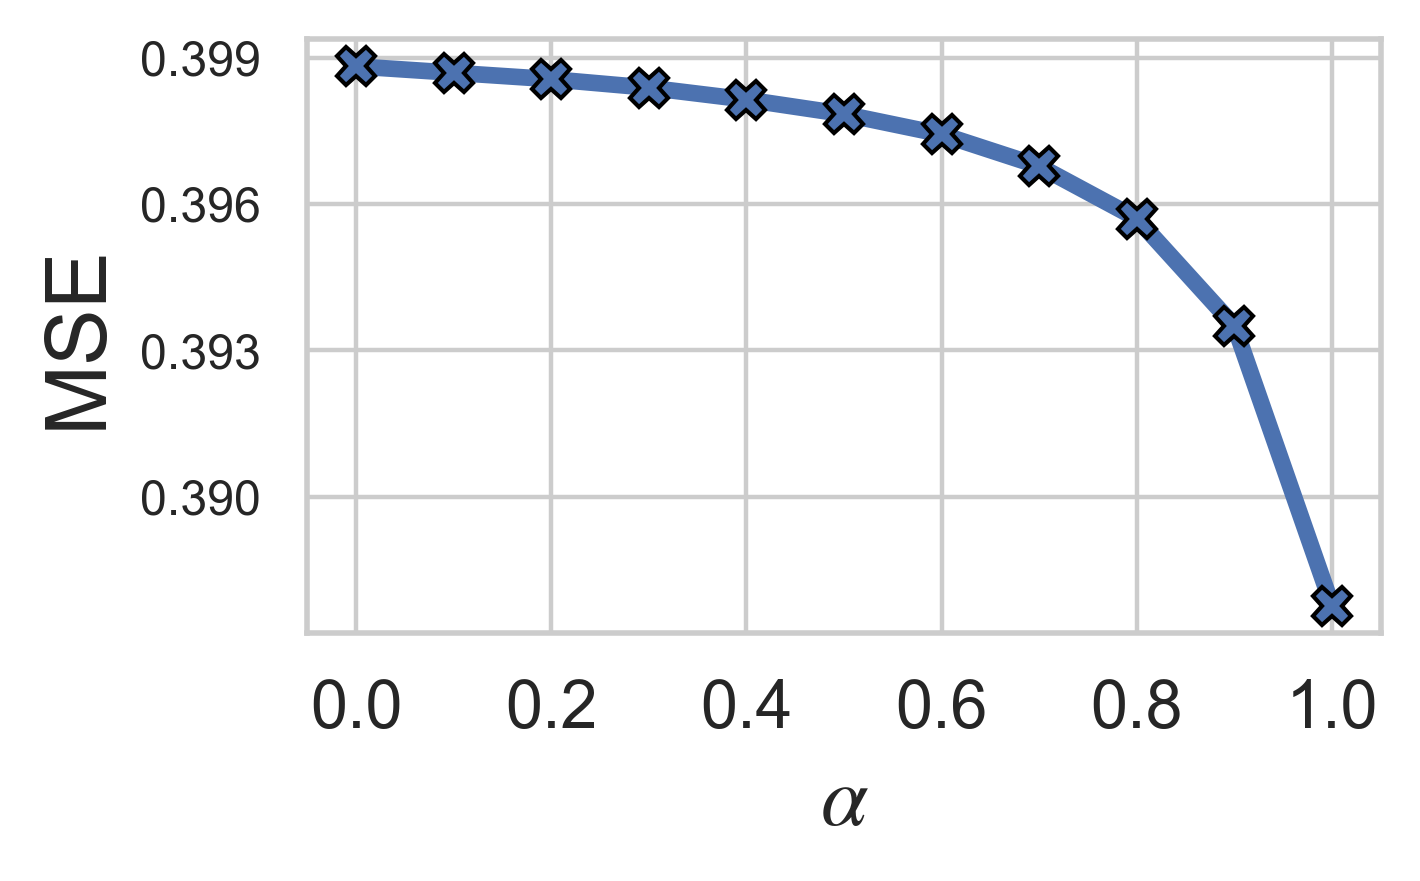

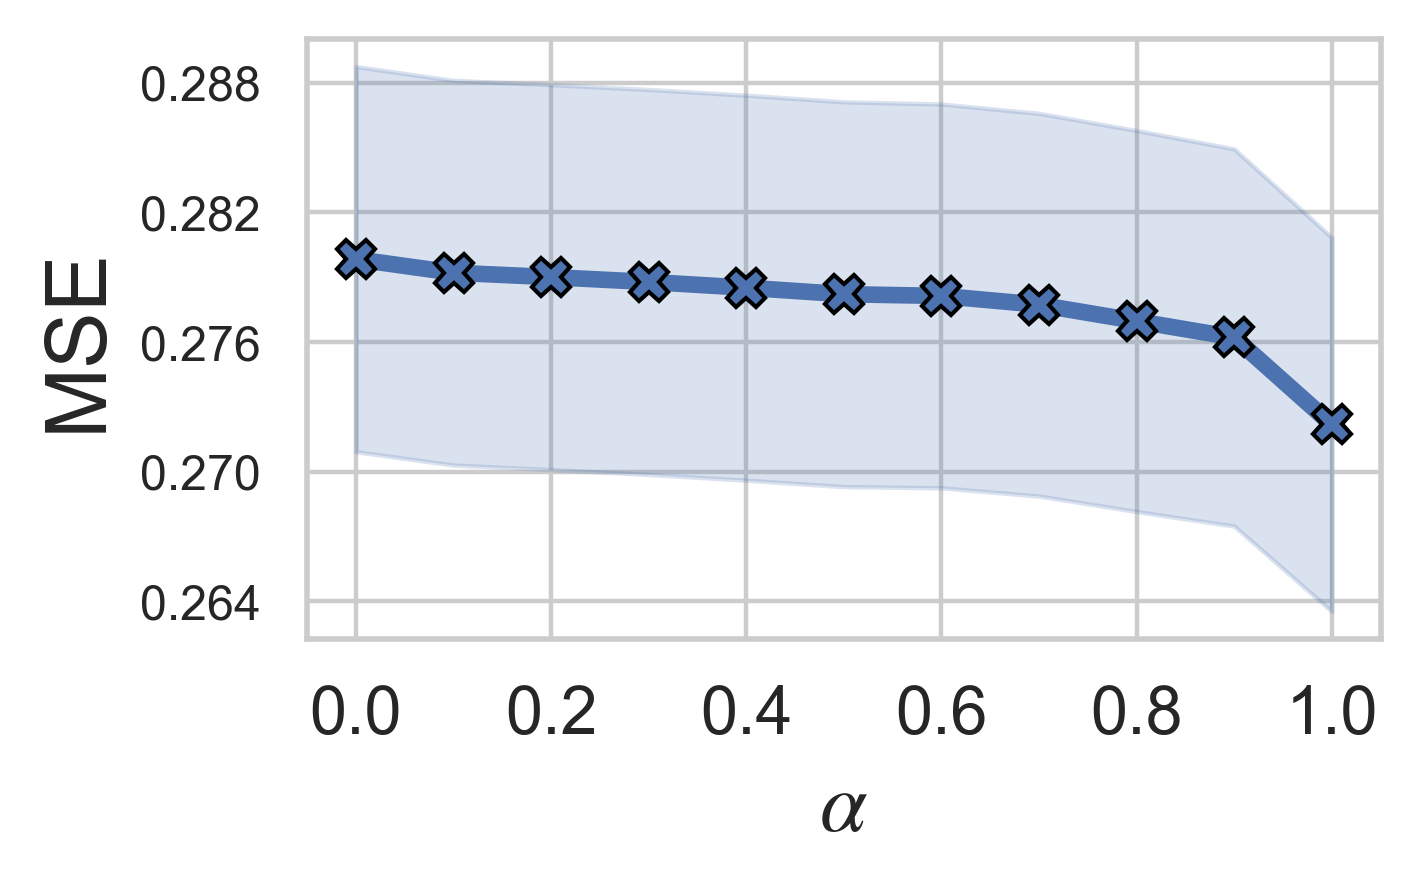

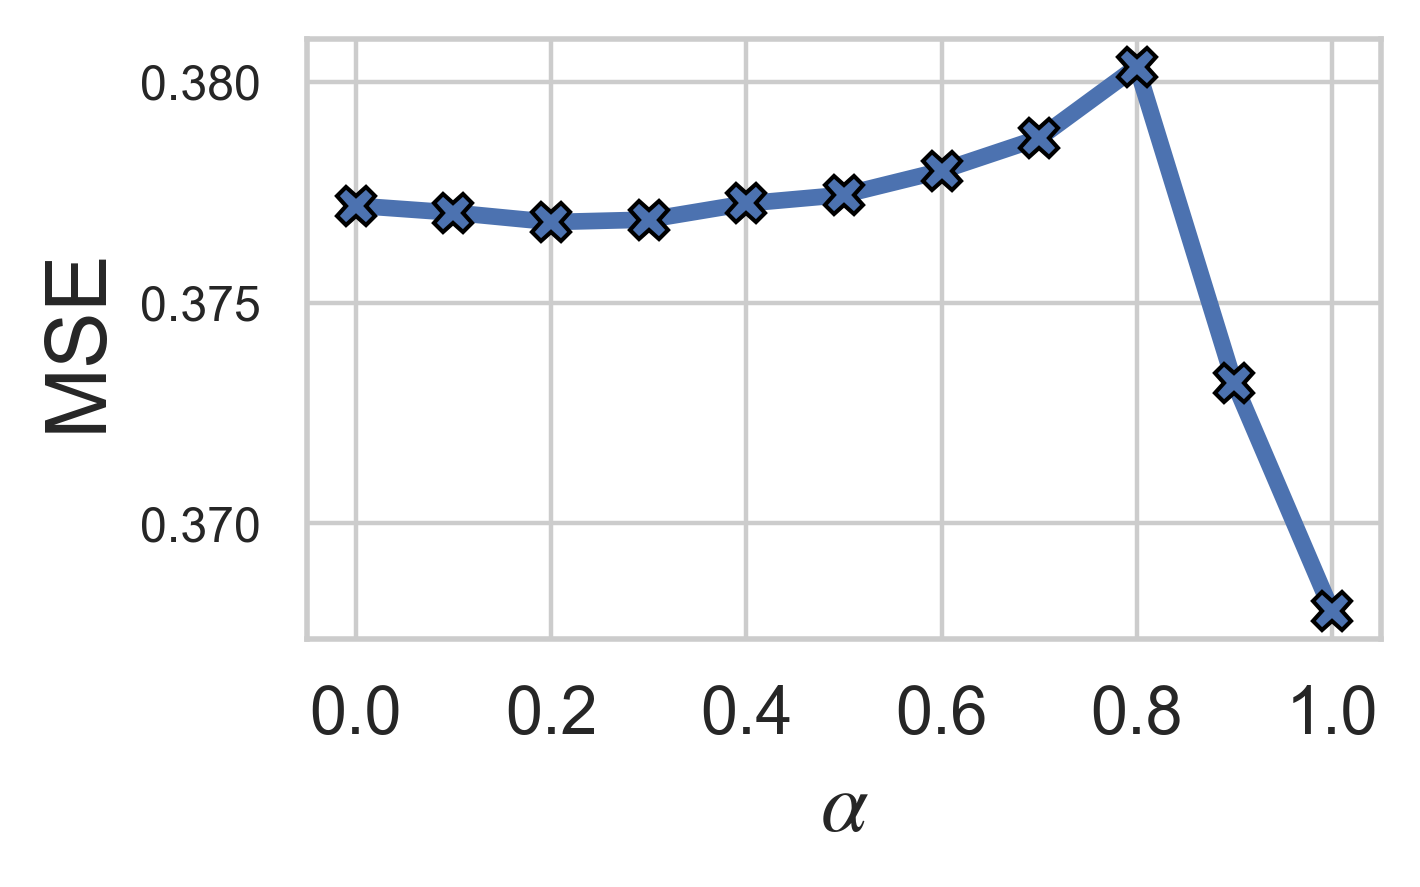

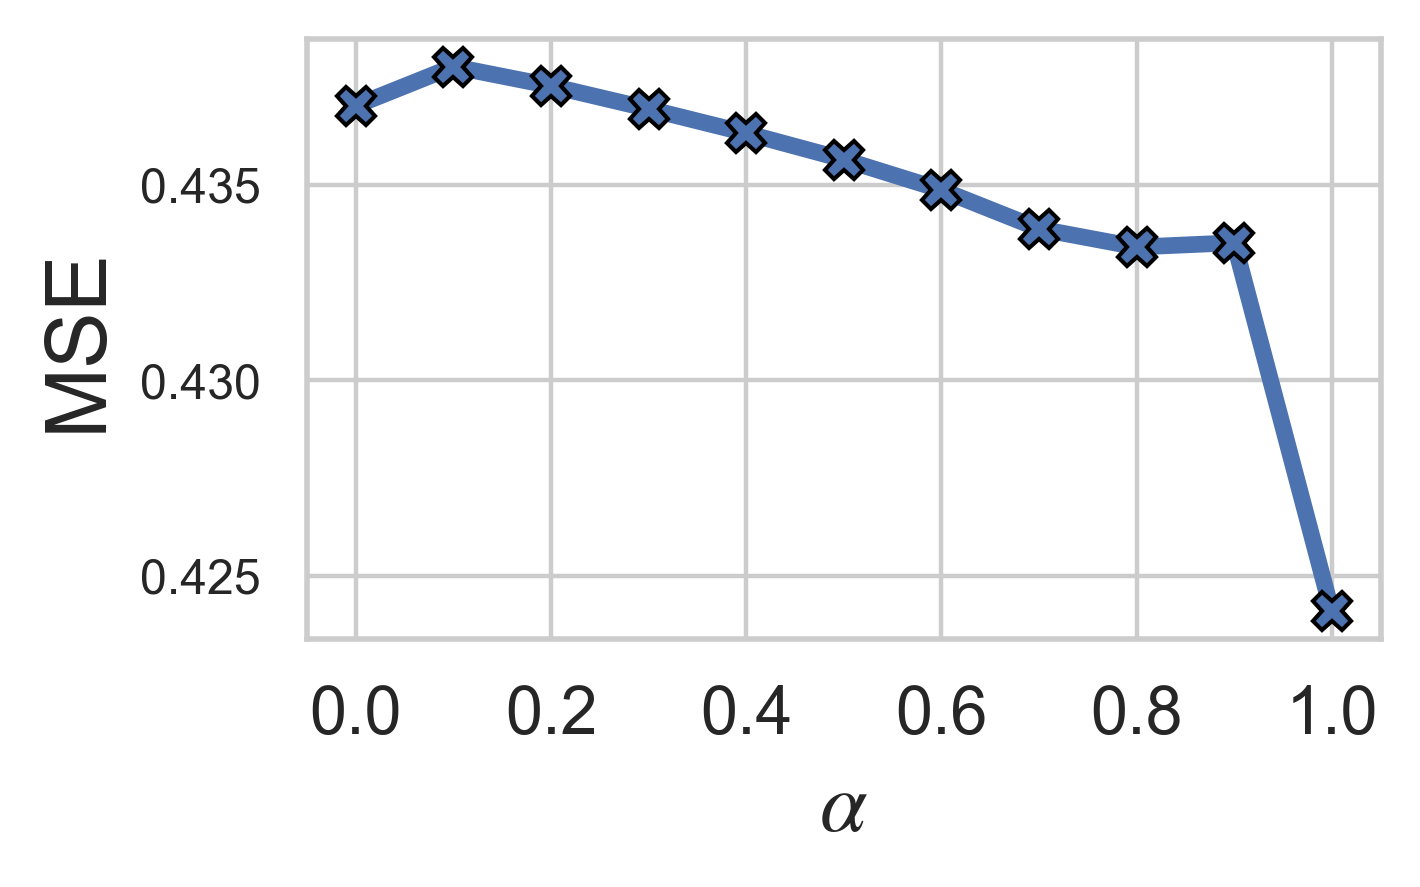

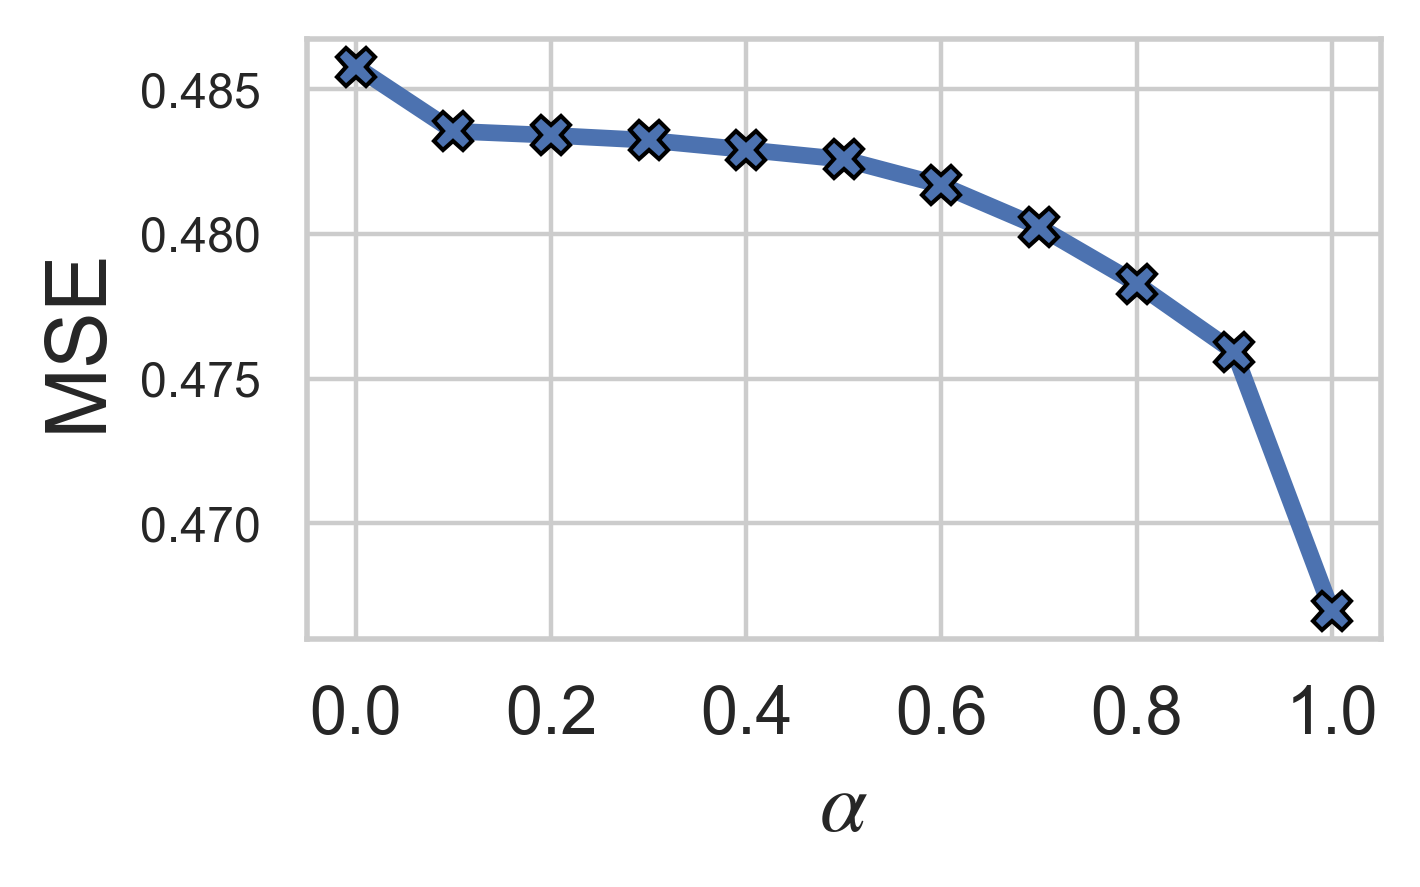

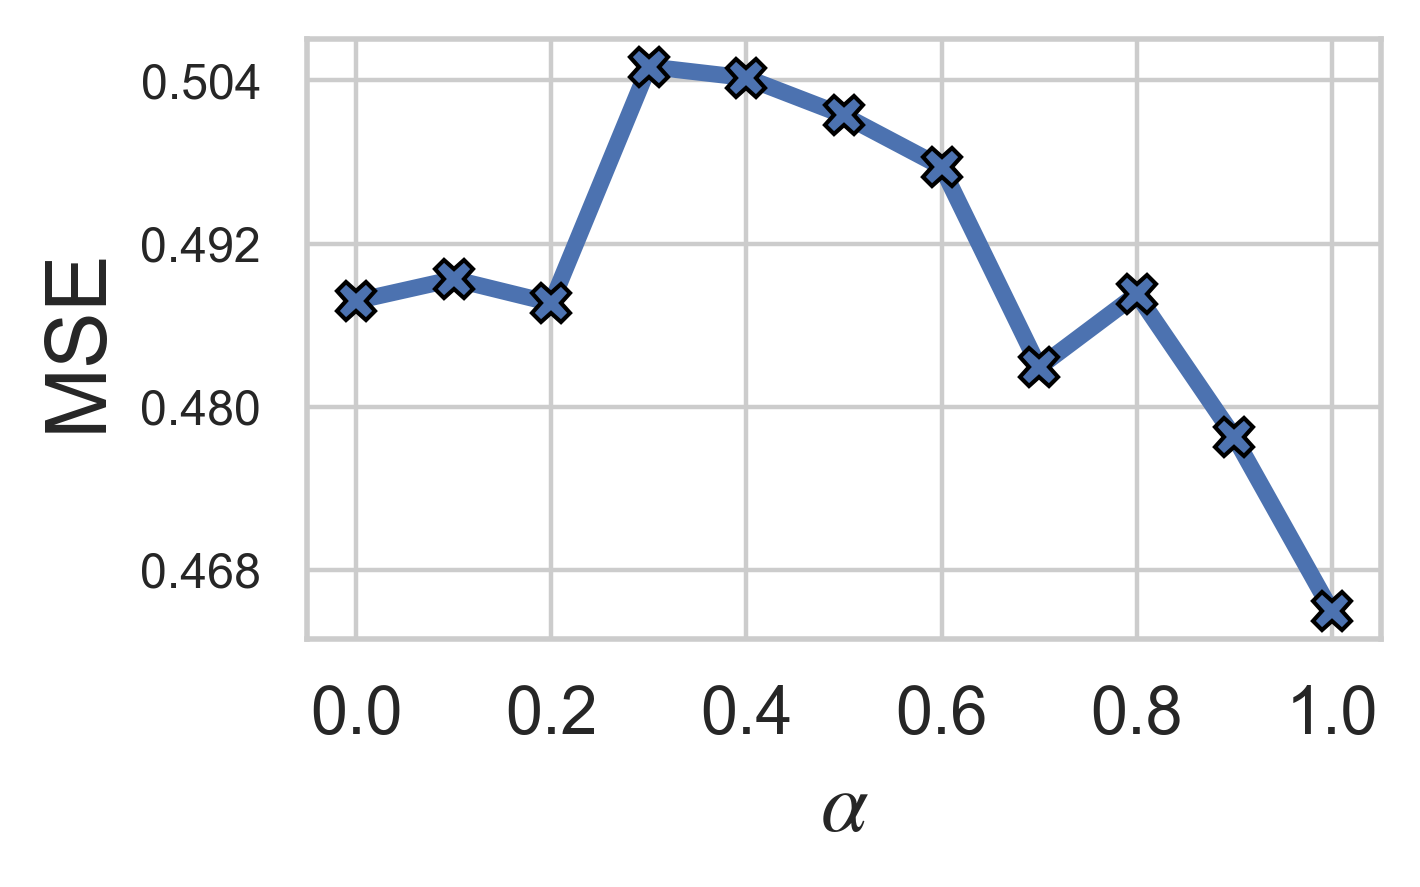

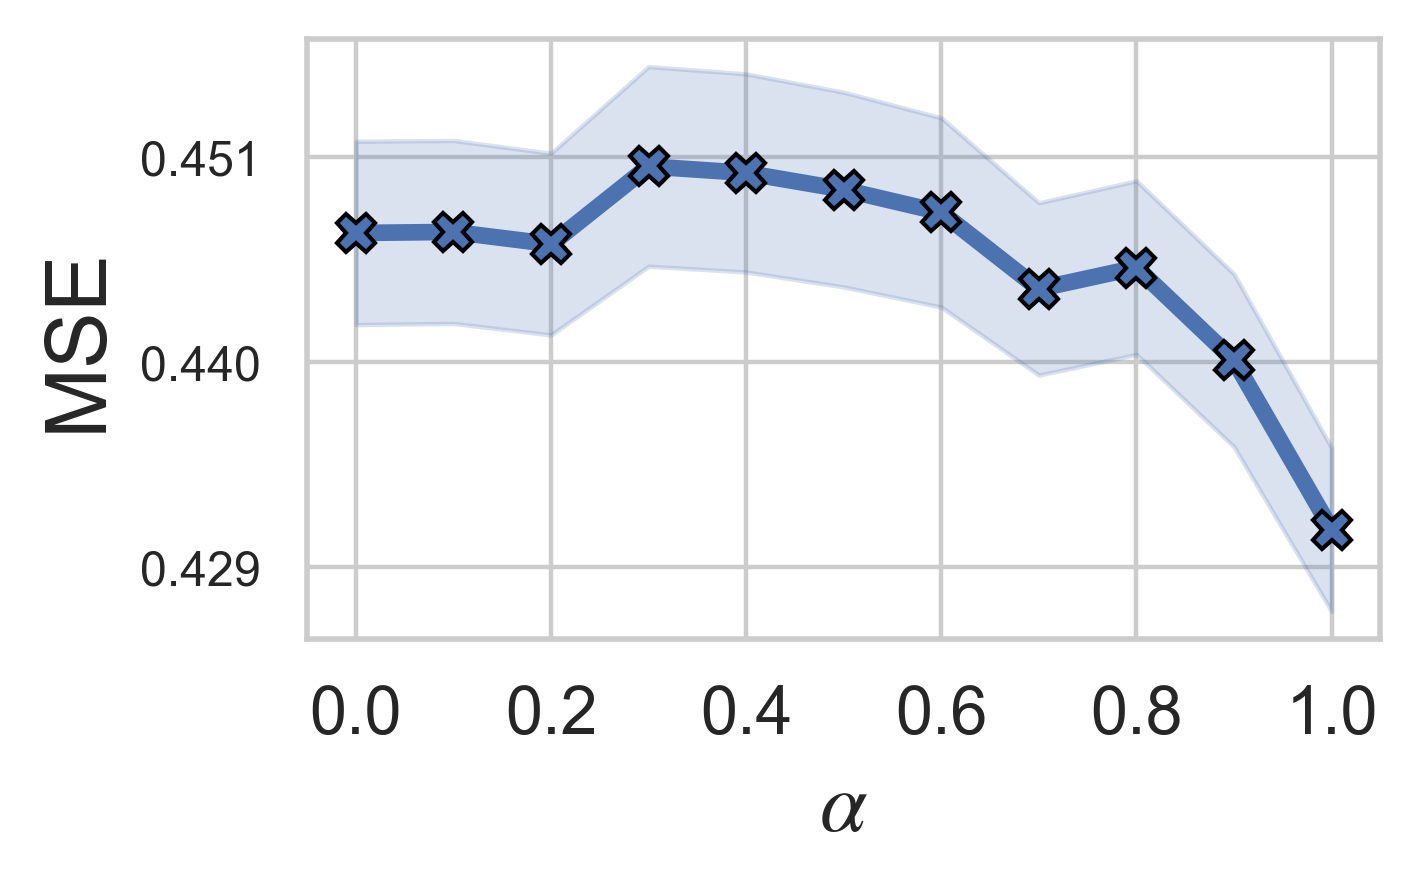

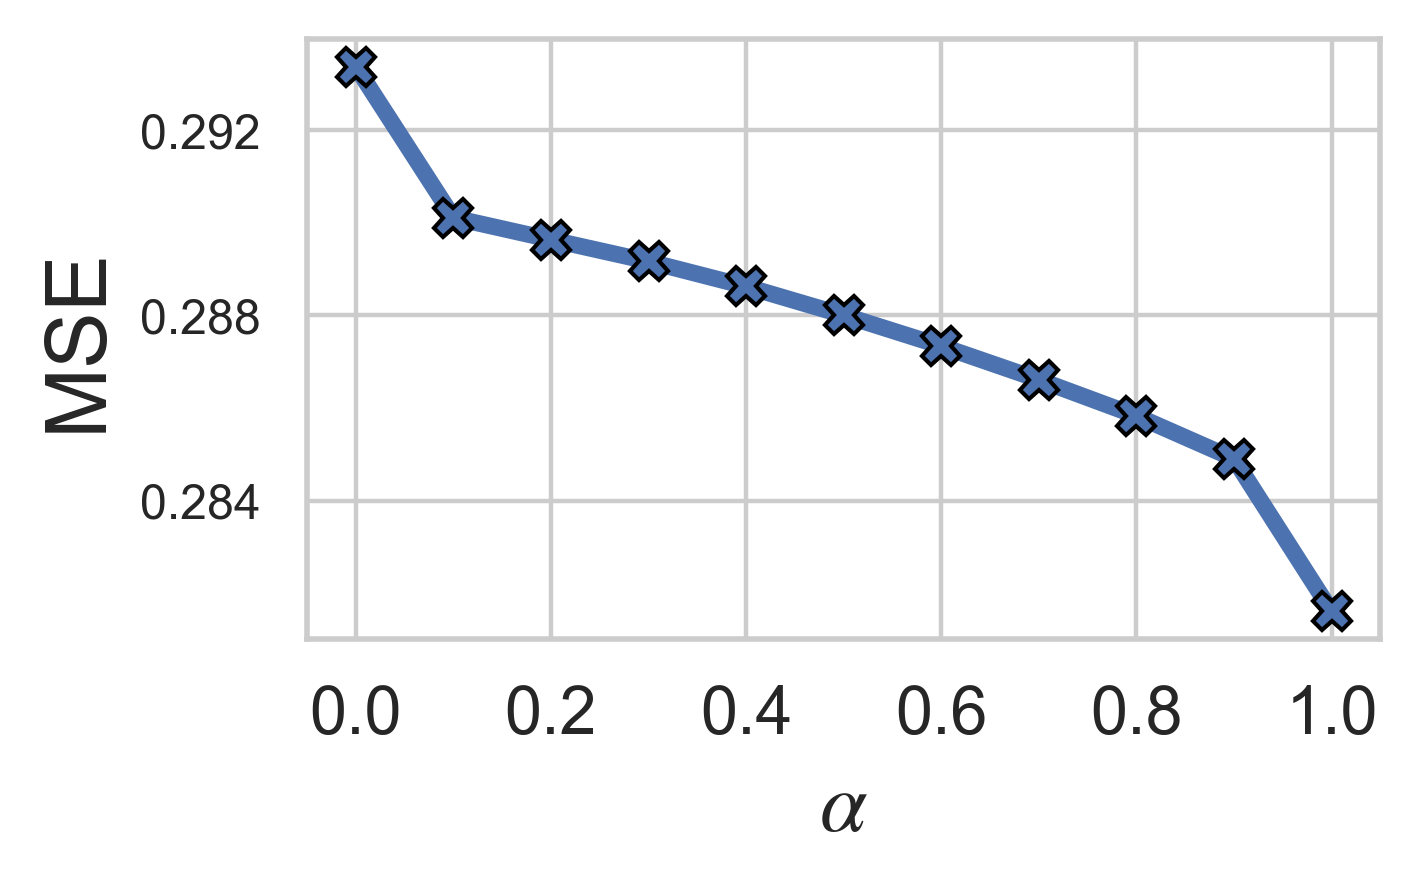

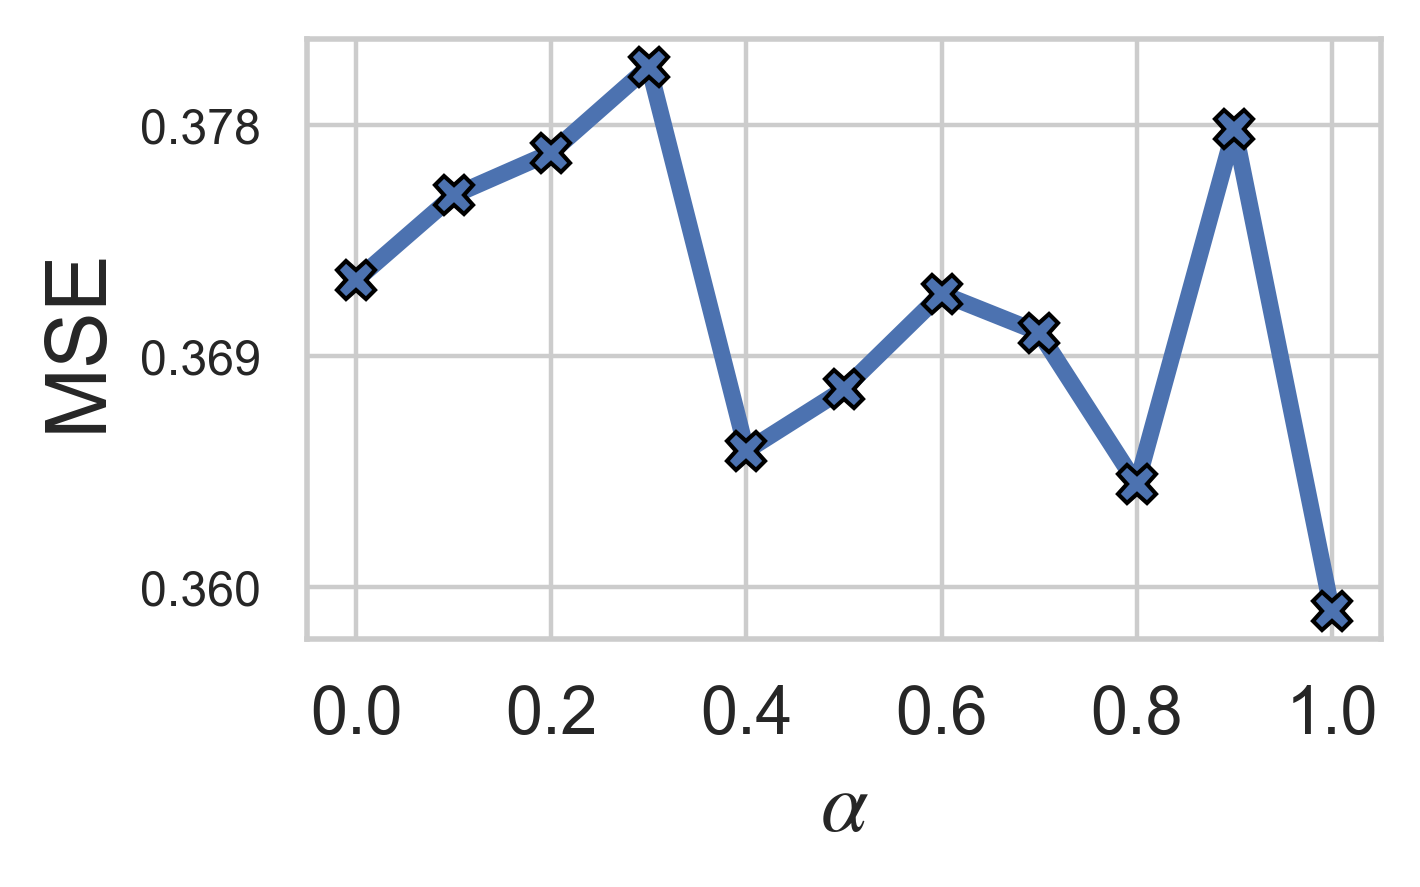

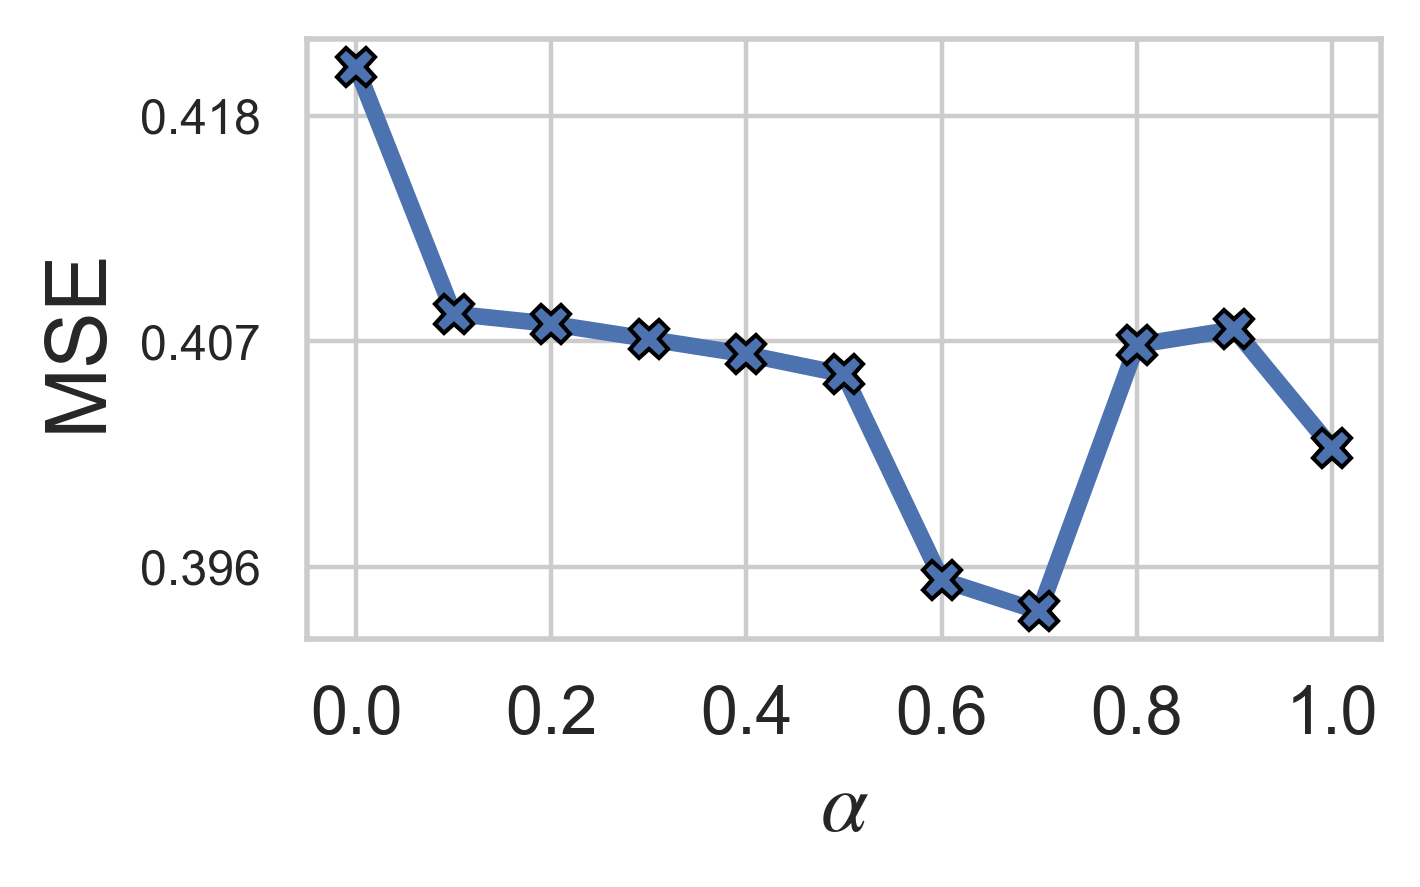

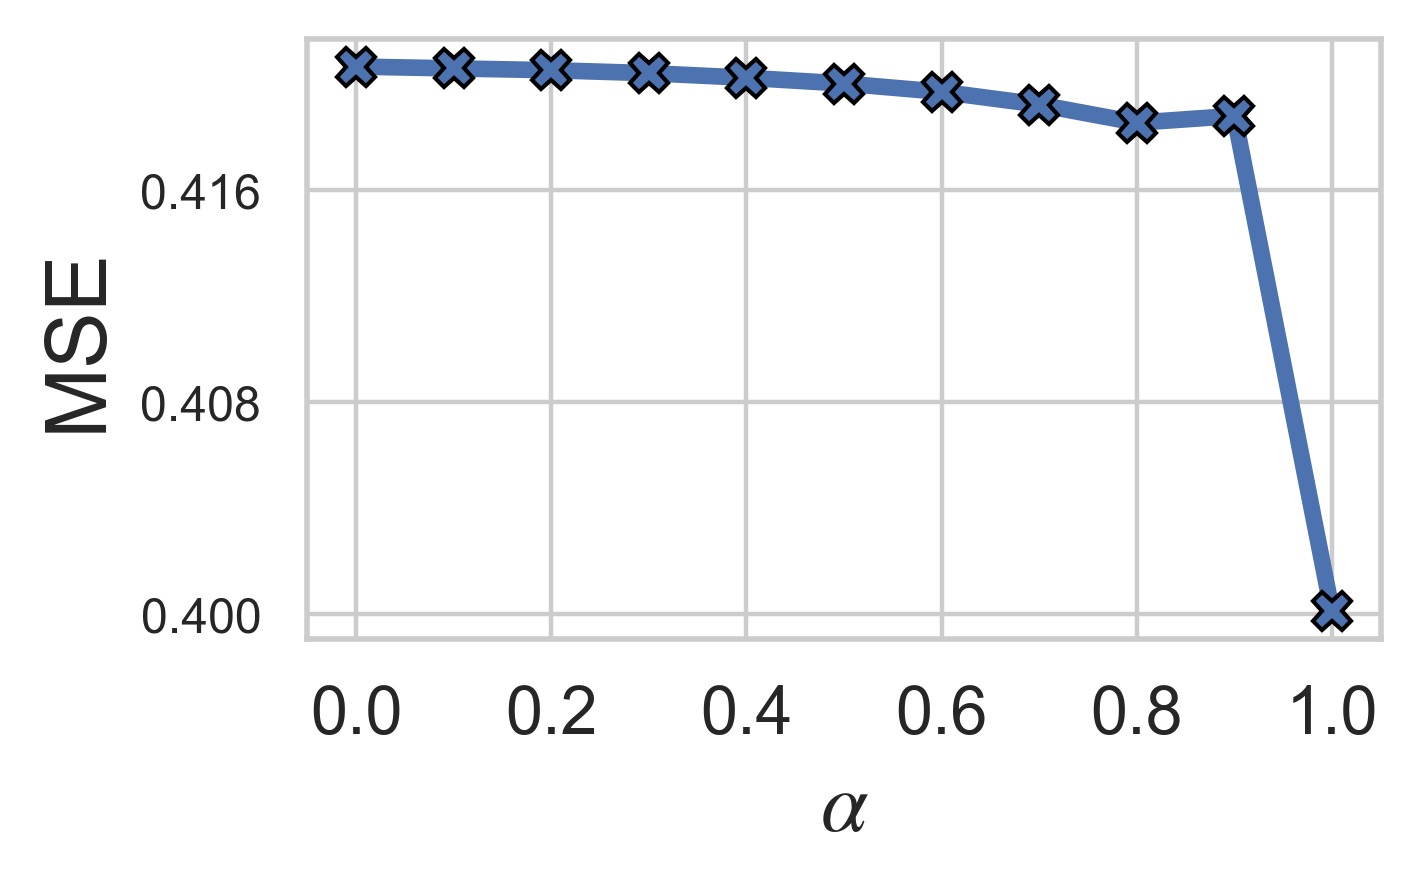

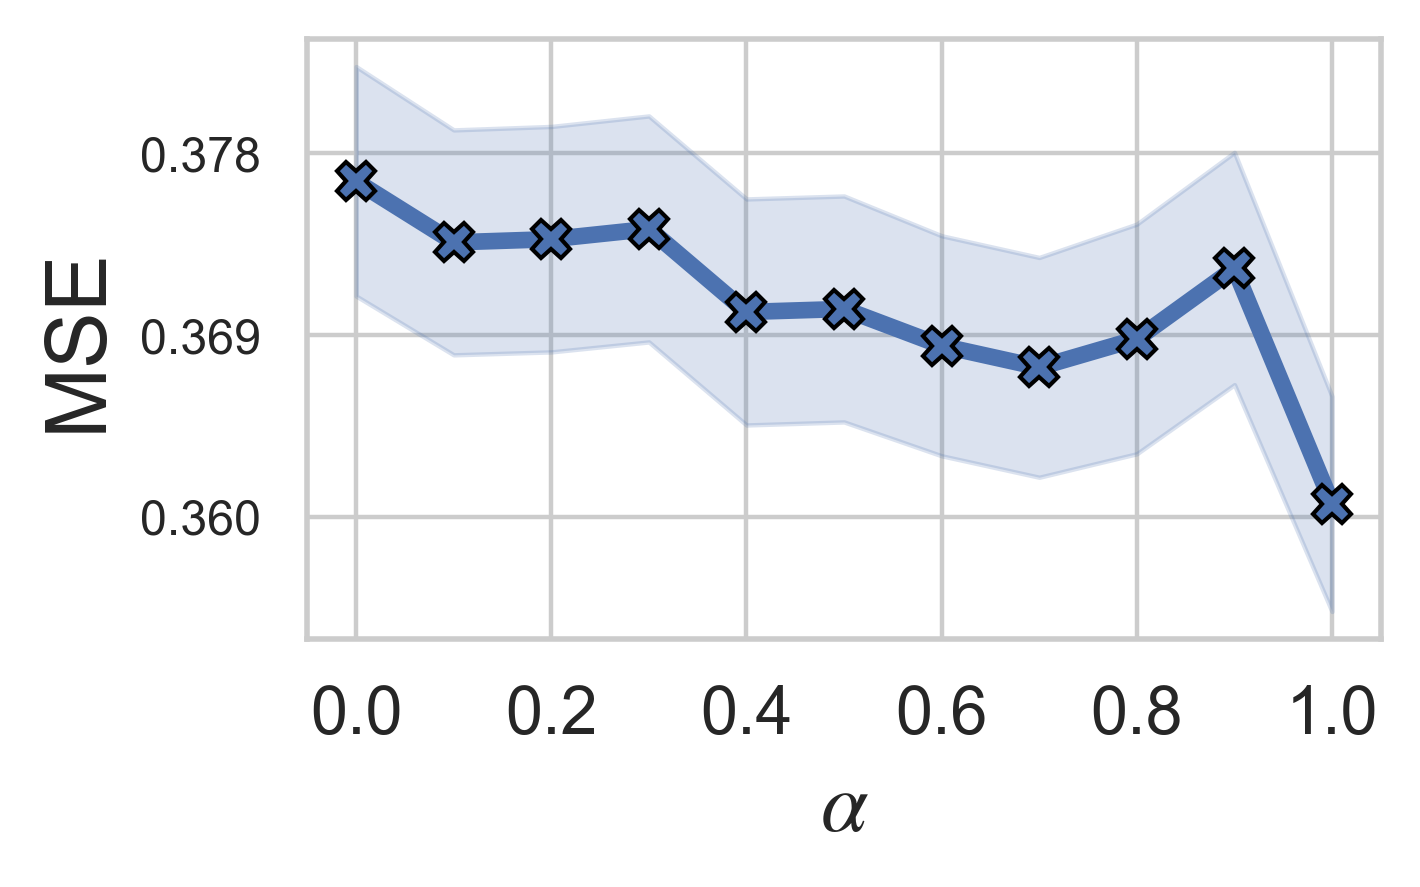

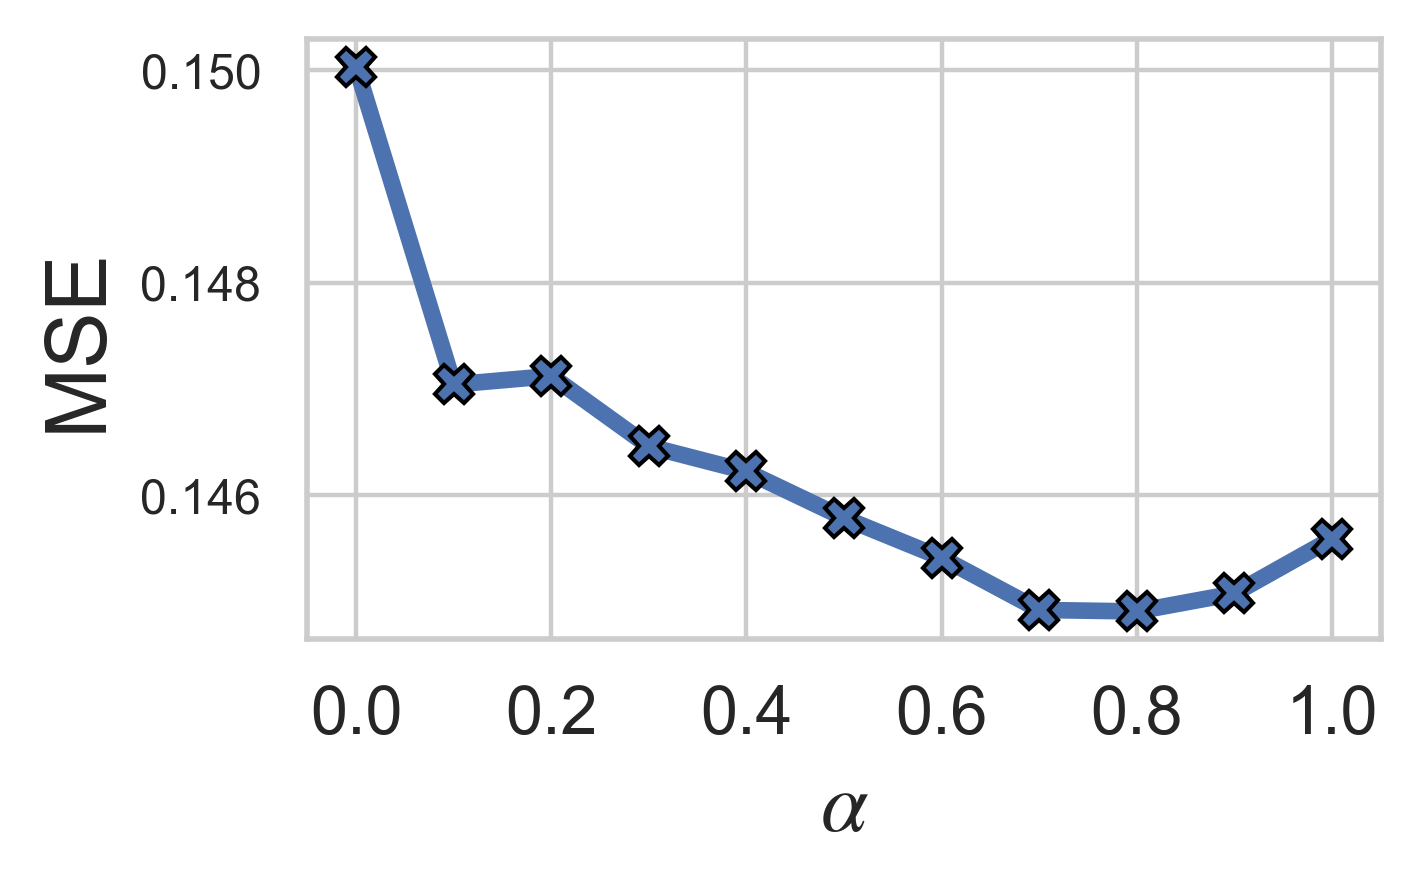

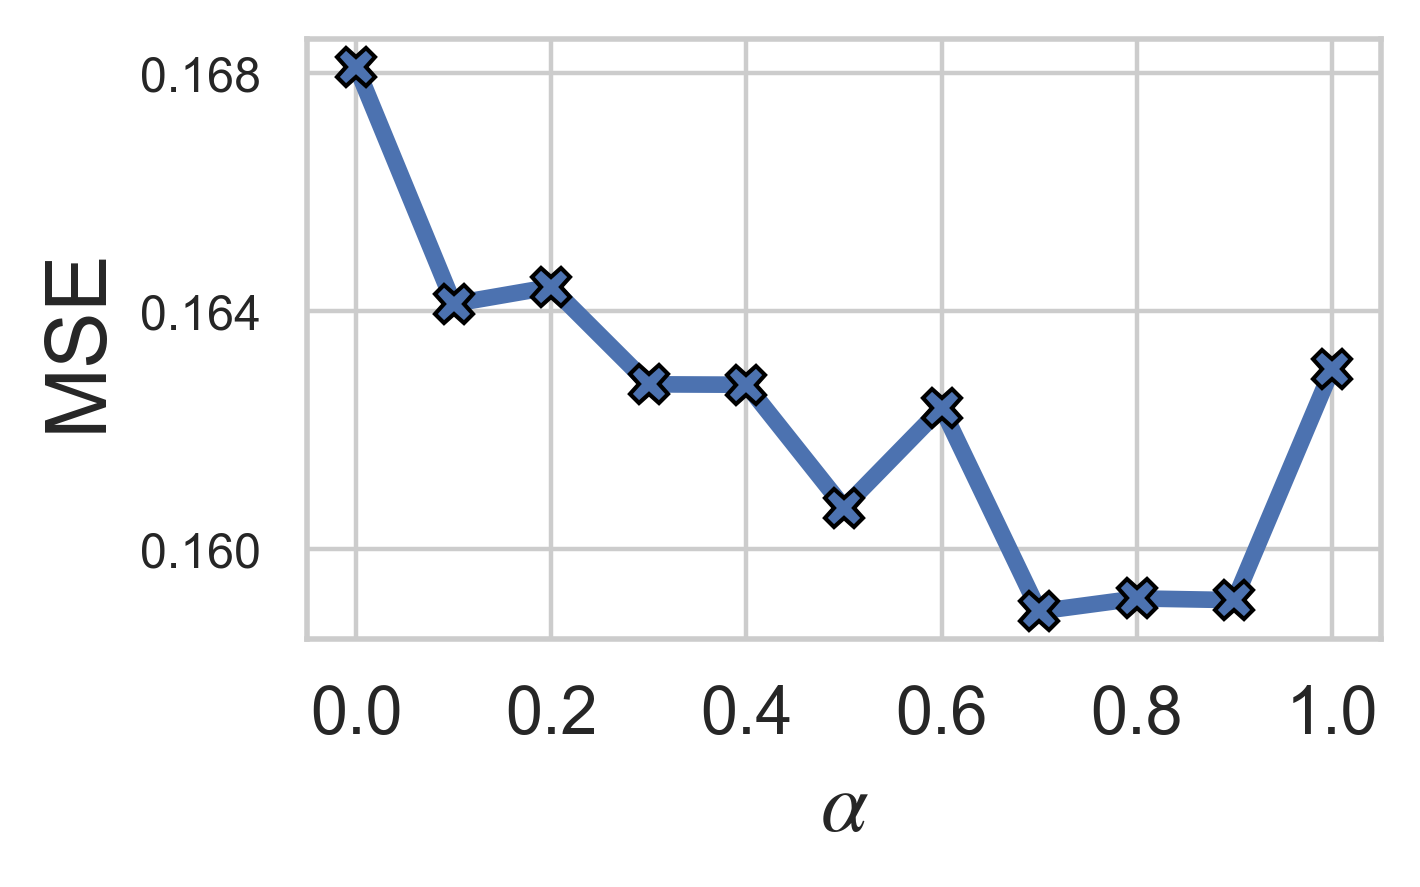

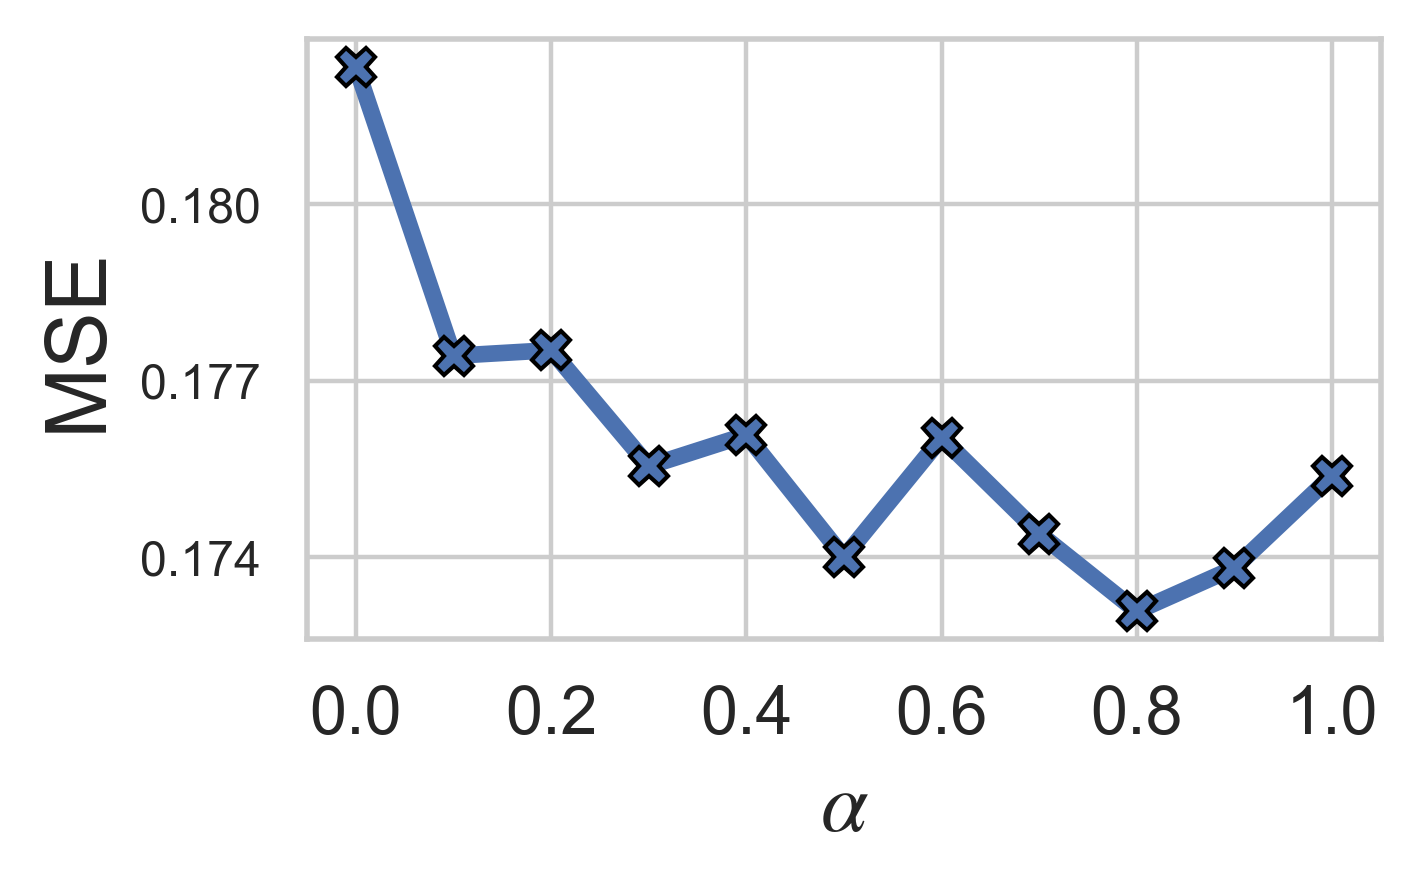

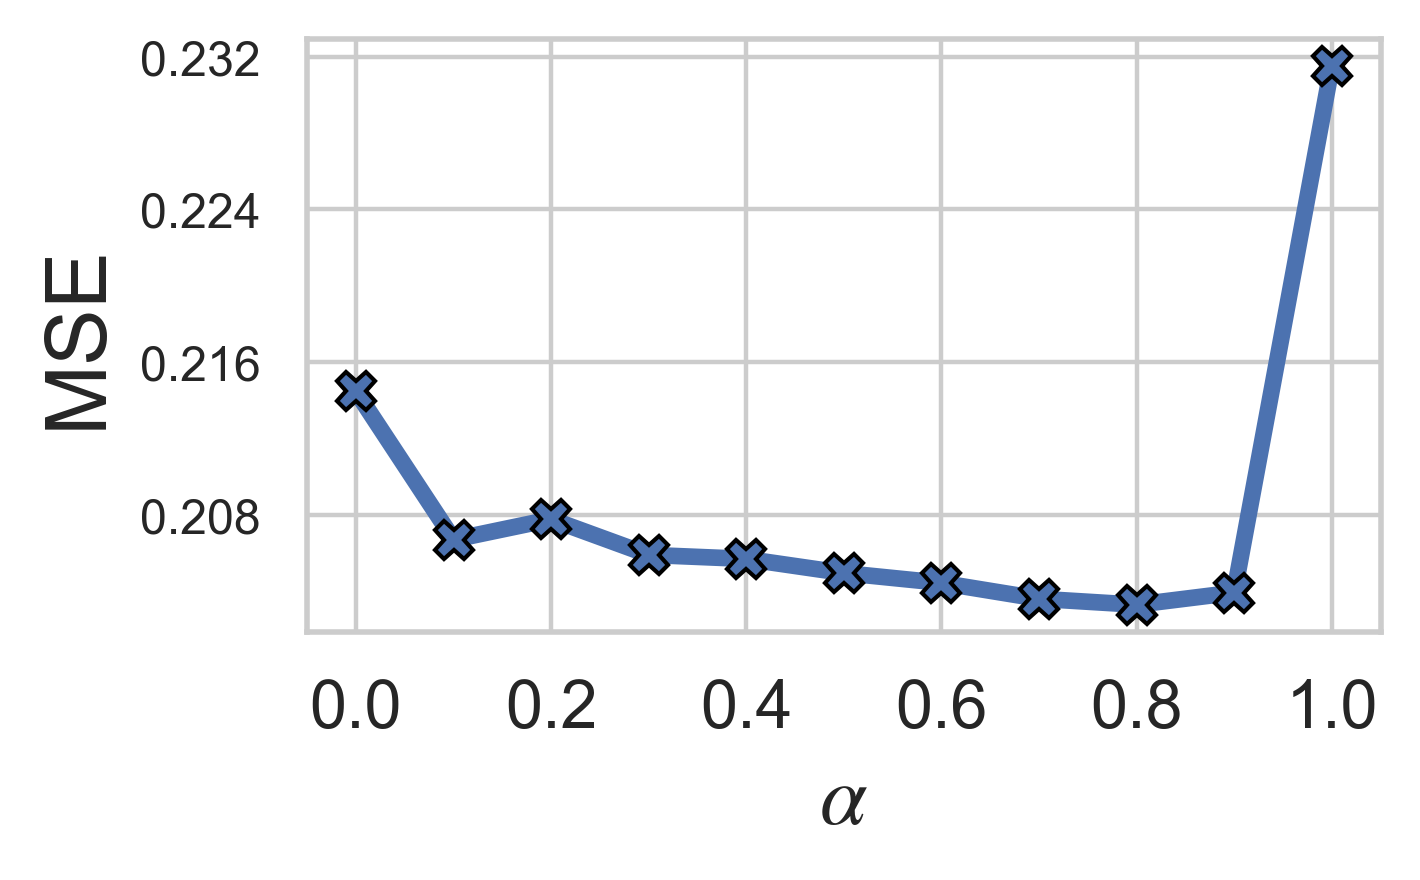

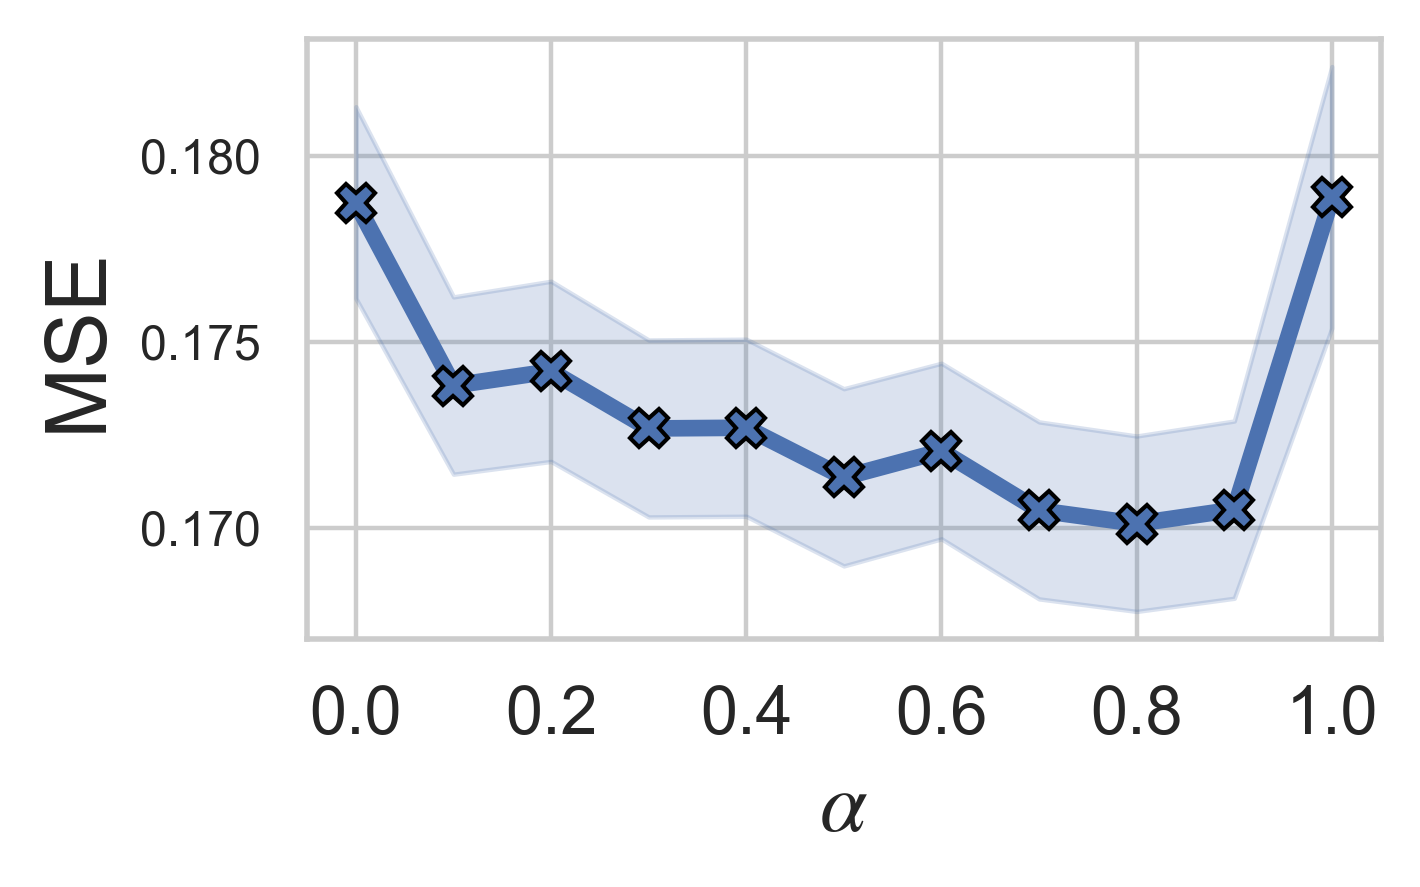

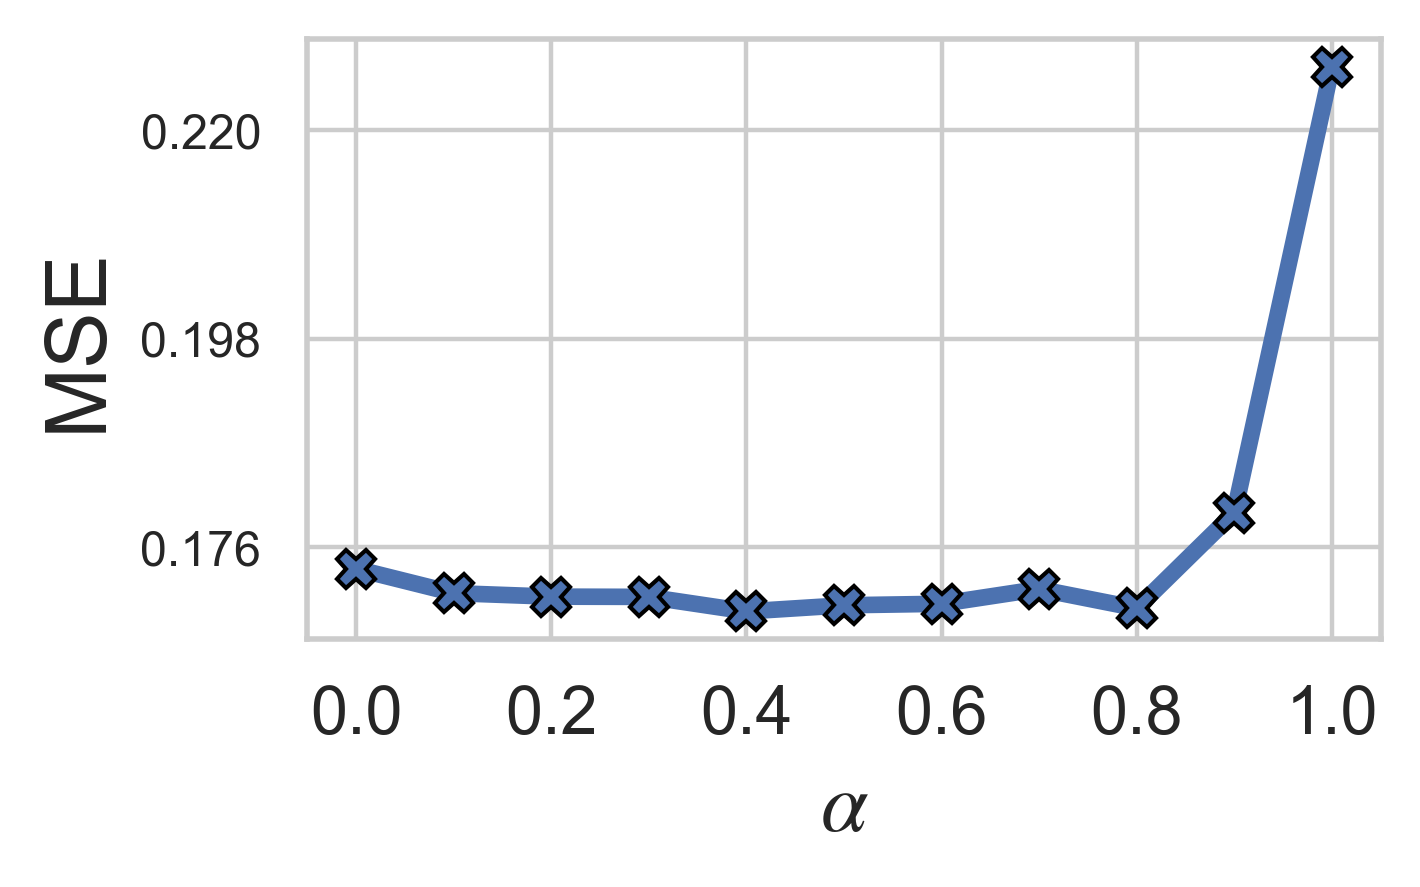

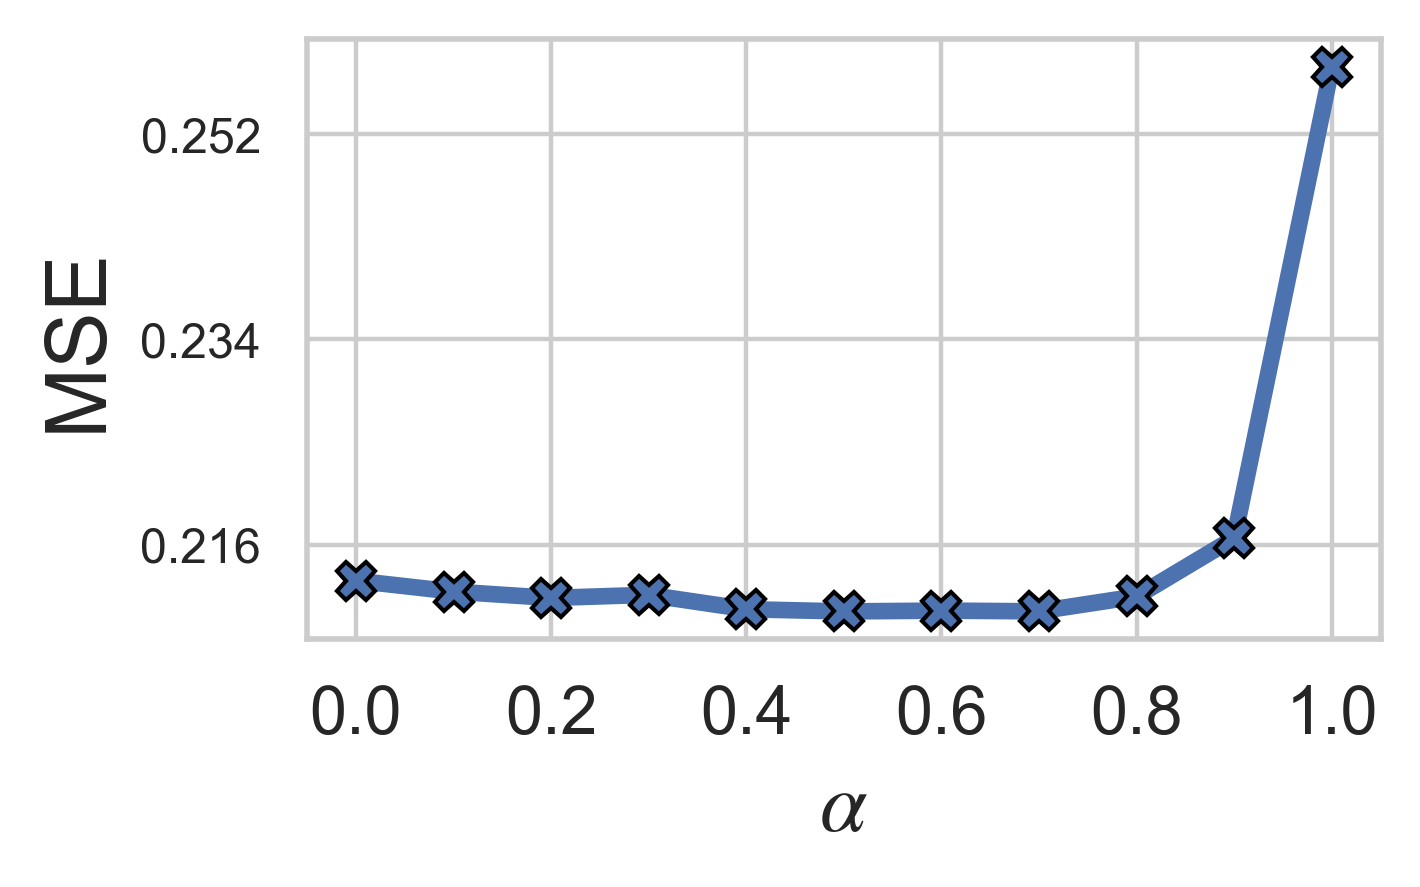

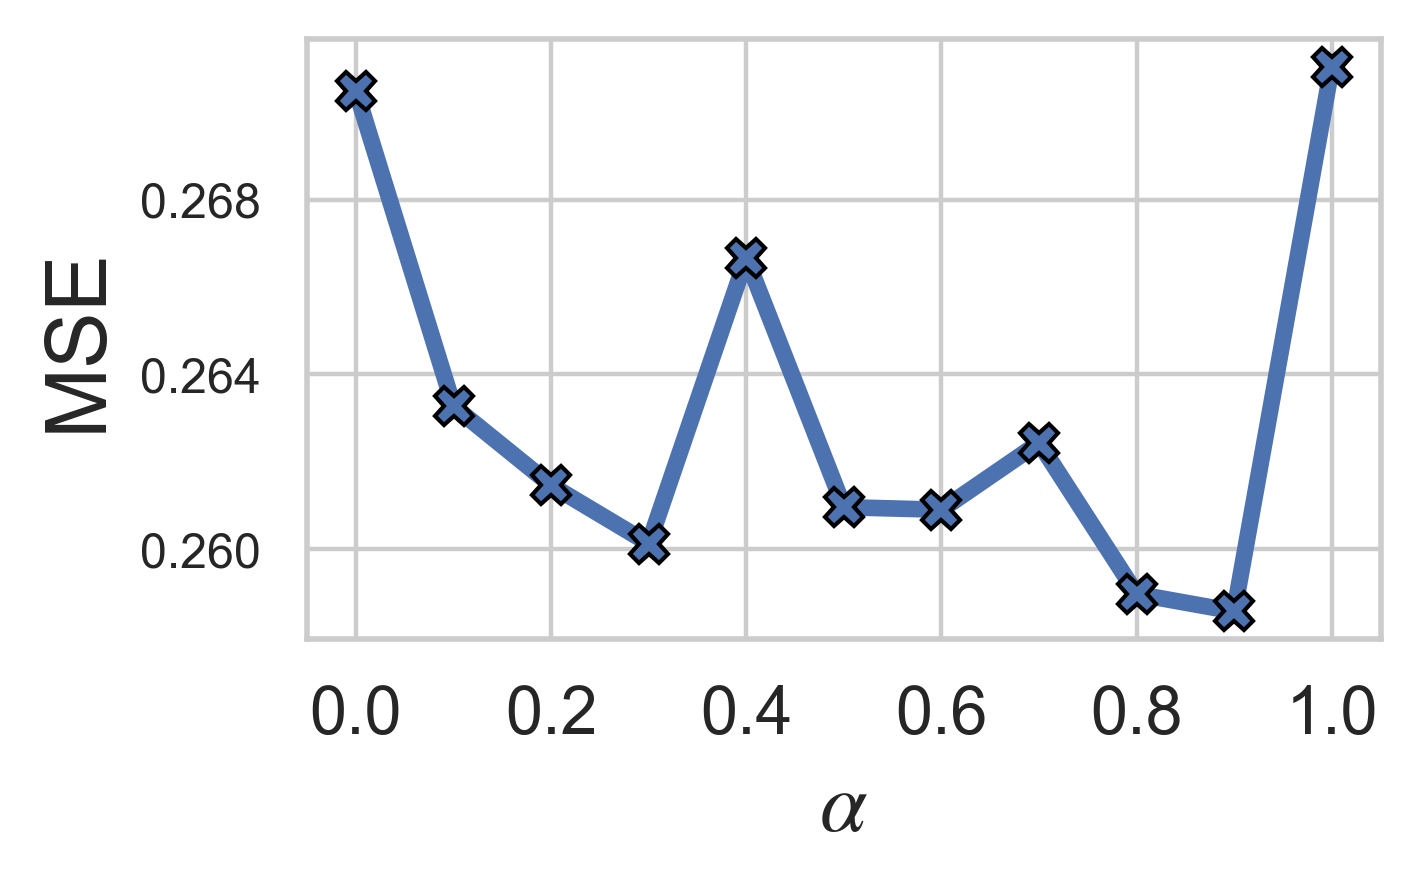

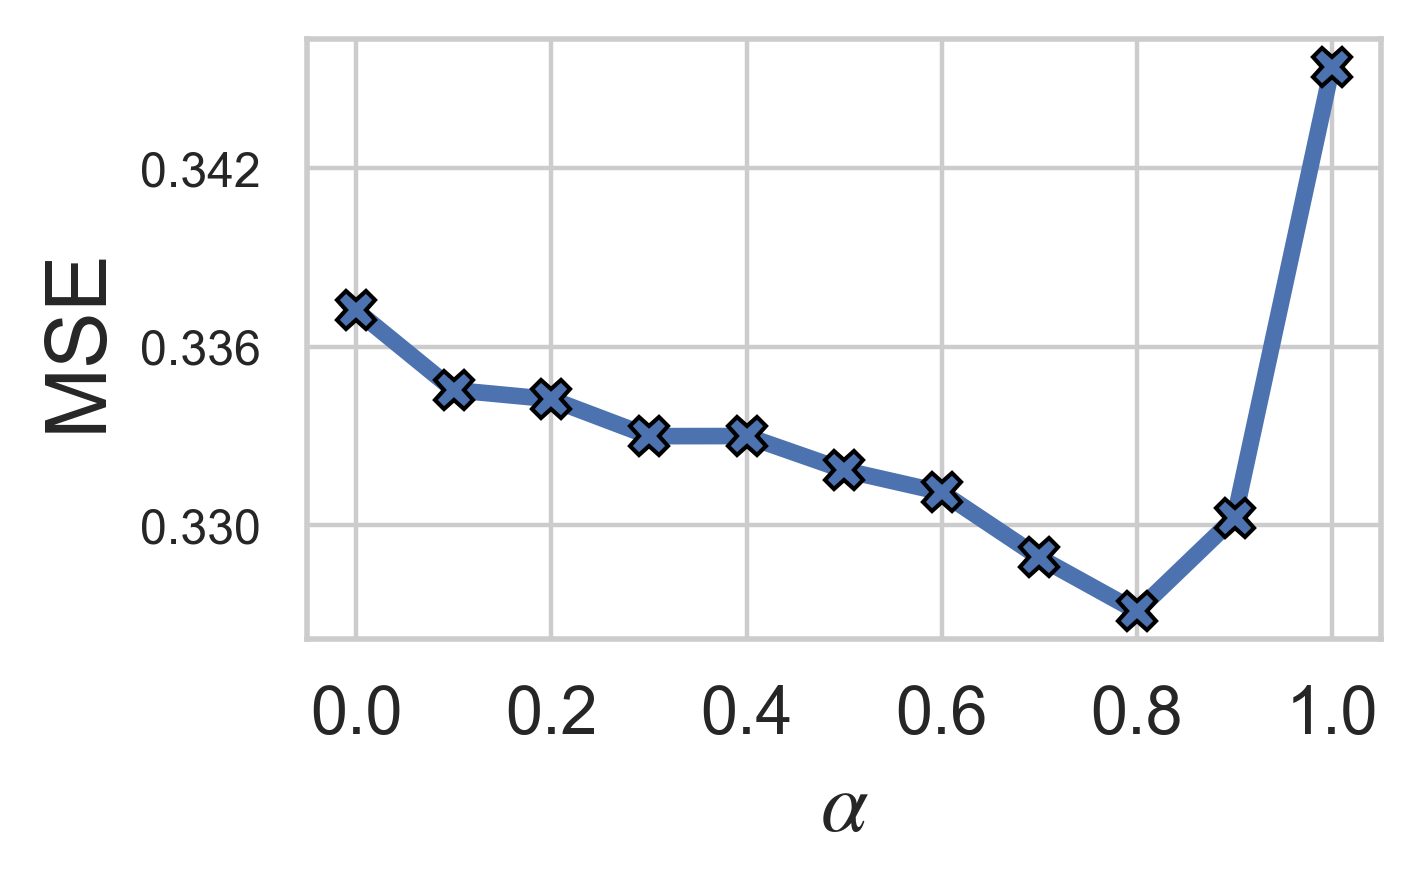

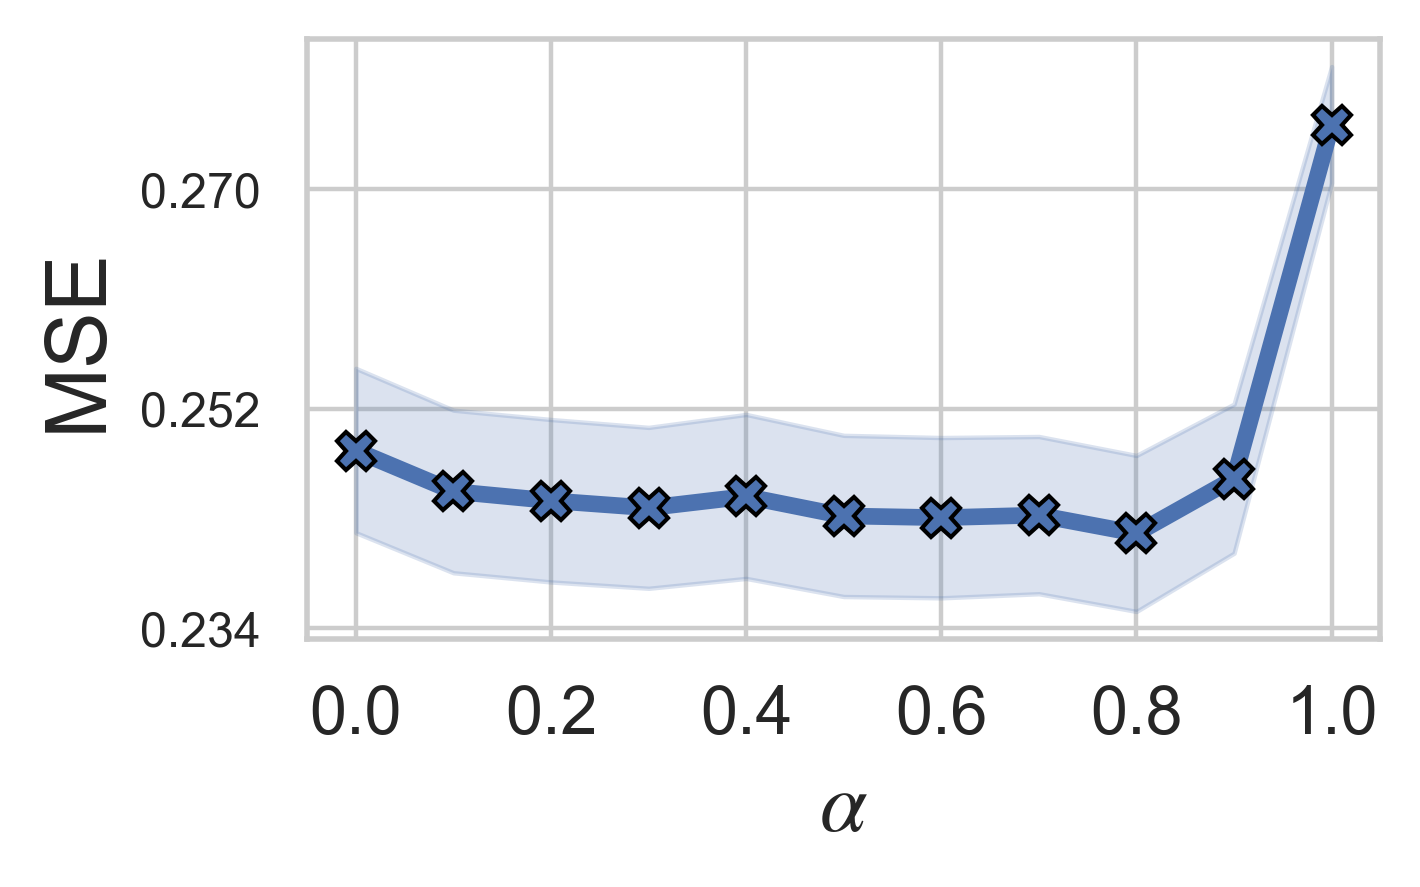

In [364]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper right'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 15
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='value', hue='metric', data=df, style='metric', errorbar=errorbar, markers=['X'], linewidth=3, markersize=7, markeredgecolor='k', palette=palette[1:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))  # 小数点后3位数间隔。
    leg = plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    leg.remove()
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize, axis='x')
    print(len(str(ypad1)), str(ypad1))
    if len(str(ypad1)) >= 5:  # 0.001
        plt.tick_params(labelsize=8.7, axis='y')
    else:
        plt.tick_params(labelsize=labelsize, axis='y')
    if ytick1:
        plt.yticks(ytick1)
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)

dfp = df_alpha.copy()
# dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study_all'
os.makedirs(save_dir, exist_ok=True)


data_id = 'ETTm1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.007)



data_id = 'ETTm2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.006)



data_id = 'ETTh1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.012)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.011)


data_id = 'ETTh2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.009)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.011)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.009)





data_id = 'ECL'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.005)



data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.022)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.018)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.006)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.018)

In [361]:
dfp = df_alpha.copy()
dfp['lambda'] = 1 - dfp['alpha']
dfp[(dfp.data_id == 'ECL') & (dfp.pred_len == 720)]

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate,lambda
435,iTransformer,ECL,720,0.0,0.214451,0.303504,1.0,0.0005,1.0
28060,iTransformer,ECL,720,0.1,0.206687,0.296968,0.3,0.0010,0.9
28011,iTransformer,ECL,720,0.2,0.234212,0.317582,0.3,0.0010,0.8
28015,iTransformer,ECL,720,0.3,0.205887,0.295924,0.3,0.0010,0.7
28685,iTransformer,ECL,720,0.4,0.205676,0.295784,0.3,0.0010,0.6
28069,iTransformer,ECL,720,0.5,0.204935,0.294531,0.3,0.0010,0.5
28514,iTransformer,ECL,720,0.6,0.204421,0.294209,0.3,0.0010,0.4
28364,iTransformer,ECL,720,0.7,0.203587,0.292666,0.3,0.0010,0.3
28027,iTransformer,ECL,720,0.8,0.203276,0.292044,0.3,0.0010,0.2
28603,iTransformer,ECL,720,0.9,0.203909,0.293026,0.3,0.0010,0.1


# Varying rank ratio

## load data

In [429]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')

hpr = finetunes_all.copy()
hpr = hpr[
    (hpr.pca_dim == 'T') &
    (hpr.use_weights == 0) &
    (hpr.auxi_loss == 'MAE') &
    (hpr.reinit == 1) &
    (hpr.seq_len == 96)
]
hpr = hpr[
    ((hpr.data_id == 'ETTh1_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTh2_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTm1_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTm2_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ECL_PCA') & (hpr.model == 'iTransformer')) |
    ((hpr.data_id == 'Weather_PCA') & (hpr.model == 'FreTS'))
]
hpr.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)
hpr.drop(columns=['rec_lambda'], inplace=True)


## preprocess main

In [22]:
df2 = hpr.copy()

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'rank_ratio'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae']
df2 = df2[columns]

df_rank = df2.copy()

dst_order = ['ECL', 'Weather']
df_rank['data_id'] = pd.Categorical(df_rank['data_id'], categories=dst_order, ordered=True)

df_rank['rank_ratio'] = df_rank['rank_ratio'].astype(float)

df_rank.sort_values(by=['model', 'data_id', 'rank_ratio', 'pred_len'], inplace=True)
df_rank.head(10)

,model,data_id,pred_len,rank_ratio,mse,mae
17624,FreTS,Weather,96,0.1,0.169180,0.218550
18238,FreTS,Weather,192,0.1,0.210151,0.257542
19533,FreTS,Weather,336,0.1,0.259758,0.299223
20244,FreTS,Weather,720,0.1,0.332509,0.358654
17721,FreTS,Weather,96,0.2,0.170224,0.219298
18582,FreTS,Weather,192,0.2,0.211219,0.259222
19275,FreTS,Weather,336,0.2,0.259515,0.299225
20333,FreTS,Weather,720,0.2,0.331536,0.356959
17167,FreTS,Weather,96,0.3,0.170041,0.218852
18908,FreTS,Weather,192,0.3,0.210166,0.258879


## plot main

In [ ]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'center right'  # 这里可以根据图的实际情况调节。
    labelsize = 12

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mse', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize)
    if ytick1:
        plt.yticks(ytick1)
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MSE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mae', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MAE')
    plt.tick_params(labelsize=labelsize)
    if ytick2:
        plt.yticks(ytick2)
    if ylim2:
        plt.ylim(ylim2)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MAE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


dfp = df_rank.copy()
dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study'
os.makedirs(save_dir, exist_ok=True)


# dfp_ = dfp[(dfp.model == 'iTransformer')]
# dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
# plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$c_r$', figure_name=f'iTrans_ECL_rank', ypad1=0.01, ypad2=0.01)

dfp_ = dfp[(dfp.model == 'FreTS')]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$c_r$', figure_name=f'FreTS_Weather_rank', ypad1=0.02, ypad2=0.02, ylim1=None, ylim2=None)

## preprocess all

In [430]:
df2 = hpr.copy()

df2 = df2[
    ((df2.alpha == 0.4) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.9) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.7) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.7) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.8) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    
    ((df2.alpha == 0.4) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.5) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.9) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
]

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'rank_ratio'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae', 'alpha', 'learning_rate']
df2 = df2[columns]

df_rank = df2.copy()

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df_rank['data_id'] = pd.Categorical(df_rank['data_id'], categories=dst_order, ordered=True)

df_rank['rank_ratio'] = df_rank['rank_ratio'].astype(float)
df_rank.dropna(inplace=True, thresh=6)

df_rank.sort_values(by=['model', 'data_id', 'rank_ratio', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae']
df_rank[columns].to_csv(f'{save_root}/hyper_study_rank.csv', index=False)


df_rank.head(10)

,model,data_id,pred_len,rank_ratio,mse,mae,alpha,learning_rate
17683,FreTS,Weather,96,0.1,0.169180,0.218550,0.4,0.001
18340,FreTS,Weather,192,0.1,0.210151,0.257542,0.5,0.001
19937,FreTS,Weather,336,0.1,0.262991,0.303337,0.9,0.001
20474,FreTS,Weather,720,0.1,0.332509,0.358654,0.8,0.001
17978,FreTS,Weather,96,0.2,0.170574,0.221245,0.4,0.001
18600,FreTS,Weather,192,0.2,0.212215,0.263896,0.5,0.001
19422,FreTS,Weather,336,0.2,0.263449,0.307732,0.9,0.001
21100,FreTS,Weather,720,0.2,0.332972,0.360792,0.8,0.001
17323,FreTS,Weather,96,0.3,0.172162,0.221892,0.4,0.001
18899,FreTS,Weather,192,0.3,0.211644,0.262187,0.5,0.001


## plot all

/tmp/ipykernel_3448545/295659489.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5


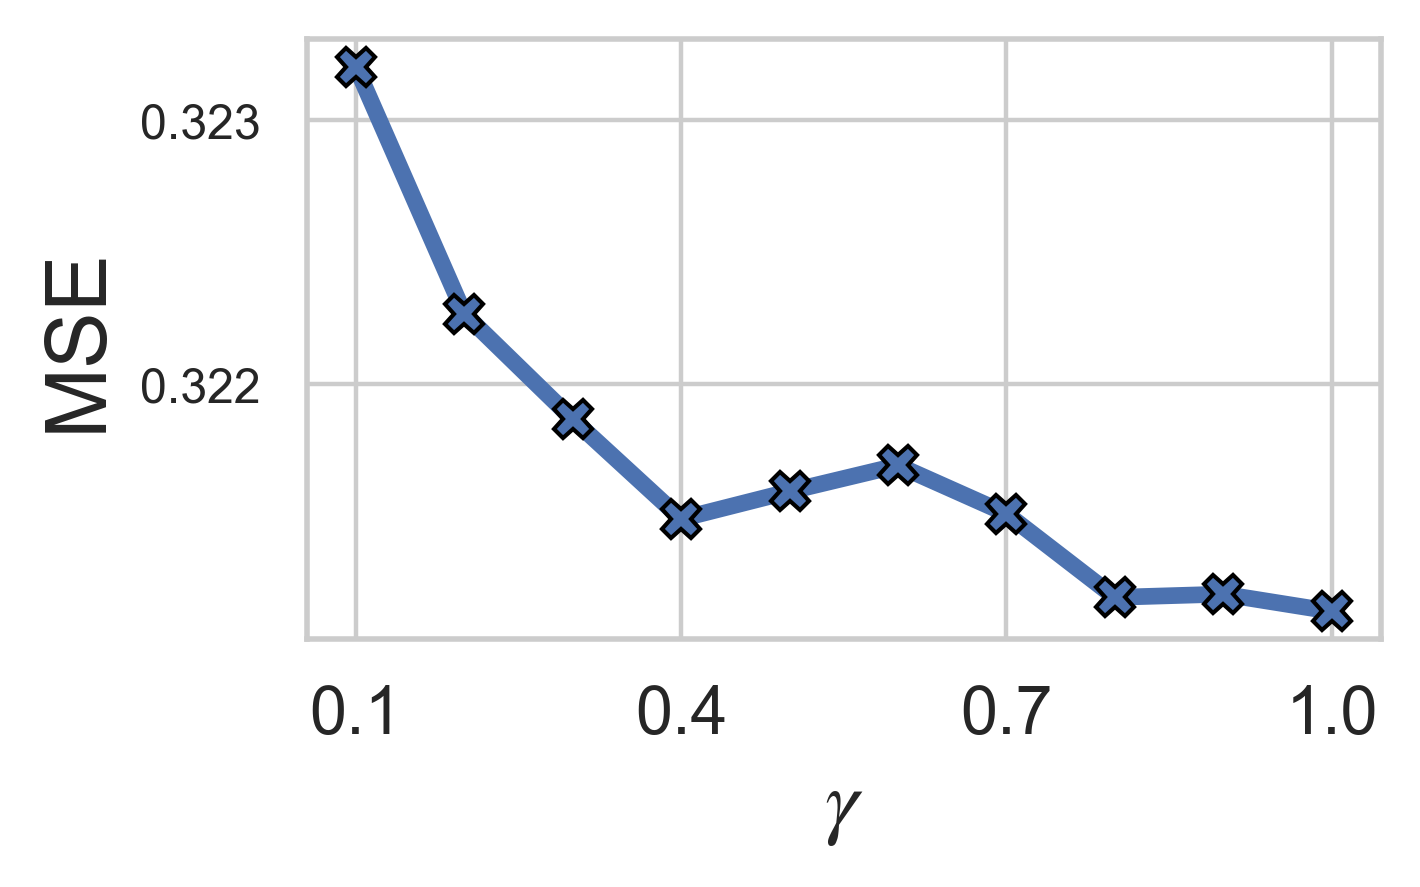

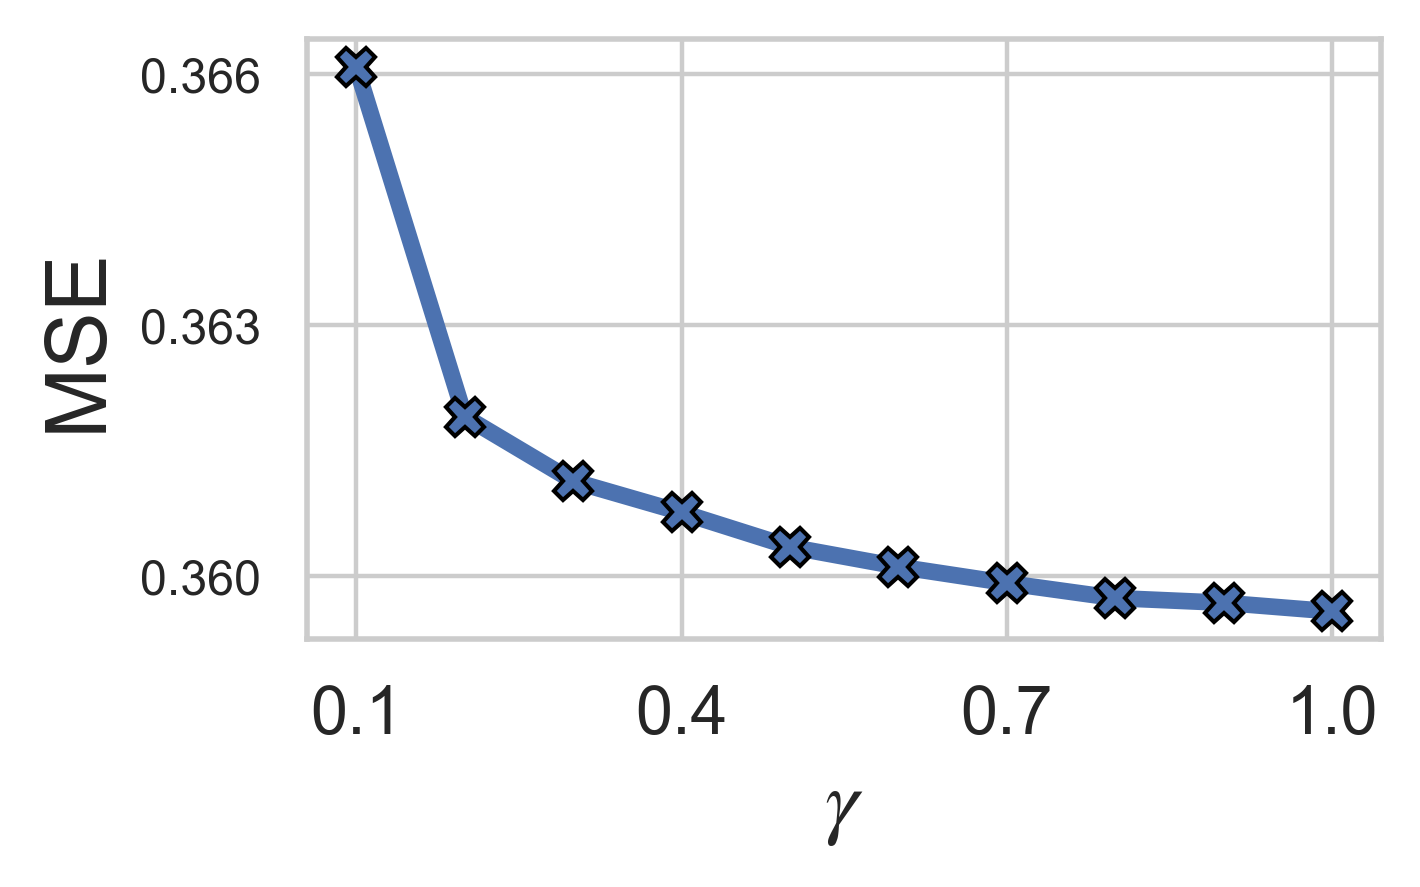

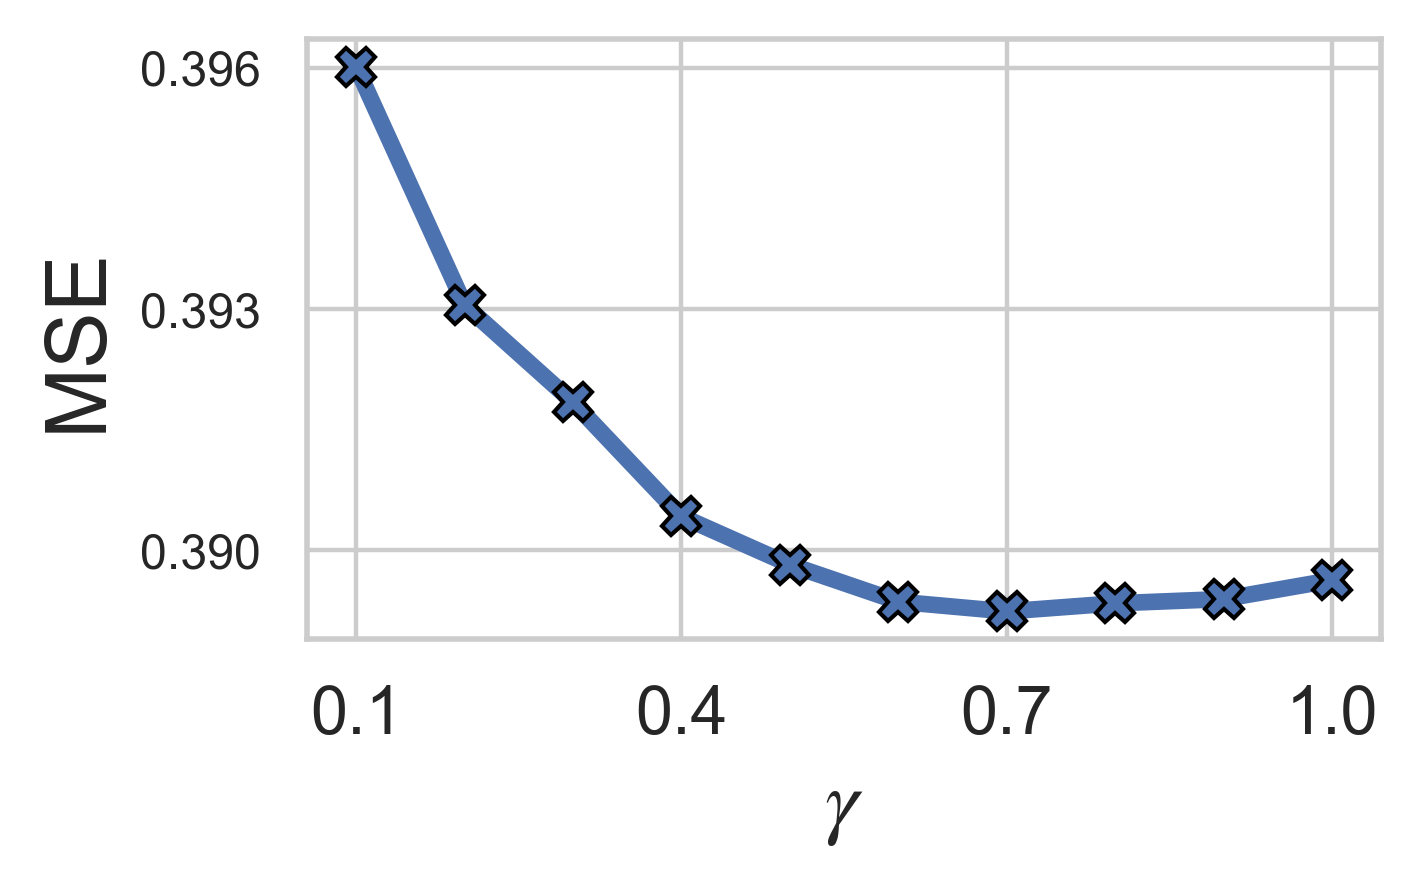

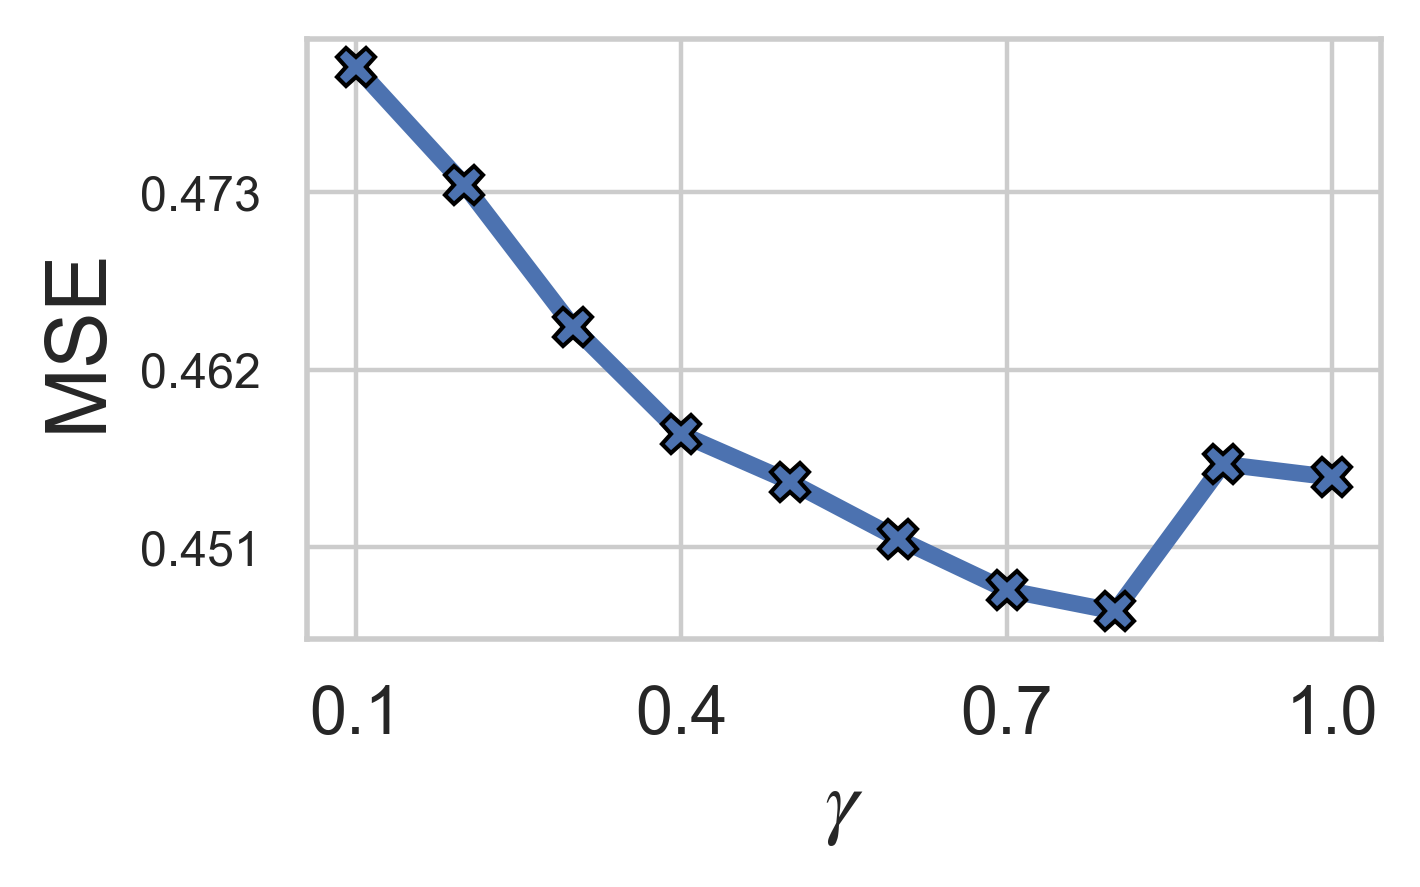

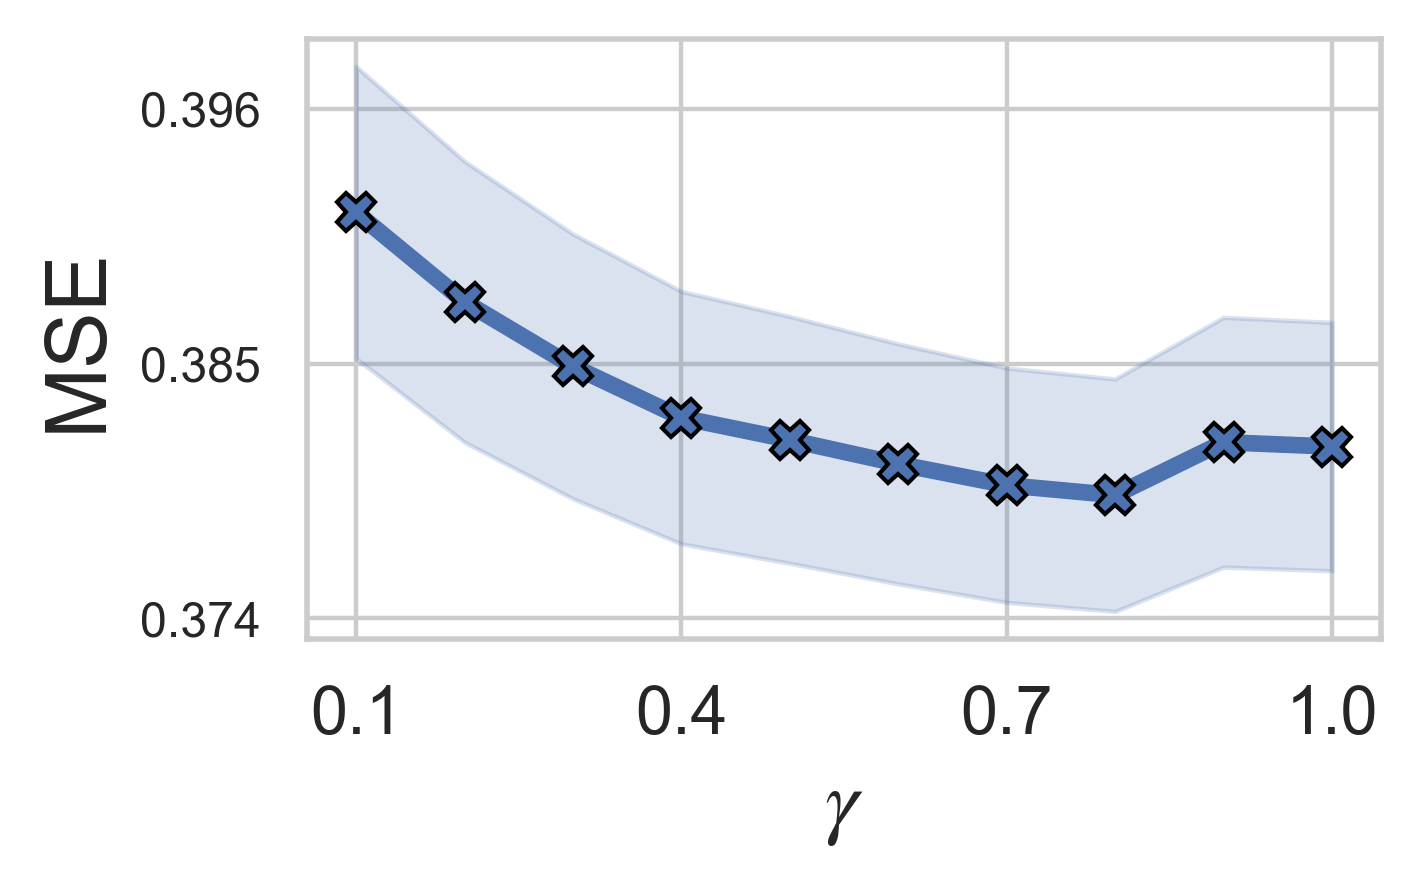

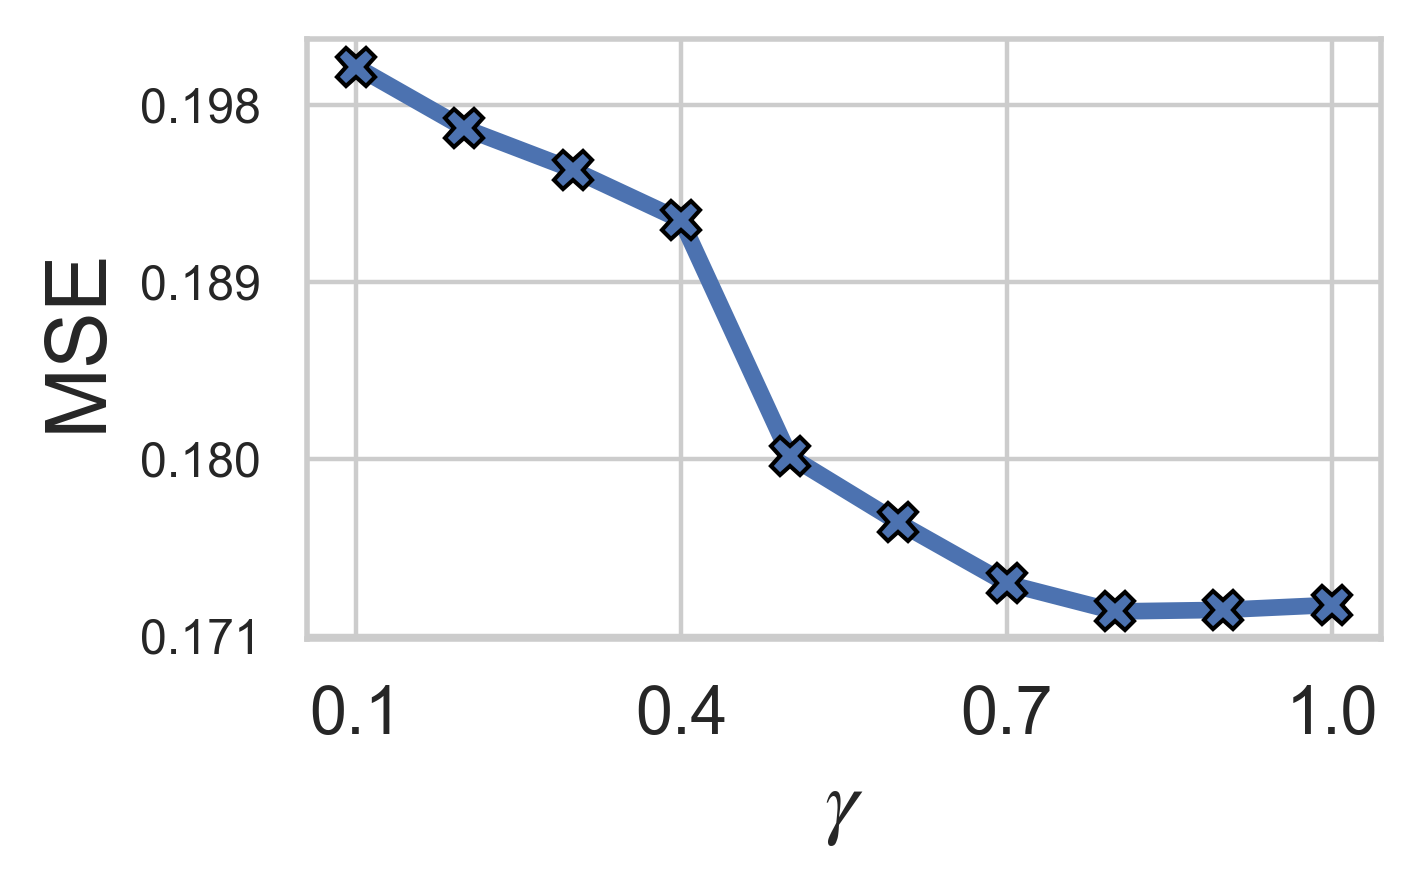

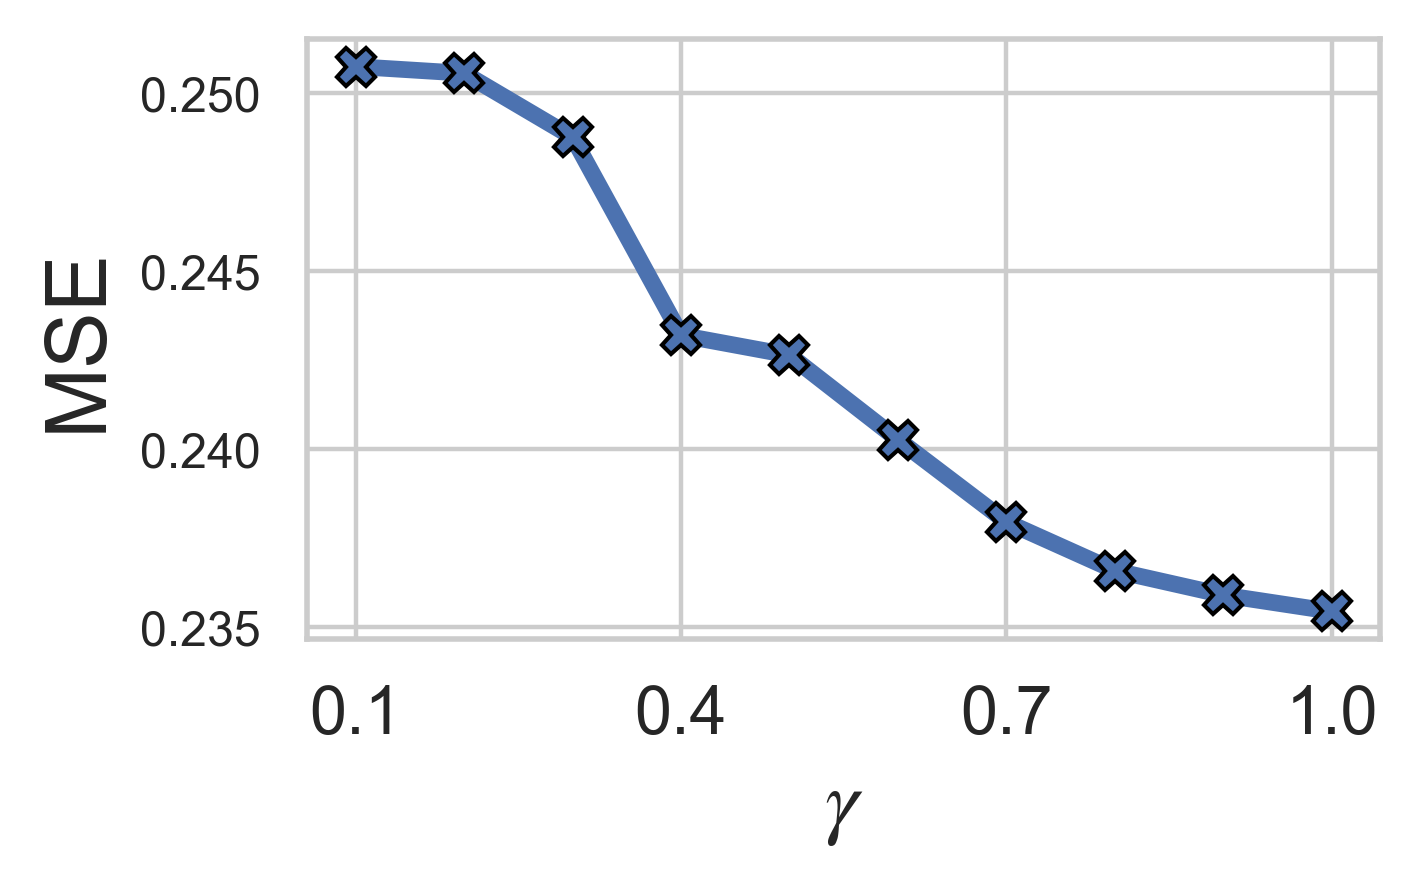

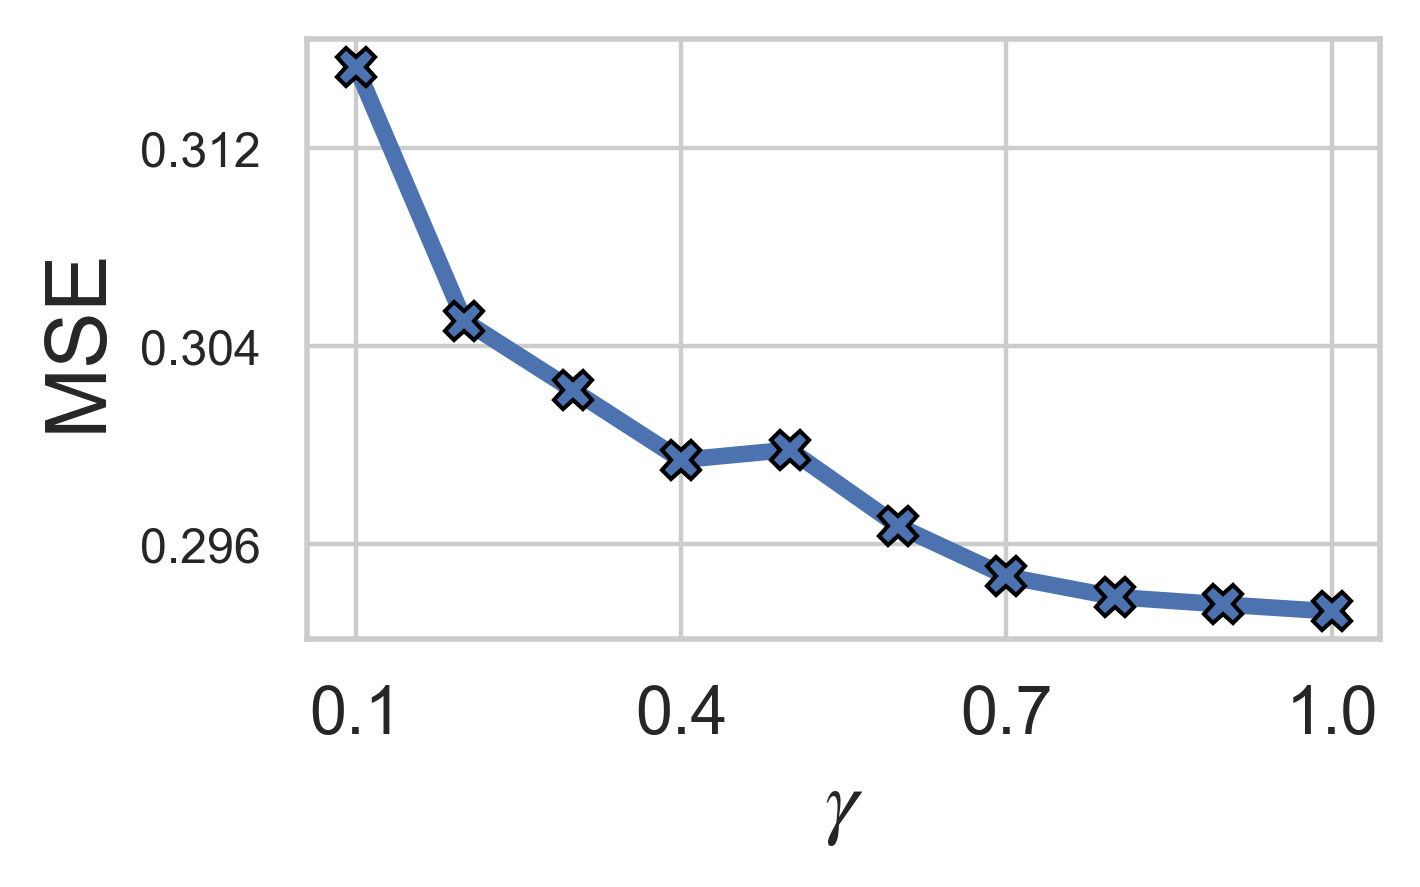

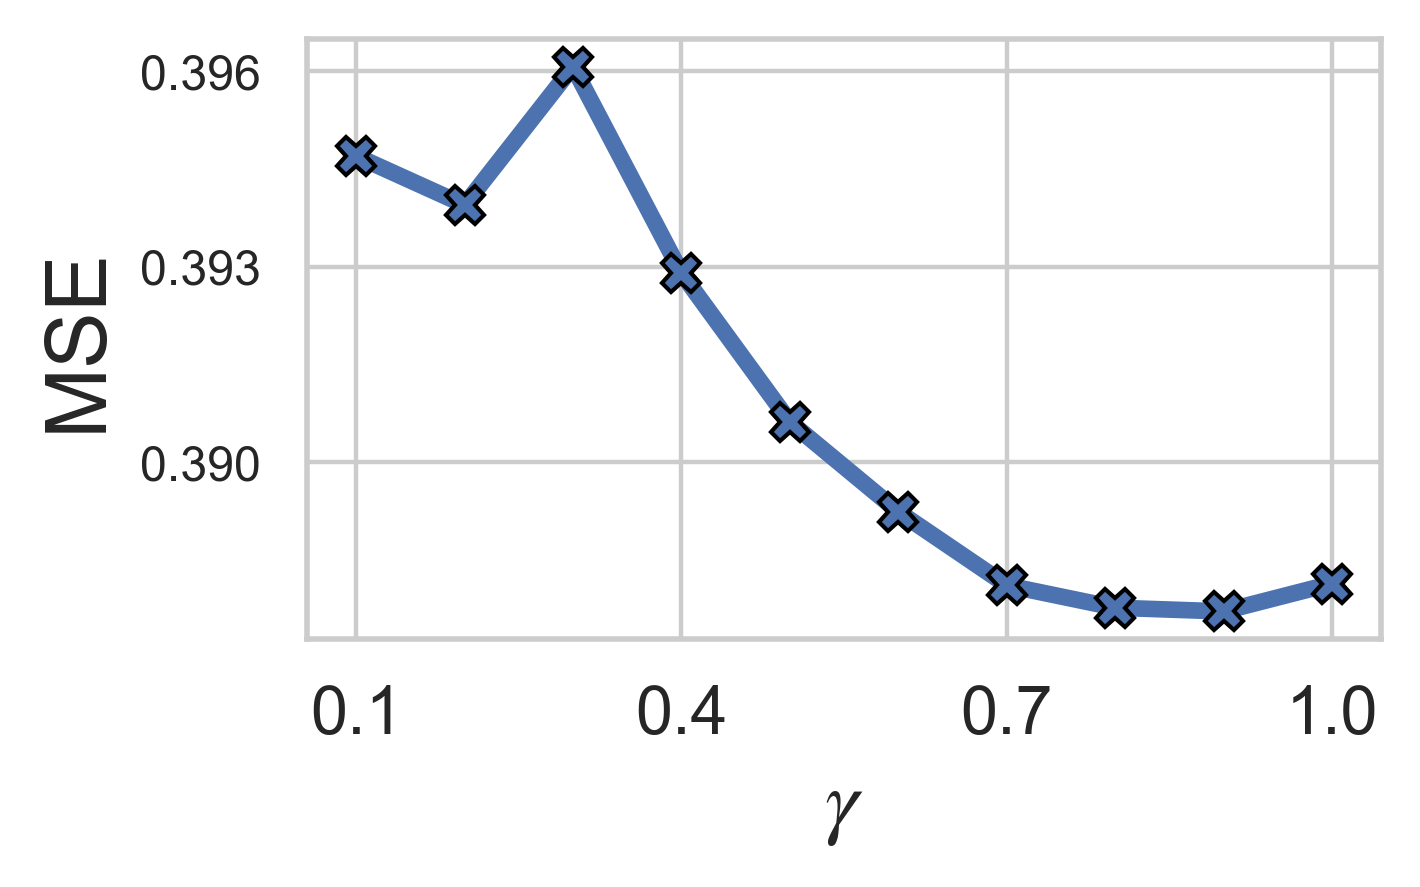

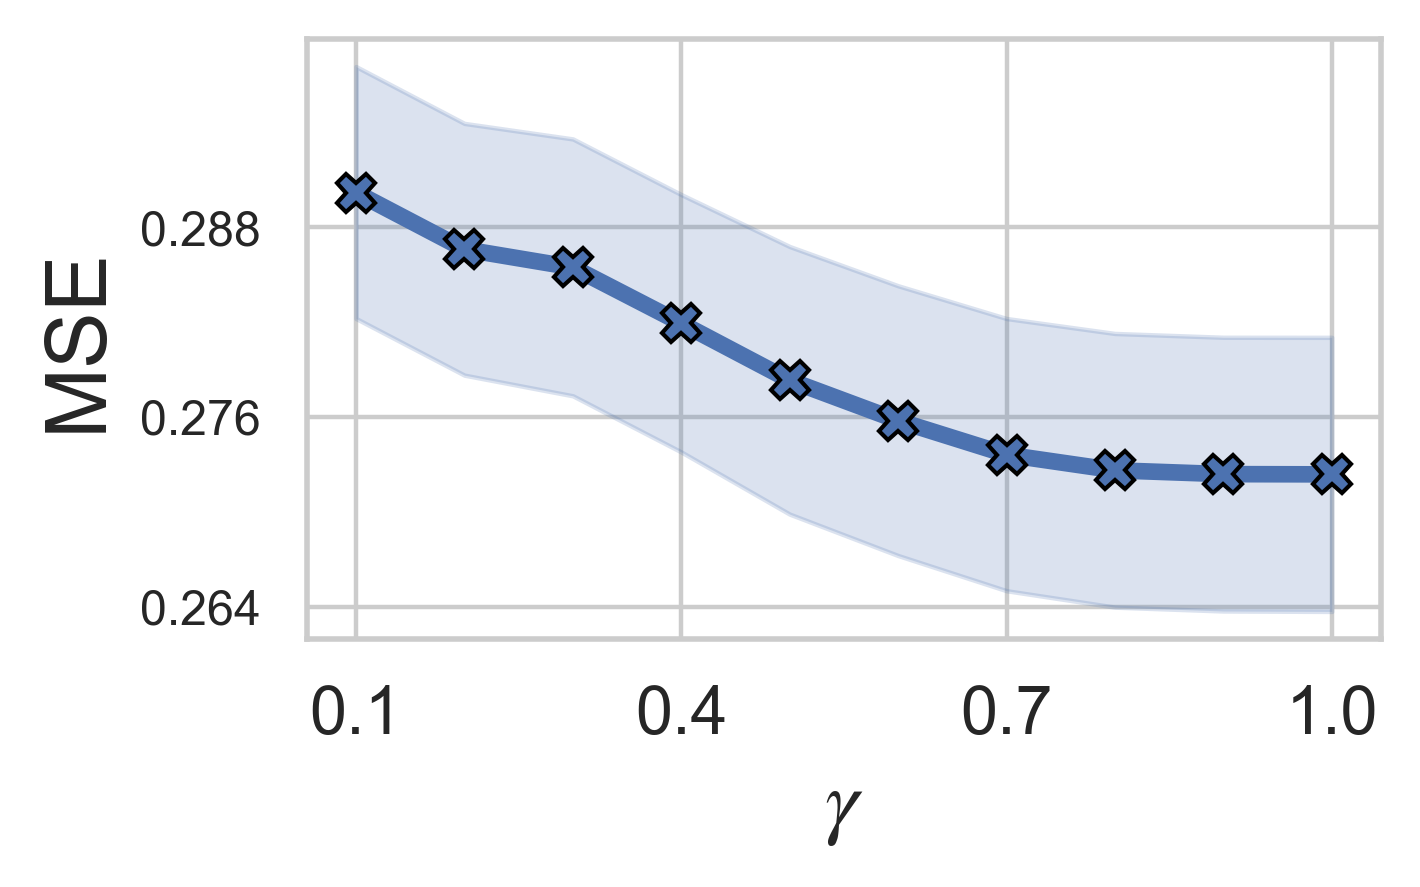

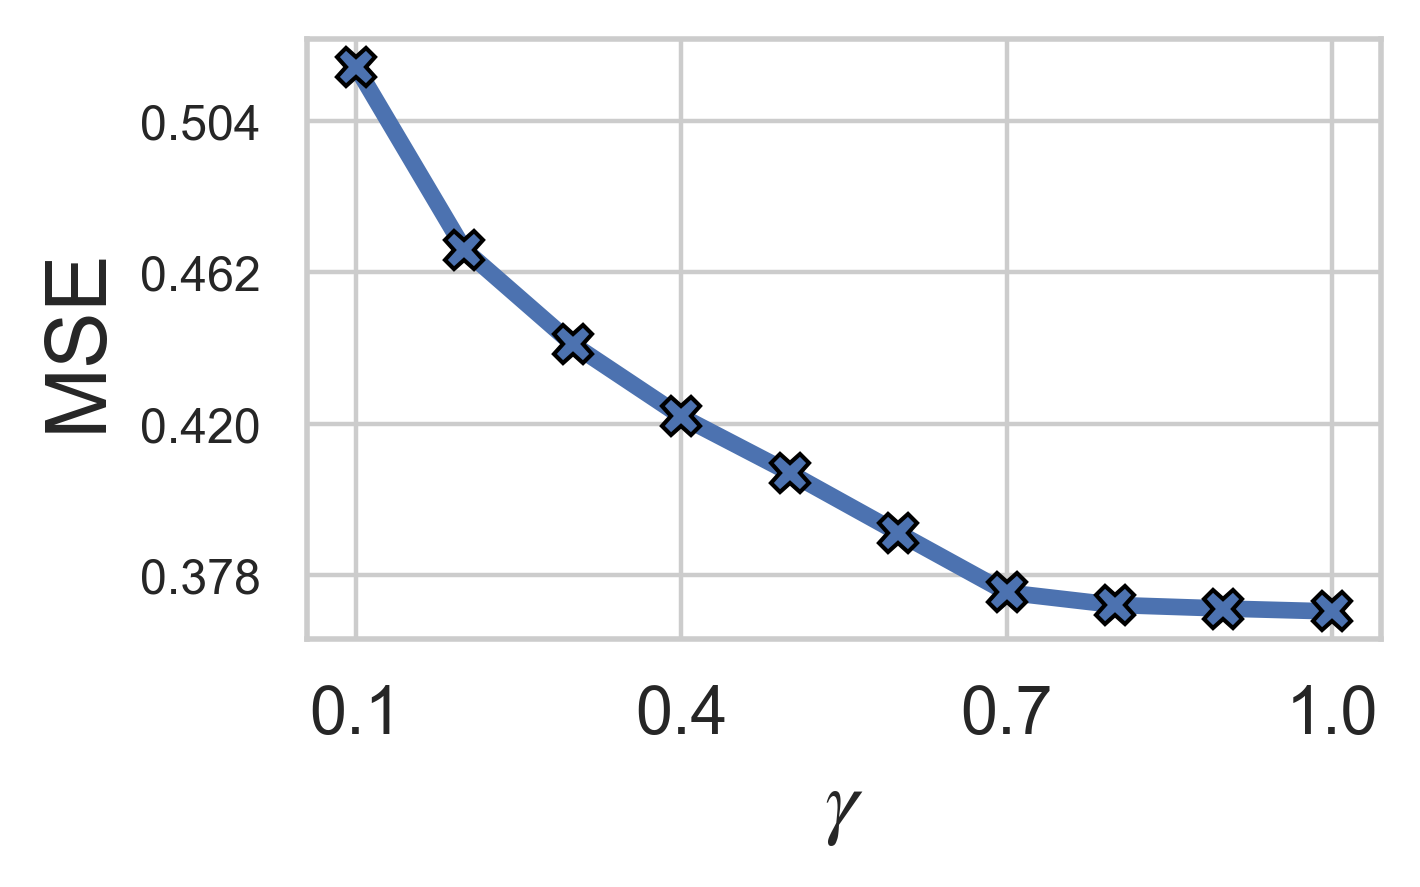

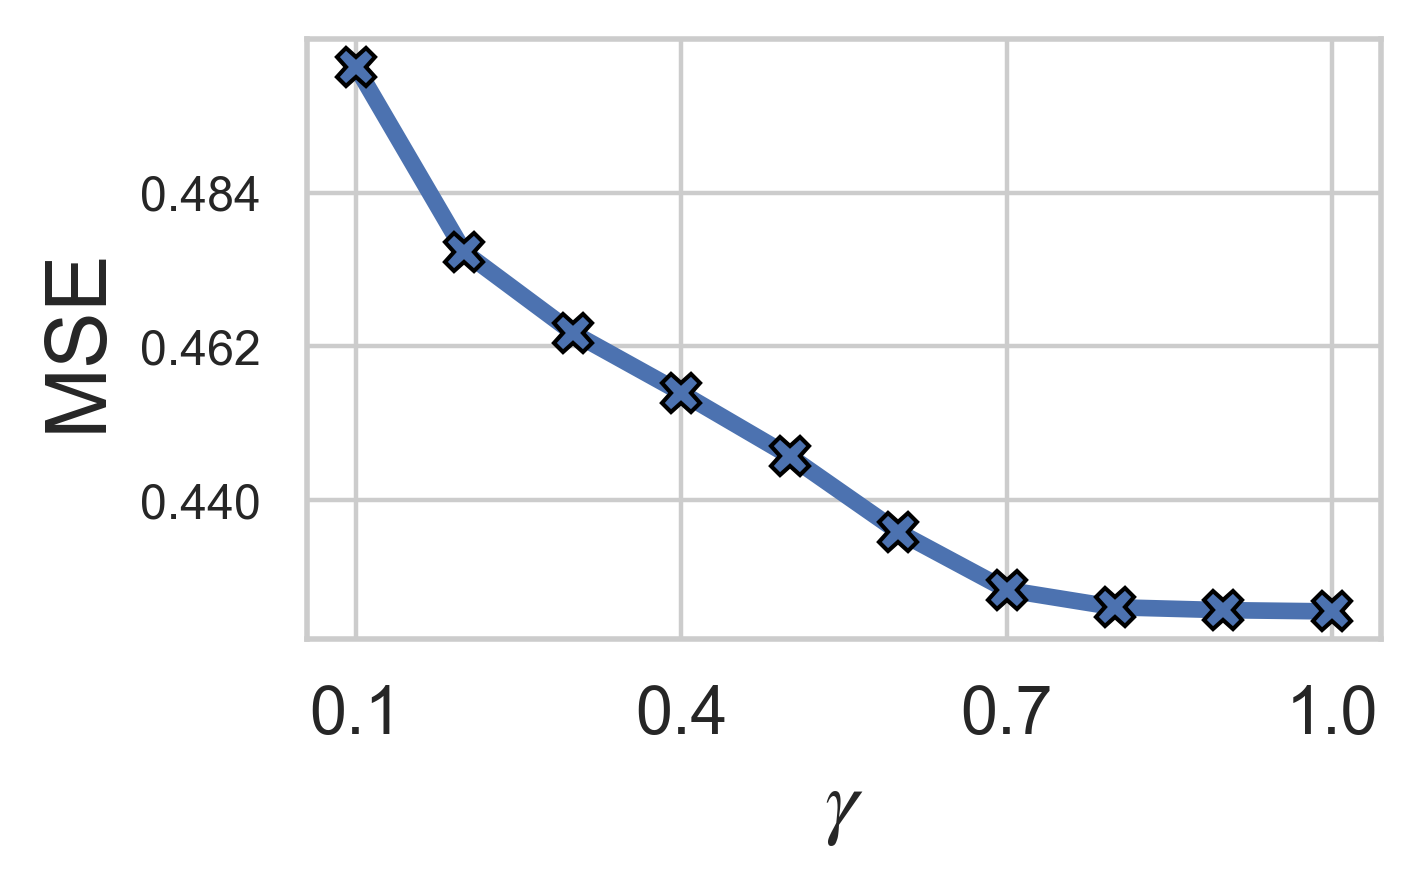

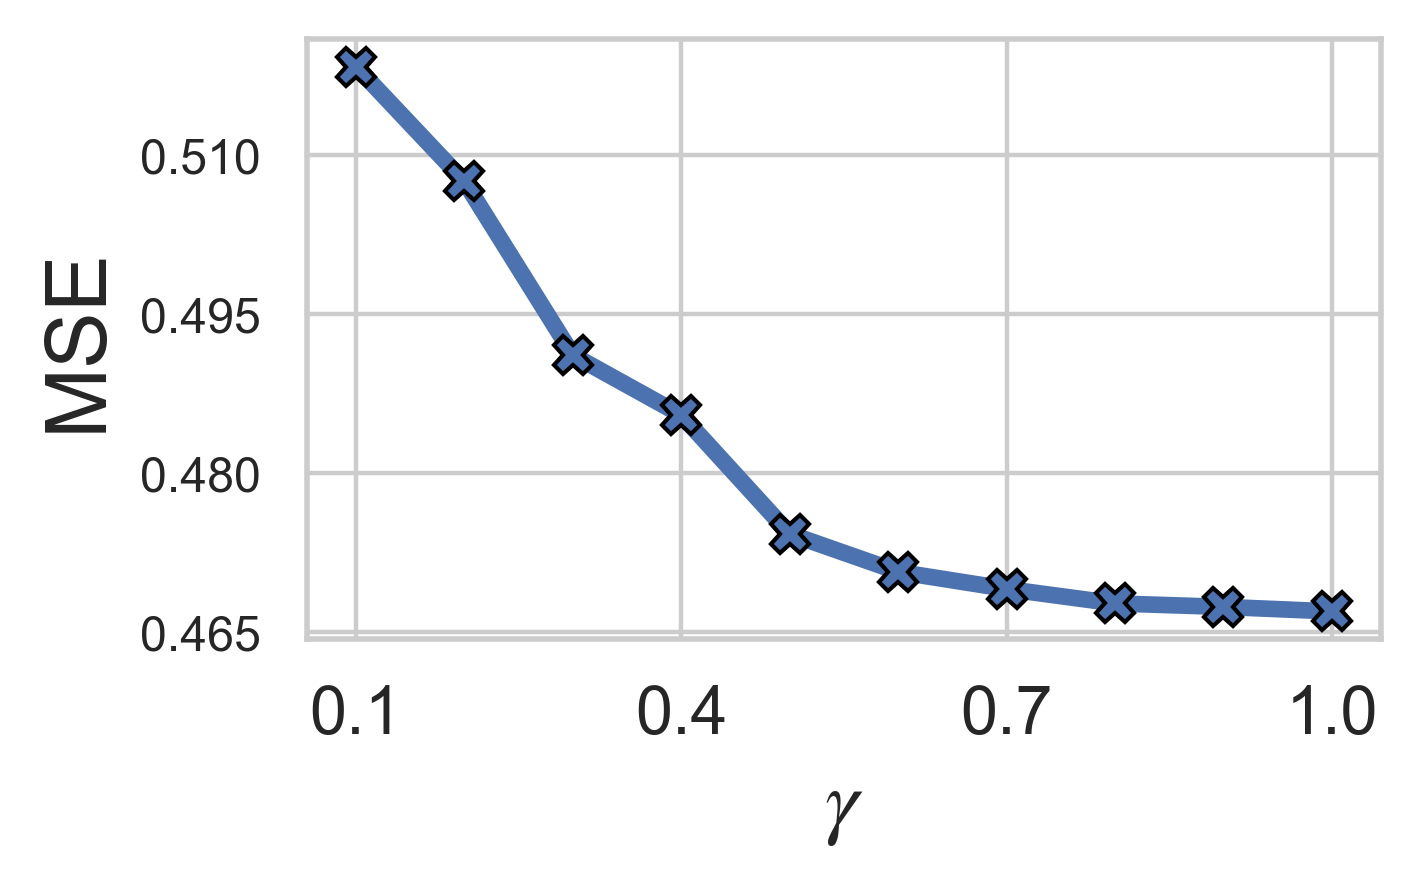

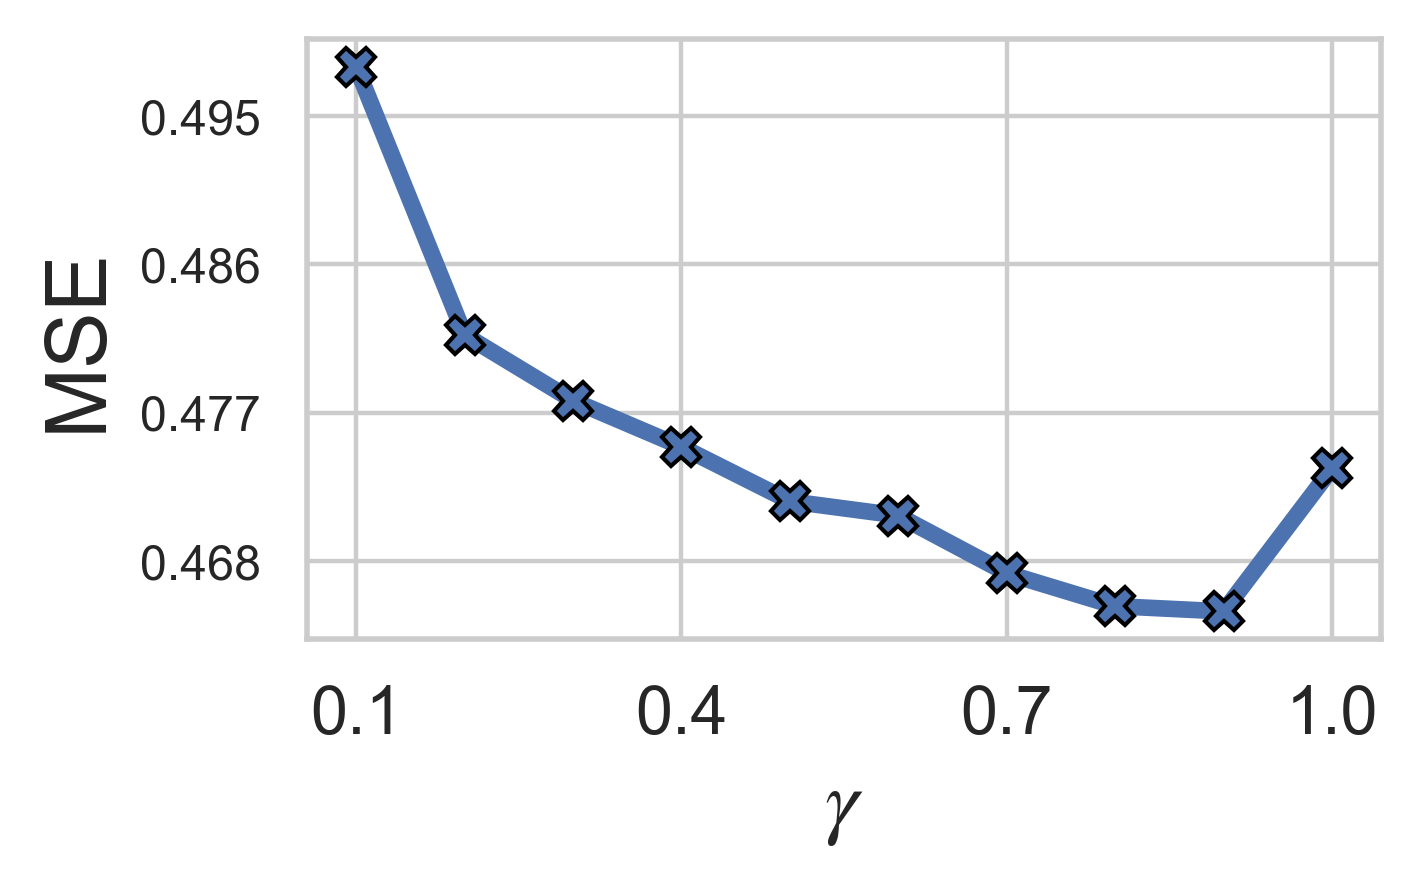

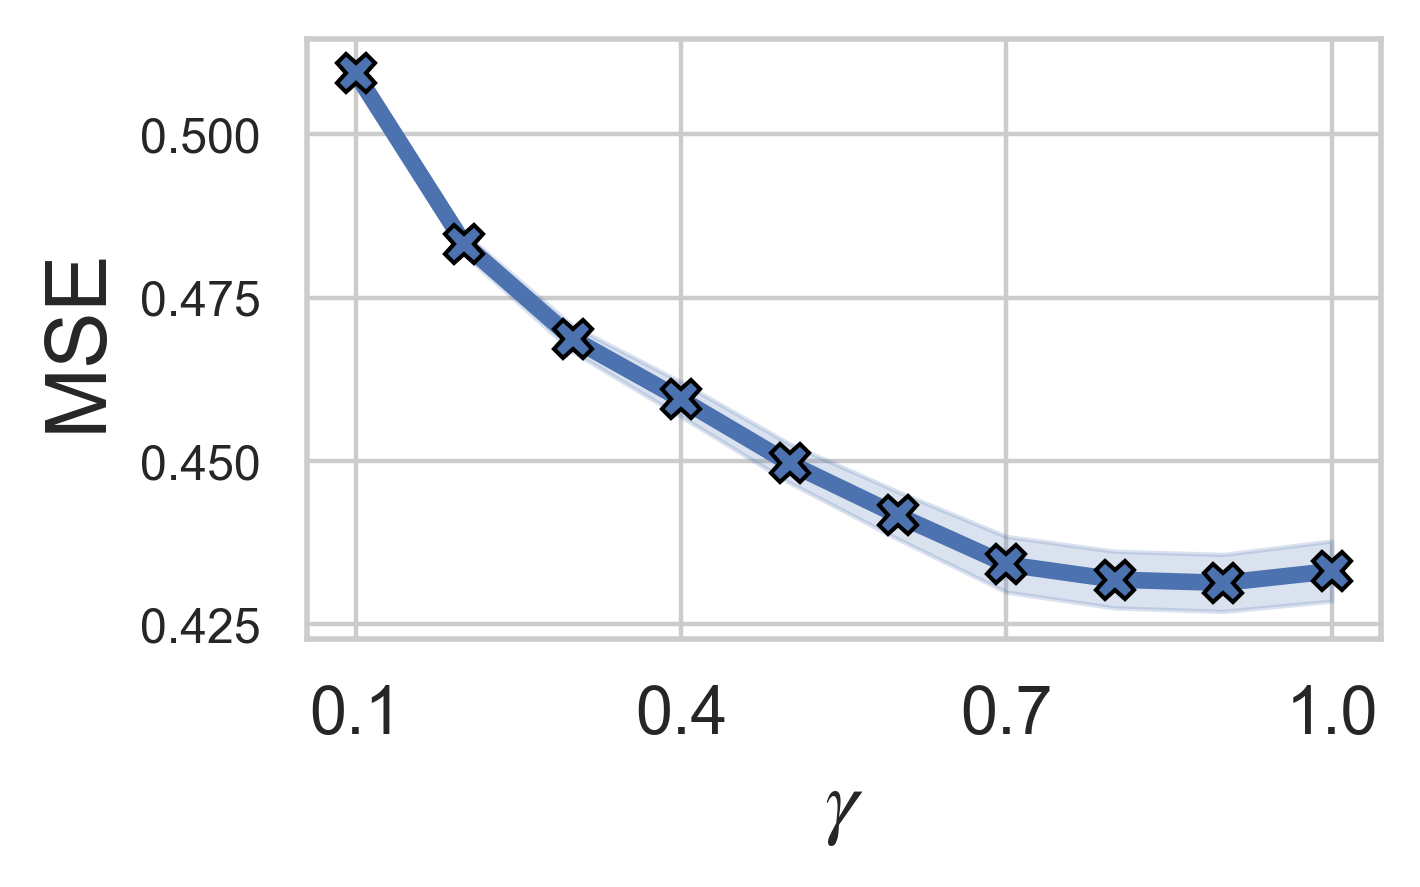

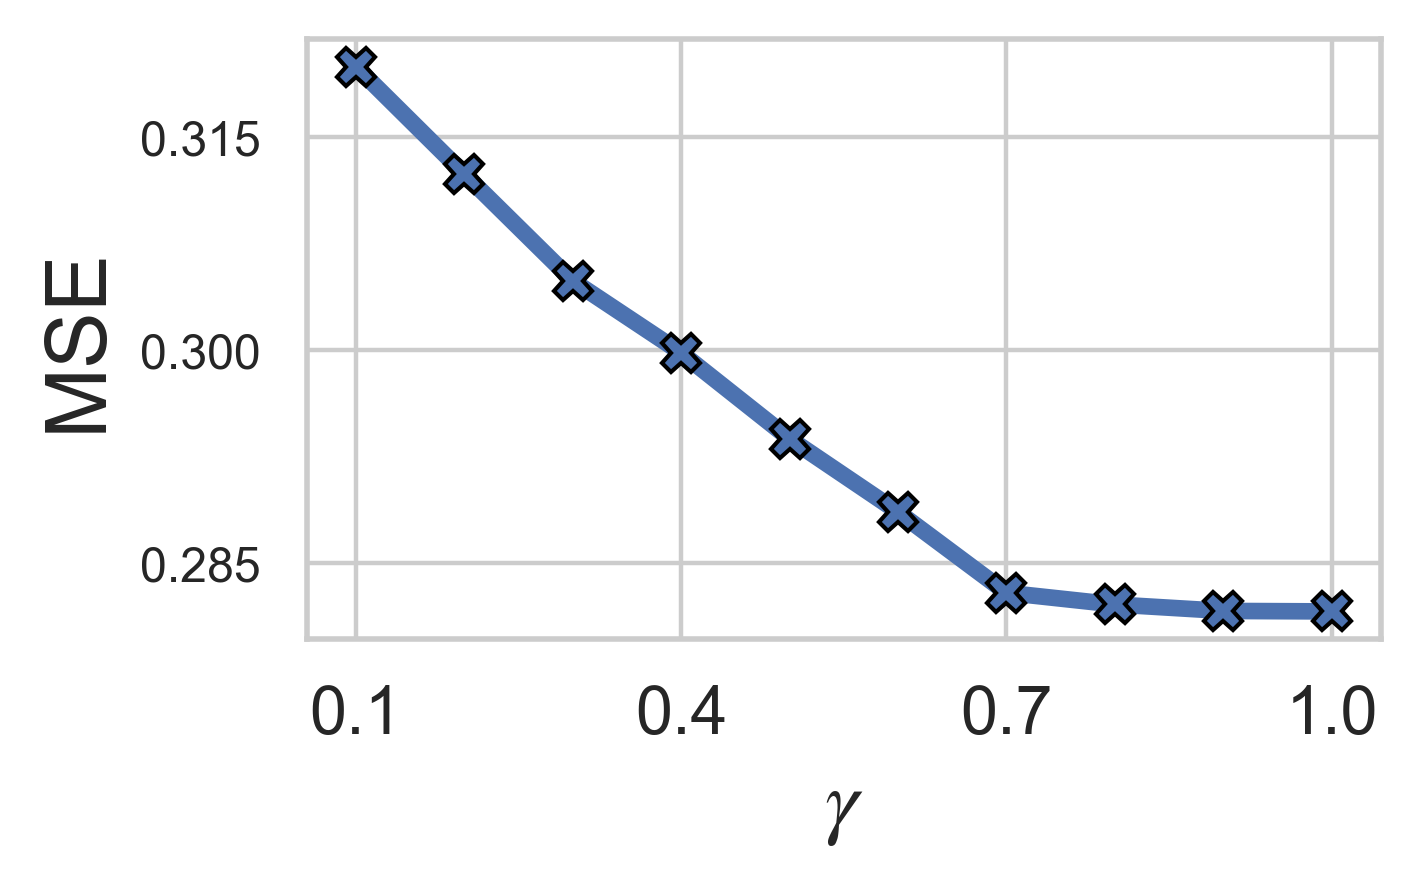

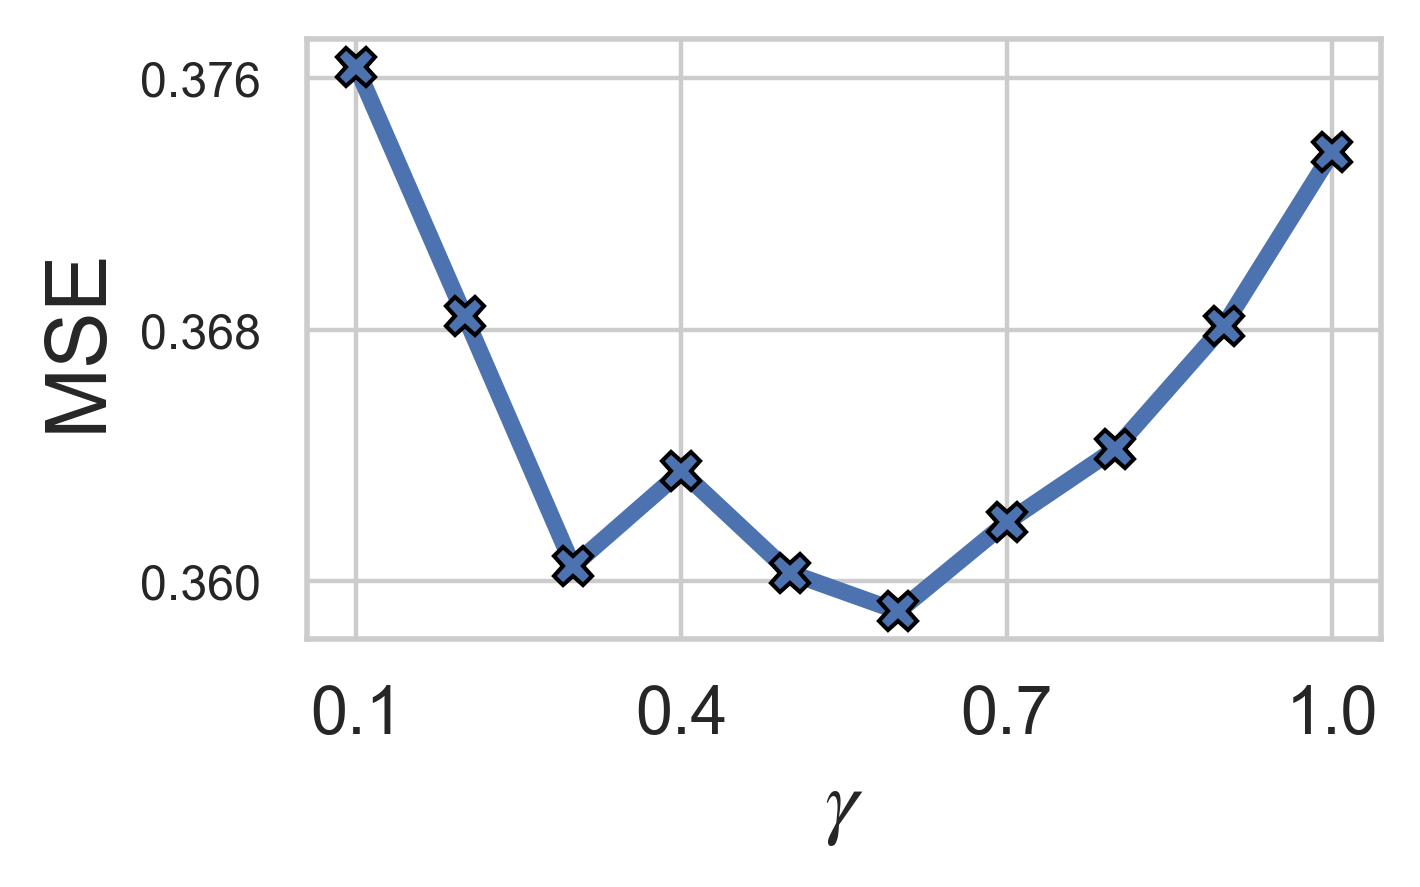

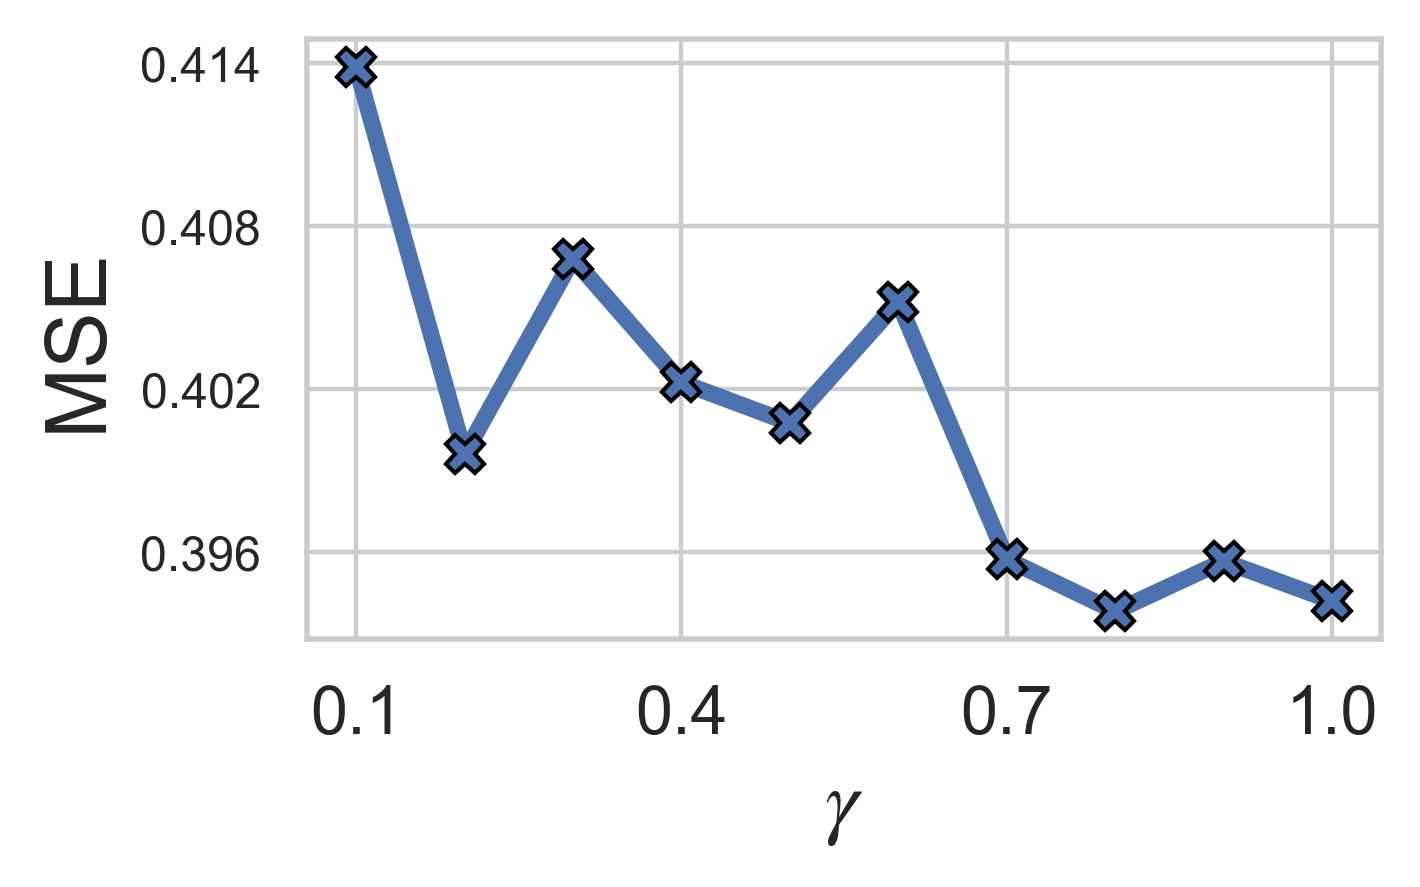

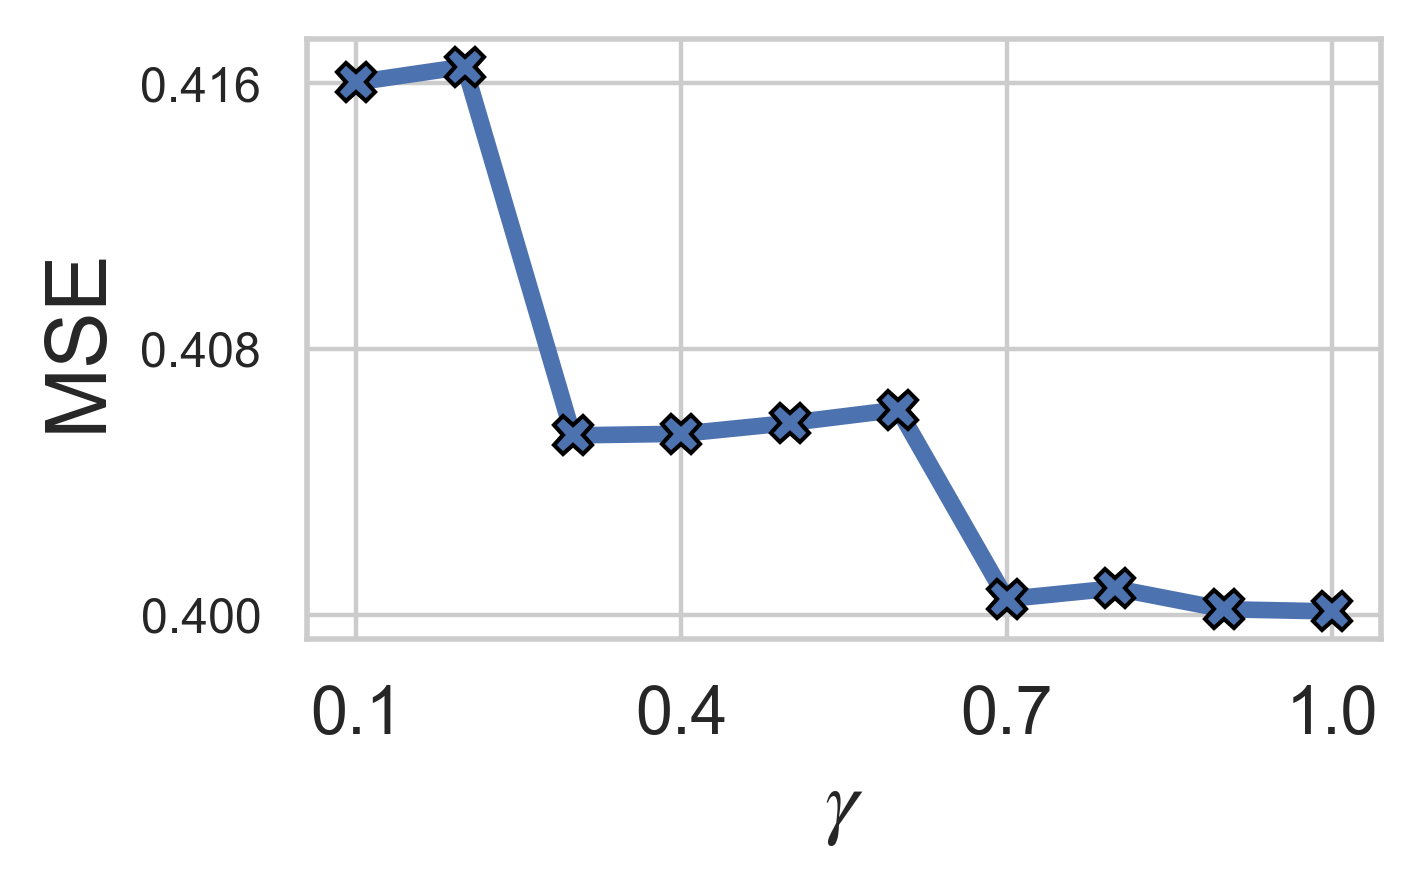

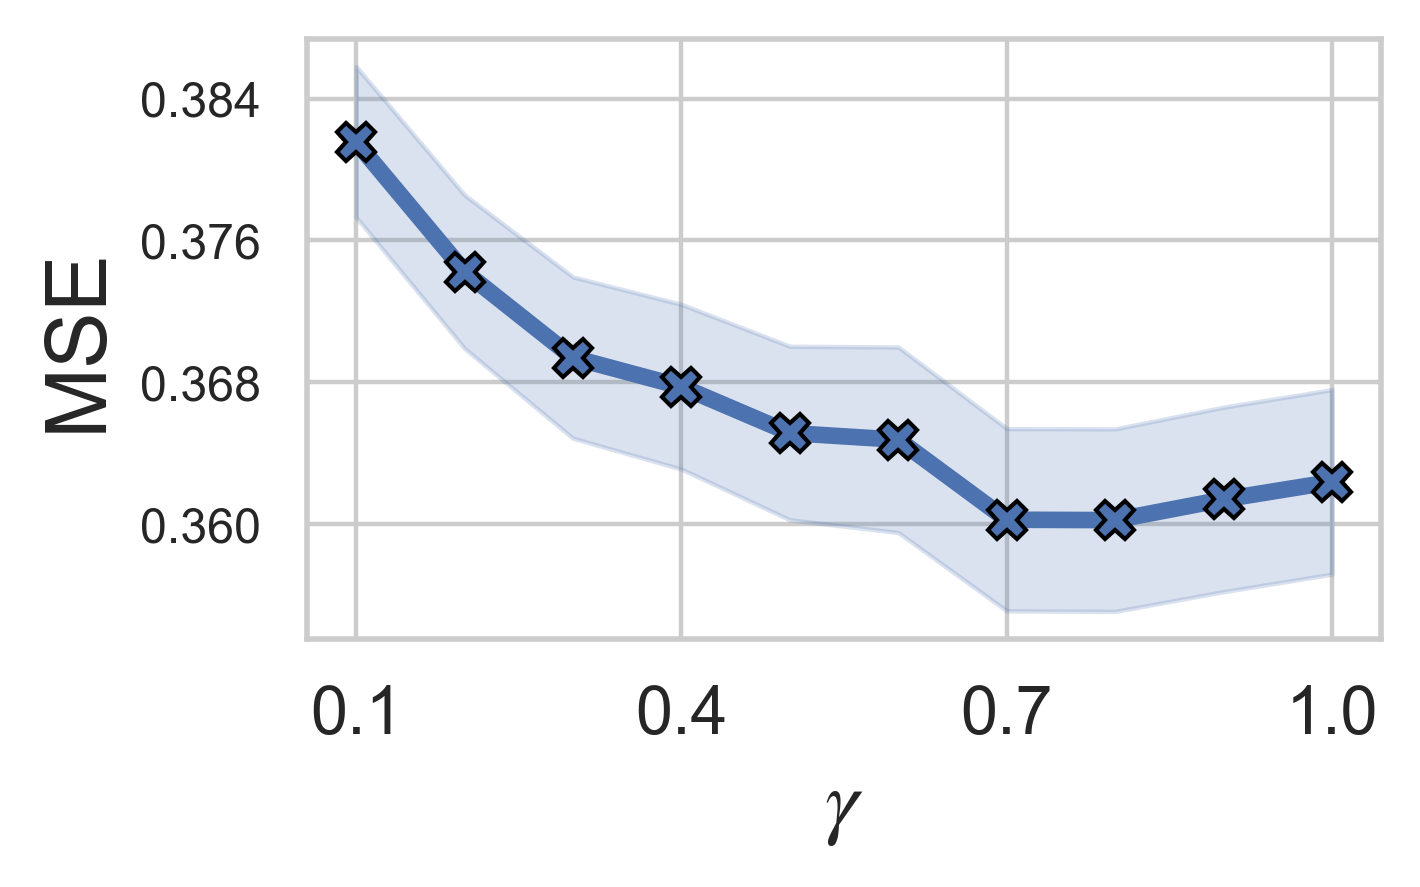

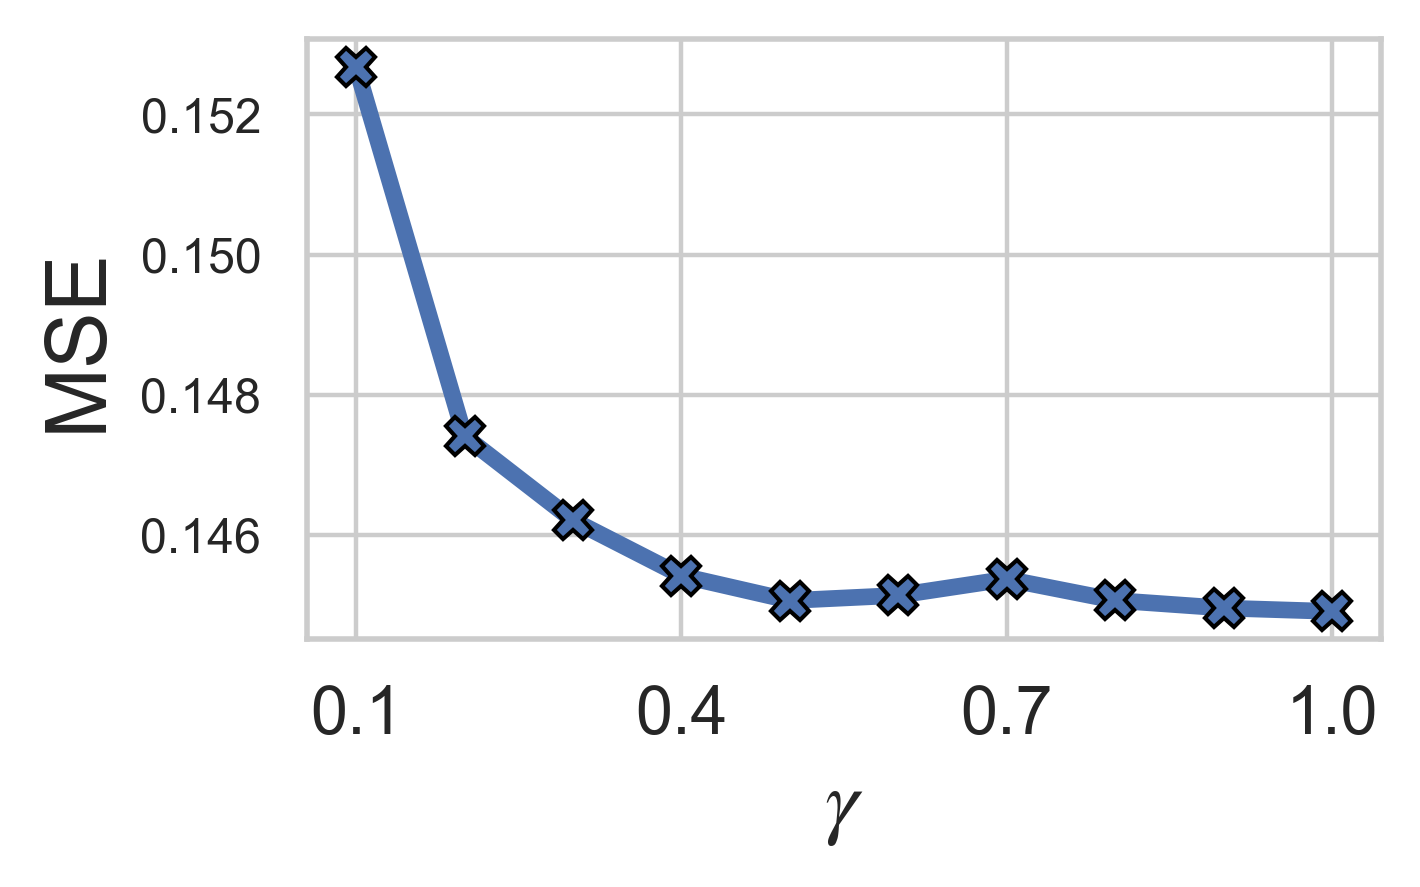

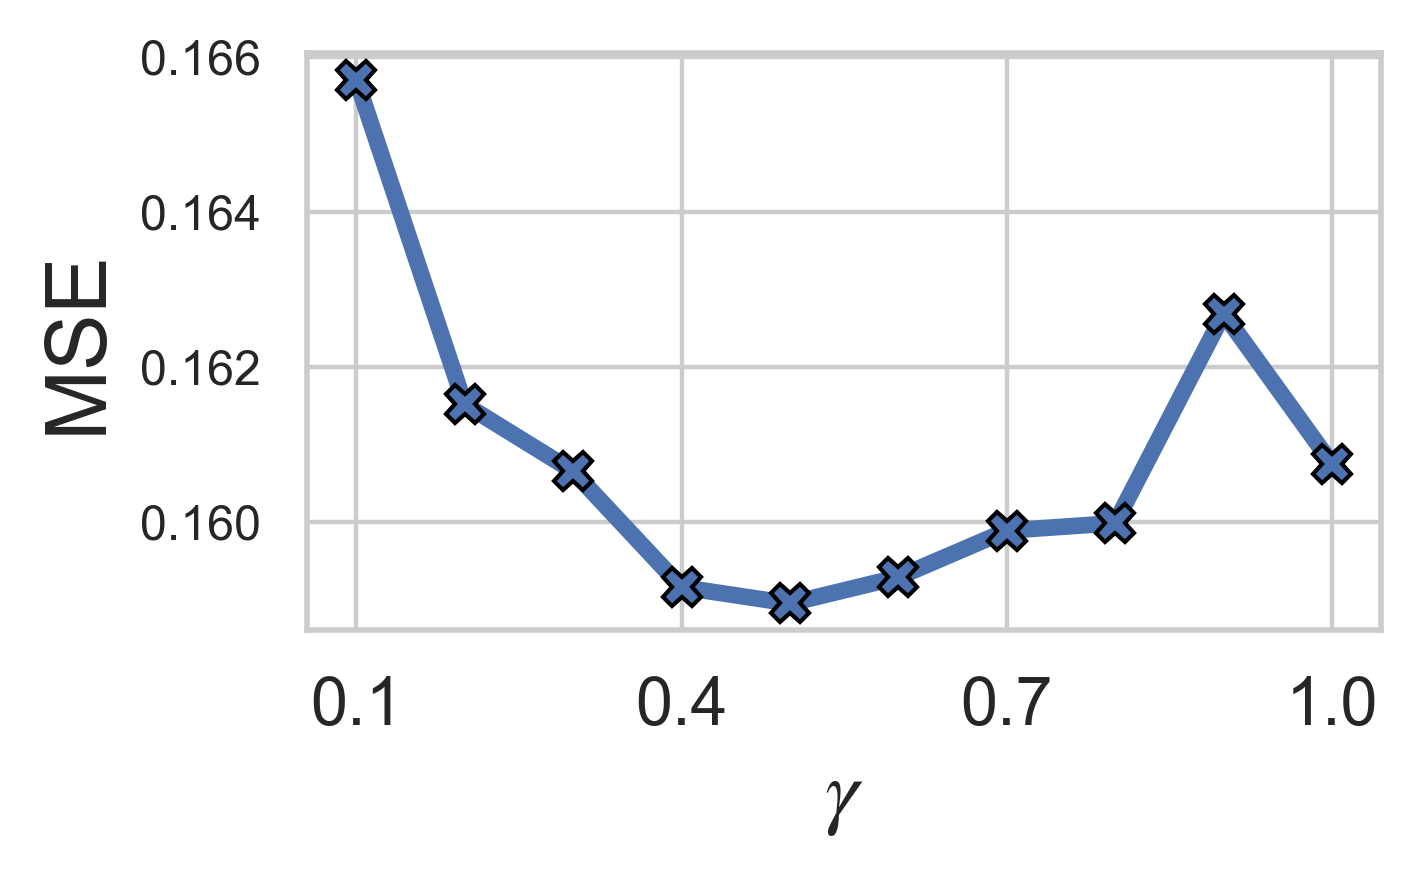

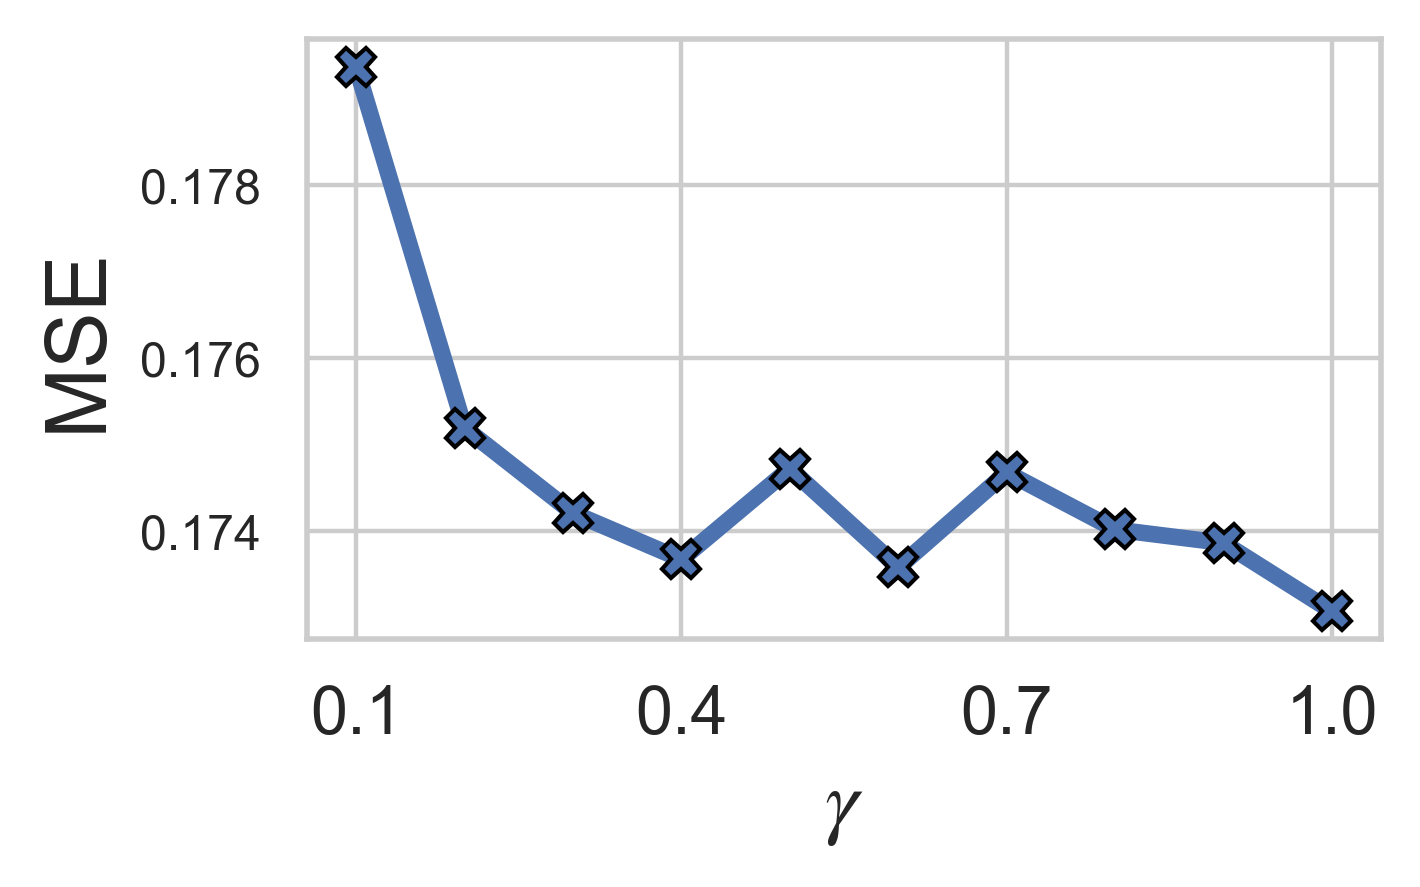

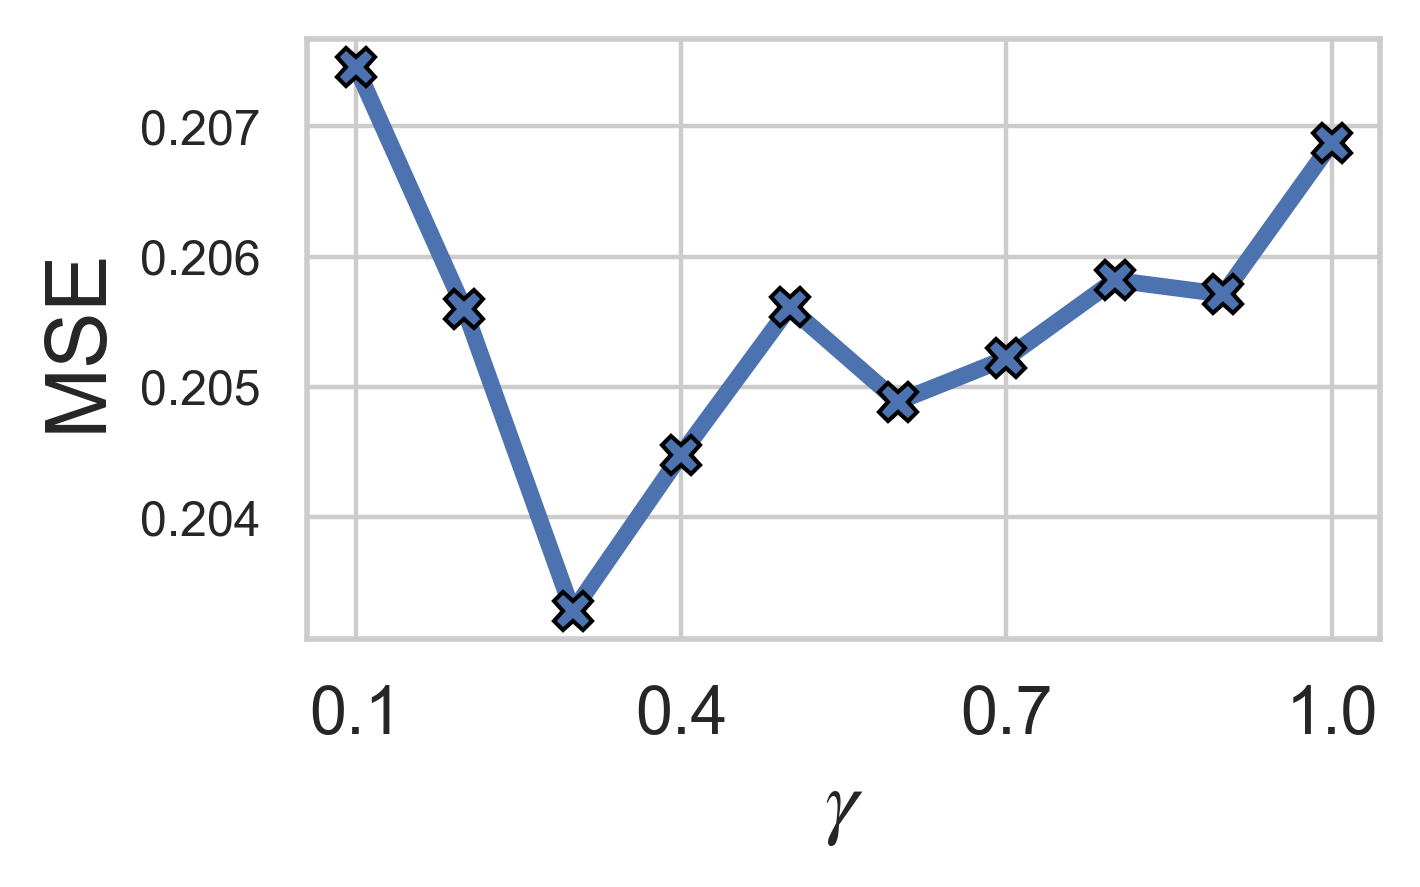

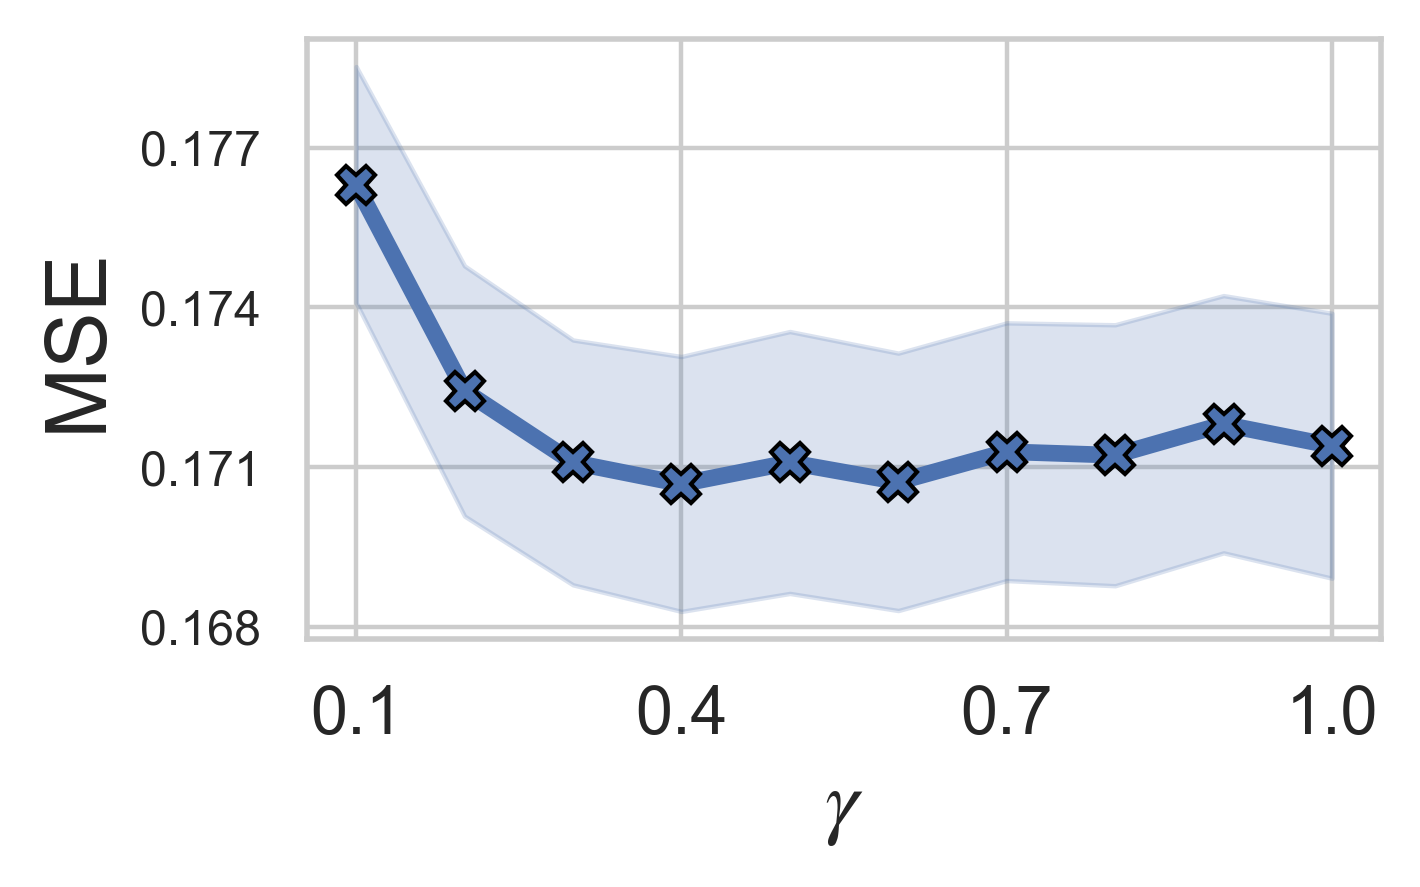

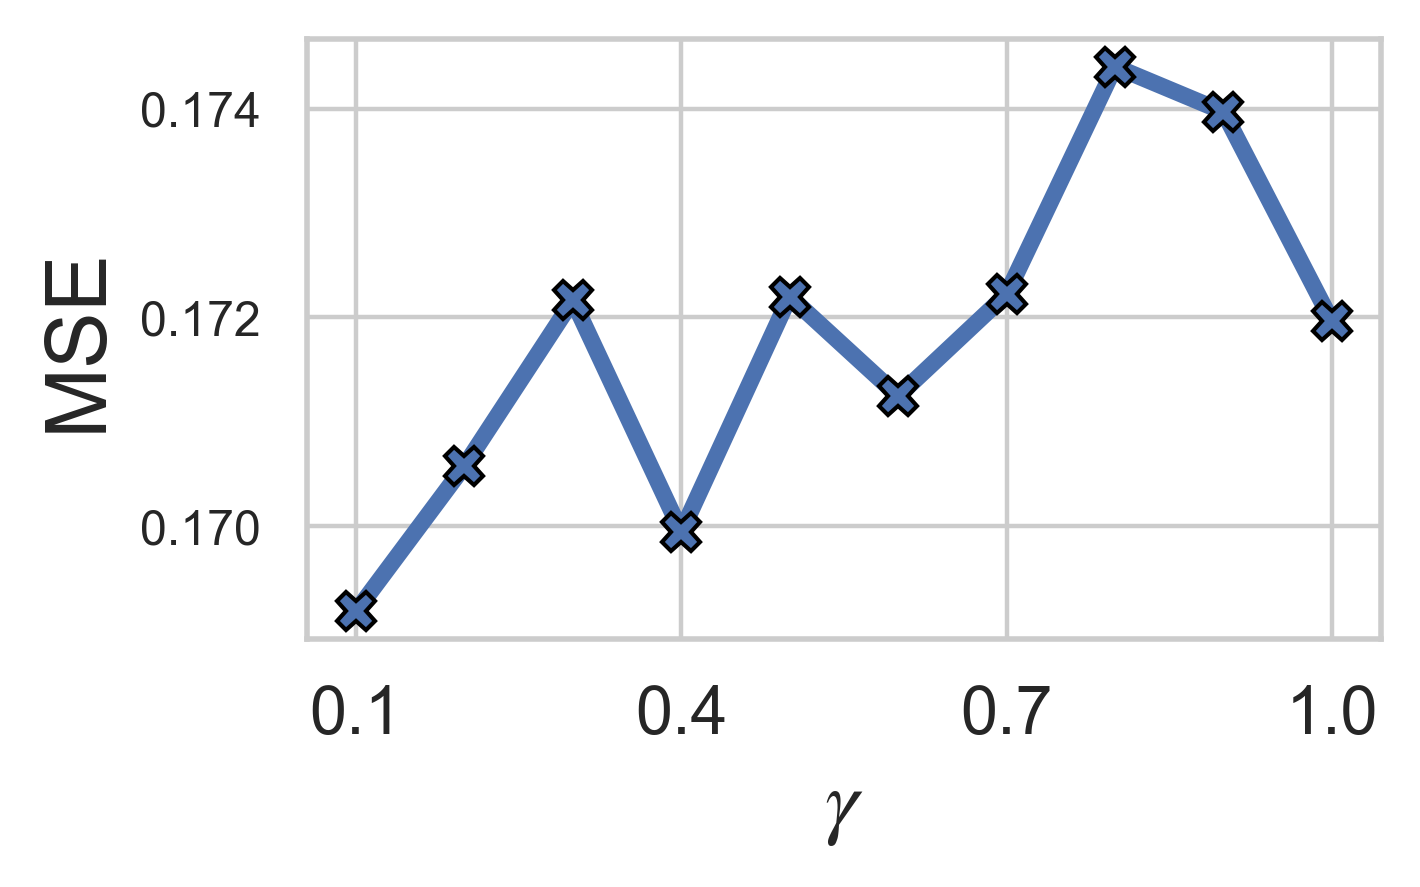

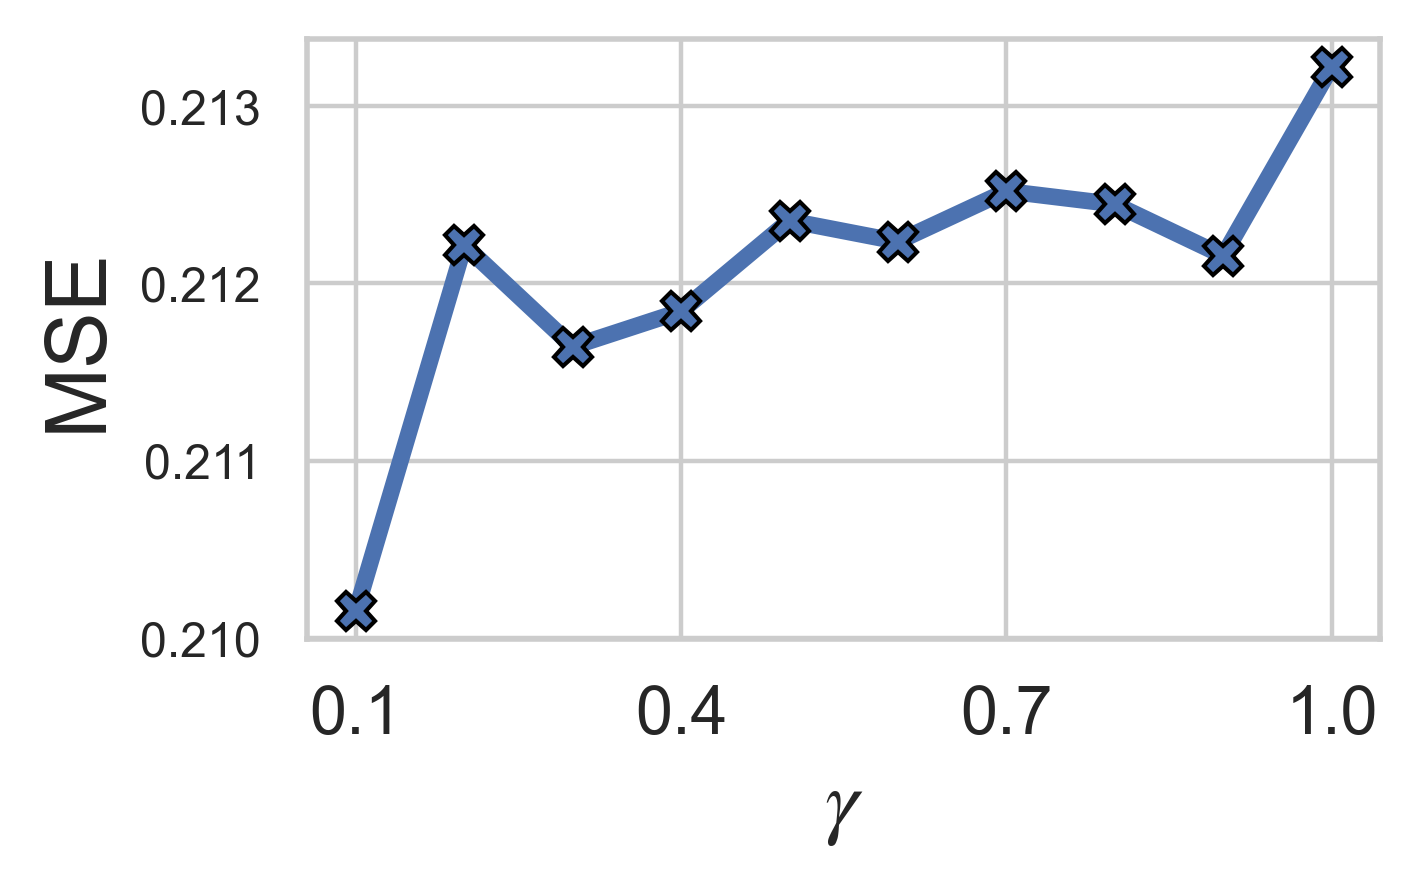

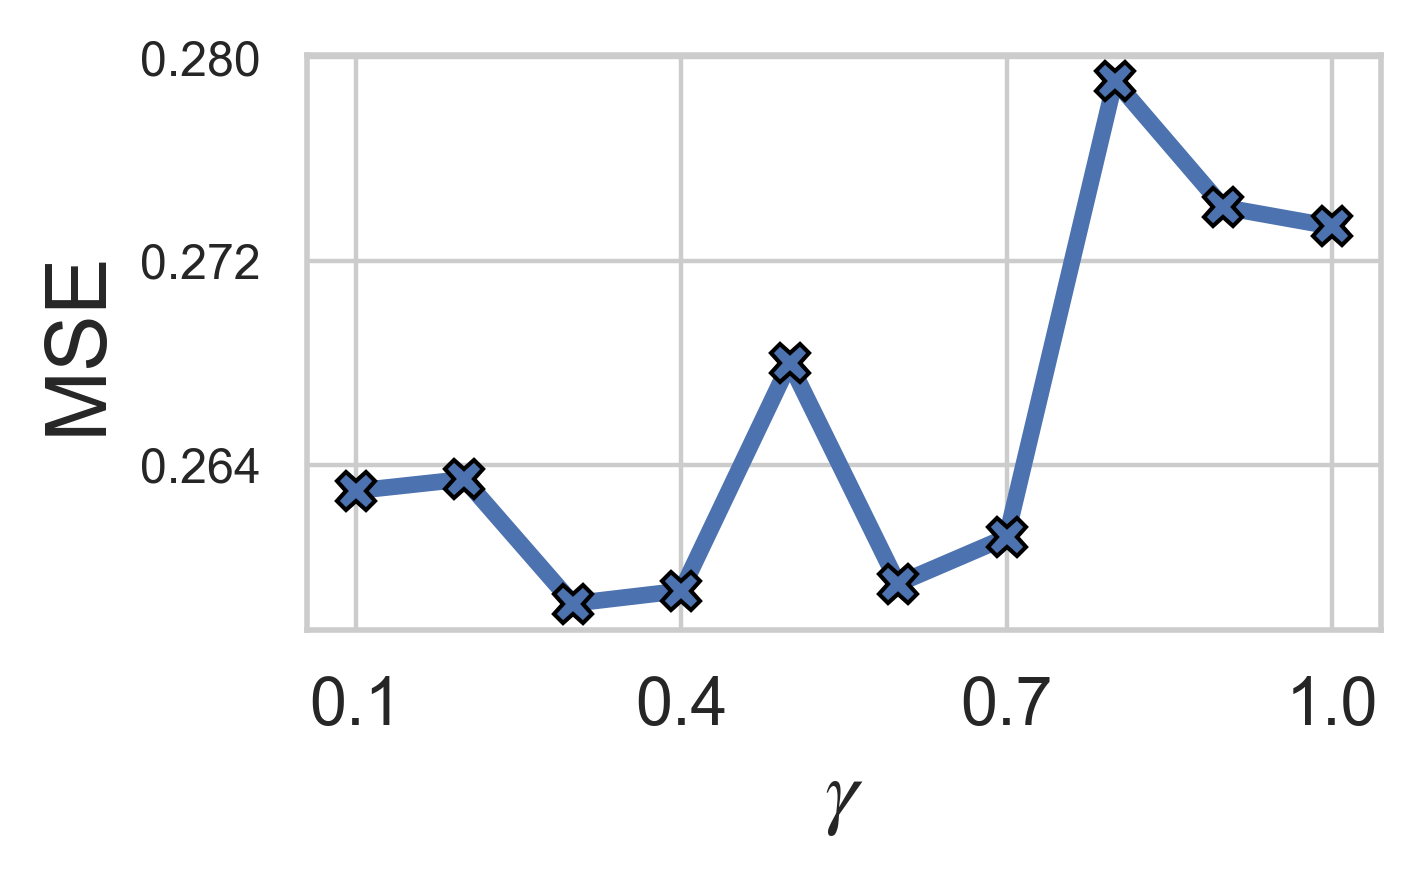

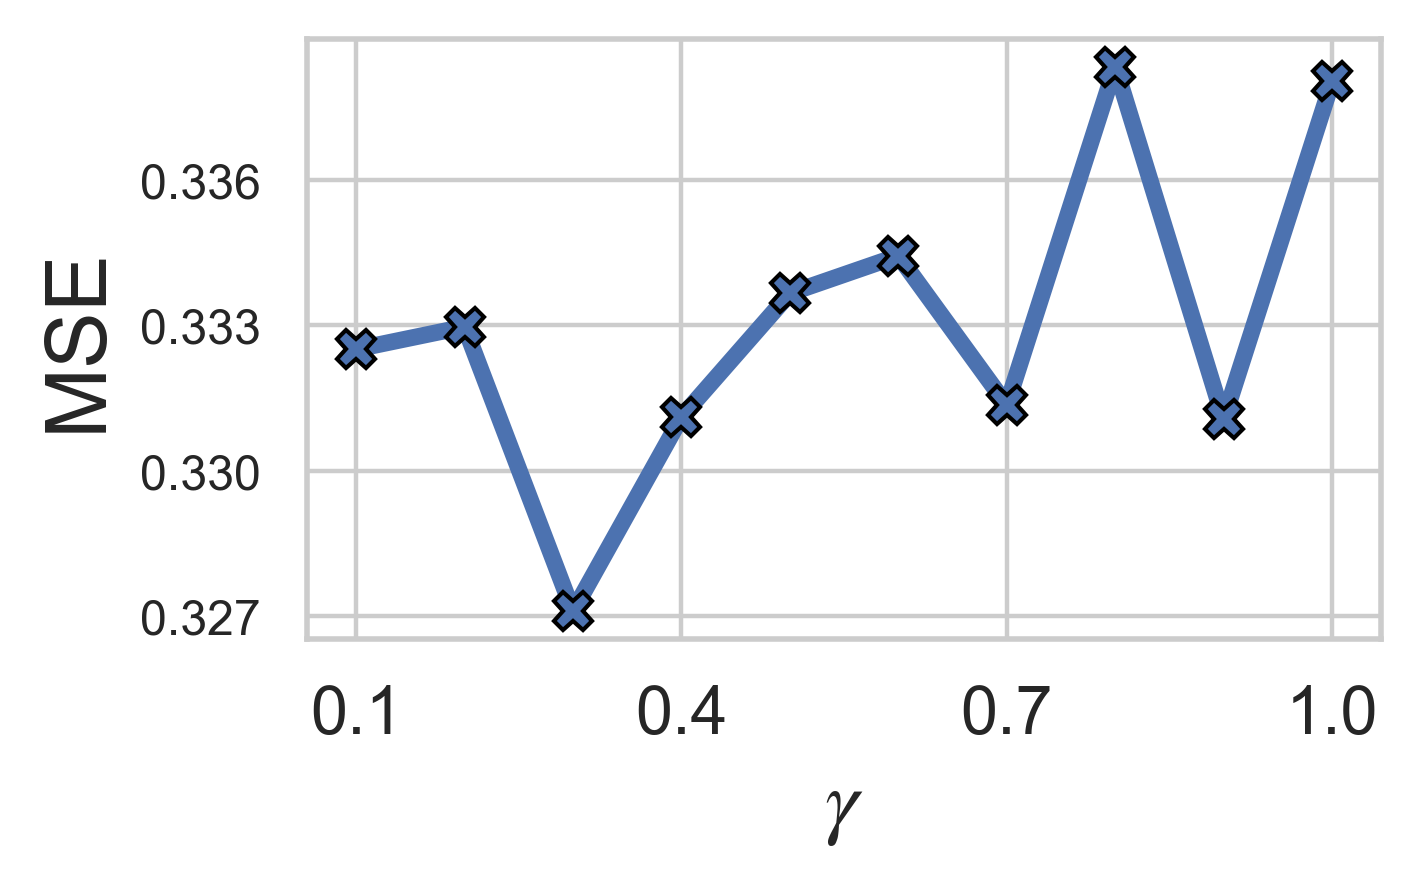

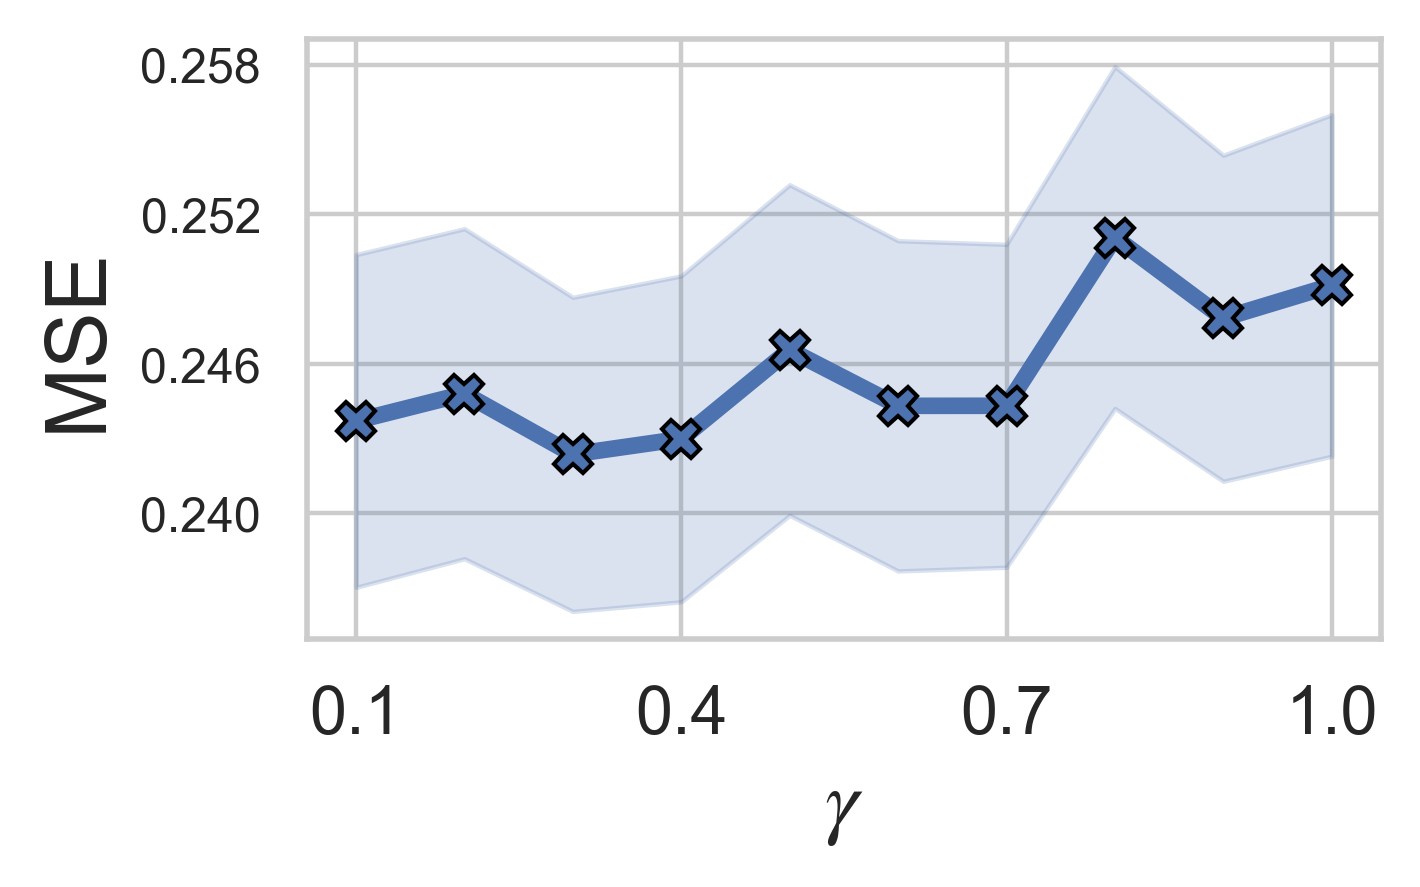

In [431]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper right'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 15
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))
    # errorbar = ('ci', 25)

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    # palette = sns.color_palette('Purples_d')
    # palette = sns.color_palette('Blues_d')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='value', hue='metric', data=df, style='metric', errorbar=errorbar, markers=['X'], linewidth=3, markersize=7, markeredgecolor='k', palette=palette[1:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.3))  # 小数点后3位数间隔。
    leg = plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    leg.remove()
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize, axis='x')
    if len(str(ypad1)) >= 5:
        plt.tick_params(labelsize=8.7, axis='y')
    else:
        plt.tick_params(labelsize=labelsize, axis='y')
    if ytick1:
        plt.yticks(ytick1)
    # plt.xlim([0.0, 1.0])
    plt.xticks([0.1, 0.4, 0.7, 1.0])
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


dfp = df_rank.copy()

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study_all'
os.makedirs(save_dir, exist_ok=True)


data_id = 'ETTm1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.011)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.011)



data_id = 'ETTm2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.009)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.012)




data_id = 'ETTh1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.042)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.022)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.015)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.009)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.025)



data_id = 'ETTh2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.015)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.006)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.008)





data_id = 'ECL'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.003)




data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.006)

In [380]:
dfp = df_rank.copy()
dfp['lambda'] = 1 - dfp['alpha']
dfp = dfp[['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'rank_ratio', 'learning_rate', 'lambda']]
dfp[(dfp.data_id == 'Weather') & (dfp.pred_len == 336)]

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate,lambda
19937,FreTS,Weather,336,0.9,0.262991,0.303337,0.1,0.001,0.1
19422,FreTS,Weather,336,0.9,0.263449,0.307732,0.2,0.001,0.1
19526,FreTS,Weather,336,0.9,0.258569,0.297079,0.3,0.001,0.1
20268,FreTS,Weather,336,0.9,0.259068,0.297840,0.4,0.001,0.1
20259,FreTS,Weather,336,0.9,0.268003,0.309622,0.5,0.001,0.1
19377,FreTS,Weather,336,0.9,0.259344,0.297878,0.6,0.001,0.1
20062,FreTS,Weather,336,0.9,0.261171,0.300976,0.7,0.001,0.1
19952,FreTS,Weather,336,0.9,0.279078,0.330658,0.8,0.001,0.1
19935,FreTS,Weather,336,0.9,0.274120,0.318167,0.9,0.001,0.1


# process table

In [428]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

datasets = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']

hpa = pd.read_csv(f'{save_root}/hyper_study_alpha.csv')
alpha_table = hpa.copy()
alpha_table = alpha_table[
    alpha_table.alpha.isin([0.0, 0.3, 0.5, 0.7, 1.0]) &
    alpha_table.data_id.isin(datasets)
]

alpha_table_avg = alpha_table.groupby(['model', 'data_id', 'alpha']).mean(numeric_only=True).reset_index()
alpha_table_avg['pred_len'] = 'Avg'
alpha_table = pd.concat([alpha_table, alpha_table_avg]).reset_index(drop=True)


to_save_dsts = ['ETTm1', 'ETTh2', 'Weather']
alpha_table = alpha_table[alpha_table.data_id.isin(to_save_dsts)]

dst_order = to_save_dsts
alpha_table['data_id'] = pd.Categorical(alpha_table['data_id'], categories=dst_order, ordered=True)

alpha_table.sort_values(by=['data_id', 'alpha', 'pred_len'], inplace=True)

alpha_table = alpha_table[alpha_table.pred_len == 'Avg']


alpha_table = alpha_table.set_index(['data_id', 'alpha']).unstack('data_id').swaplevel(axis=1)
columns = []
for model in alpha_table.columns.levels[0]:
    columns.append((model, 'mse'))
    columns.append((model, 'mae'))
alpha_table = alpha_table[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
alpha_table.to_csv(f'{save_root}/hyper_study_alpha_table.csv', index=True, float_format='%.4f')

alpha_table

data_id     ETTm1               ETTh2             Weather          
              mse       mae       mse       mae       mse       mae
alpha                                                              
0.0      0.386692  0.397928  0.376599  0.401924  0.248560  0.293011
0.3      0.387066  0.398260  0.374241  0.398156  0.243860  0.285095
0.5      0.386422  0.397636  0.370282  0.396402  0.243197  0.283333
0.7      0.383086  0.395911  0.367393  0.394302  0.243264  0.284928
1.0      0.384966  0.393322  0.360638  0.388992  0.275284  0.320915

In [427]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

datasets = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']

hpa = pd.read_csv(f'{save_root}/hyper_study_rank.csv')
rank_table = hpa.copy()
rank_table = rank_table[
    rank_table.rank_ratio.isin([0.1, 0.3, 0.5, 0.7, 1.0]) &
    rank_table.data_id.isin(datasets)
]

rank_table_avg = rank_table.groupby(['model', 'data_id', 'rank_ratio']).mean(numeric_only=True).reset_index()
rank_table_avg['pred_len'] = 'Avg'
rank_table = pd.concat([rank_table, rank_table_avg]).reset_index(drop=True)

to_save_dsts = ['ETTm1', 'ETTh2', 'Weather']
rank_table = rank_table[rank_table.data_id.isin(to_save_dsts)]

dst_order = to_save_dsts
rank_table['data_id'] = pd.Categorical(rank_table['data_id'], categories=dst_order, ordered=True)

rank_table.sort_values(by=['data_id', 'rank_ratio', 'pred_len'], inplace=True)

rank_table = rank_table[rank_table.pred_len == 'Avg']


rank_table = rank_table.set_index(['data_id', 'rank_ratio']).unstack('data_id').swaplevel(axis=1)
columns = []
for model in rank_table.columns.levels[0]:
    columns.append((model, 'mse'))
    columns.append((model, 'mae'))
rank_table = rank_table[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
rank_table.to_csv(f'{save_root}/hyper_study_rank_table.csv', index=True, float_format='%.4f')

rank_table

data_id        ETTm1               ETTh2             Weather          
                 mse       mae       mse       mae       mse       mae
rank_ratio                                                            
0.1         0.391526  0.400153  0.381560  0.402866  0.243708  0.284521
0.3         0.384882  0.396441  0.369395  0.396102  0.242369  0.282466
0.5         0.381708  0.394328  0.365142  0.392314  0.246555  0.287738
0.7         0.379754  0.392973  0.360253  0.388648  0.244317  0.286106
1.0         0.381421  0.393953  0.362387  0.390299  0.249144  0.292448